# Análisis de Ventas - La Campeona Empanadas

**Negocio:** La Campeona Empanadas - Montevideo, Uruguay  
**Período:** Enero 2024 - Febrero 2026  
**Autor:** Catalina Vaz Martins
**Fecha:** Marzo 2026  

Análisis integral de los datos de ventas de dos sucursales (Cordón y Punta Carretas).
Incluye limpieza de datos, análisis exploratorio, mapa de delivery y modelos predictivos
de demanda por sabor.

**Fuente de datos:**  
- Sistema POS del local exportado desde SQL Server

In [109]:
!pip install unidecode geopy folium lightgbm holidays -q

In [110]:
# ── Datos y manipulación ───────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Fechas y calendario ────────────────────────────────────────────────────
from datetime import datetime, timedelta
import holidays

# ── Geo / Mapas ────────────────────────────────────────────────────────────
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import unidecode
import re

# ── Machine Learning ───────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

# ── Configuración general ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga de Datos

Se cargan los archivos exportados desde el sistema POS para cada sucursal
y se unifican en un único dataset.

In [112]:
RUTA = '/content/drive/MyDrive/Campeona/Datos/'

# Archivos históricos (hasta nov-2025 inclusive)
ventas_cor = pd.read_csv(RUTA + 'VentasCORvf.csv', sep=';', low_memory=False)
ventas_pc  = pd.read_csv(RUTA + 'VentasPCvf.csv',  sep=';', low_memory=False)

# Archivos incrementales (dic-2025 a feb-2026)
ventas_cor_inc = pd.read_csv(RUTA + 'VentasCOR_inc.csv', sep=';', low_memory=False)
ventas_pc_inc  = pd.read_csv(RUTA + 'VentasPC_inc.csv',  sep=';', low_memory=False)

# Unificación
ventas = pd.concat([ventas_cor, ventas_pc, ventas_cor_inc, ventas_pc_inc], ignore_index=True)

print(f"COR histórico:       {len(ventas_cor):,} filas")
print(f"PC histórico:        {len(ventas_pc):,} filas")
print(f"COR incremental:     {len(ventas_cor_inc):,} filas")
print(f"PC incremental:      {len(ventas_pc_inc):,} filas")
print(f"Total unificado:     {len(ventas):,} filas")
print(f"Columnas:            {ventas.shape[1]}")

COR histórico:       238,925 filas
PC histórico:        387,723 filas
COR incremental:     37,958 filas
PC incremental:      60,362 filas
Total unificado:     724,968 filas
Columnas:            64


## 2. Revisión Inicial

In [113]:
# Vista general
print(f"Período: {ventas['fecha'].min()} → {ventas['fecha'].max()}")
print(f"Sucursales: {ventas['sucursal'].unique()}")
print(f"\nPrimeras filas:")
display(ventas.head())

Período: 2024-01-08 13:25:08.000 → 2026-02-28 22:48:58.000
Sucursales: ['COR' 'PC']

Primeras filas:


,sucursal,seriefolio,folio,descuento,orden,idturno,turno_apertura,turno_cierre,efectivo,tarjeta,foliodet,precio,cantidad,idproducto,descripcion,descuento.1,preciocatalogo,iva,idproductocompuesto,productocompuestoprincipal,modificador,salidarepartidor,arriborepartidor,numcheque,cierre,fecha,idcliente,observaciones,totalarticulos,subtotal,total,totalconpropina,totalimpuesto1,cargo,totalconcargo,totalconpropina.1,totalconpropinacargo,descuentoimporte,efectivo.1,tarjeta.1,totalsindescuento,totalalimentos,totalbebidas,totalotros,totaldescuentos,totaldescuentoalimentos,totaldescuentobebidas,totaldescuentootros,totalalimentossindescuentos,totalbebidassindescuentos,subtotalcondescuento,comisionpax,totalimpuestod1,desc_imp_original,cliente_nombre,cliente_direccion,cliente_contacto,cliente_tel,cliente_alta,calcpreciomenosdescuento,cierremes,cierresemana,cierredia,cierreyear
0,COR,NaN,7,0.0,8,2,2024-01-08 18:28:55.000,2024-01-08 23:16:54.000,"14071,00","23087,00",7,"0,00",1.0,8417,TUCUMANA,0.0,"0,00",22.0,_6SW152LM0,0,1,2024-01-08 19:13:18.000,2024-01-08 19:15:32.000,7,2024-01-08 19:13:36.000,2024-01-08 19:09:39.000,000003,MERCADO PAGO,1.0,"688,5246","840,00","840,00","151,4754","0,00","840,00","840,00","840,00","0,00","0,00","840,00","688,5246","688,5246","0,00","0,00","0,00","0,00","0,00","0,00","688,5246","0,00","688,5246",NaN,"151,4754","0,00",CARLA,NaN,CARLA,096304451,NaN,0.0,1,2,8,2024
1,COR,NaN,7,0.0,8,2,2024-01-08 18:28:55.000,2024-01-08 23:16:54.000,"14071,00","23087,00",7,"0,00",1.0,8417,TUCUMANA,0.0,"0,00",22.0,_6SW152LM0,0,1,2024-01-08 19:13:18.000,2024-01-08 19:15:32.000,7,2024-01-08 19:13:36.000,2024-01-08 19:09:39.000,000003,MERCADO PAGO,1.0,"688,5246","840,00","840,00","151,4754","0,00","840,00","840,00","840,00","0,00","0,00","840,00","688,5246","688,5246","0,00","0,00","0,00","0,00","0,00","0,00","688,5246","0,00","688,5246",NaN,"151,4754","0,00",CARLA,NaN,CARLA,096304451,NaN,0.0,1,2,8,2024
2,COR,NaN,7,0.0,8,2,2024-01-08 18:28:55.000,2024-01-08 23:16:54.000,"14071,00","23087,00",7,"0,00",1.0,8405,ARABE,0.0,"0,00",22.0,_6SW152LM0,0,1,2024-01-08 19:13:18.000,2024-01-08 19:15:32.000,7,2024-01-08 19:13:36.000,2024-01-08 19:09:39.000,000003,MERCADO PAGO,1.0,"688,5246","840,00","840,00","151,4754","0,00","840,00","840,00","840,00","0,00","0,00","840,00","688,5246","688,5246","0,00","0,00","0,00","0,00","0,00","0,00","688,5246","0,00","688,5246",NaN,"151,4754","0,00",CARLA,NaN,CARLA,096304451,NaN,0.0,1,2,8,2024
3,COR,NaN,7,0.0,8,2,2024-01-08 18:28:55.000,2024-01-08 23:16:54.000,"14071,00","23087,00",7,"0,00",1.0,8408,"ESPINACA, RICOTA Y PARMESANO",0.0,"0,00",22.0,_6SW152LM0,0,1,2024-01-08 19:13:18.000,2024-01-08 19:15:32.000,7,2024-01-08 19:13:36.000,2024-01-08 19:09:39.000,000003,MERCADO PAGO,1.0,"688,5246","840,00","840,00","151,4754","0,00","840,00","840,00","840,00","0,00","0,00","840,00","688,5246","688,5246","0,00","0,00","0,00","0,00","0,00","0,00","688,5246","0,00","688,5246",NaN,"151,4754","0,00",CARLA,NaN,CARLA,096304451,NaN,0.0,1,2,8,2024
4,COR,NaN,7,0.0,8,2,2024-01-08 18:28:55.000,2024-01-08 23:16:54.000,"14071,00","23087,00",7,"0,00",1.0,8414,QUESO Y ACEITUNAS MARINADAS,0.0,"0,00",22.0,_6SW152LM0,0,1,2024-01-08 19:13:18.000,2024-01-08 19:15:32.000,7,2024-01-08 19:13:36.000,2024-01-08 19:09:39.000,000003,MERCADO PAGO,1.0,"688,5246","840,00","840,00","151,4754","0,00","840,00","840,00","840,00","0,00","0,00","840,00","688,5246","688,5246","0,00","0,00","0,00","0,00","0,00","0,00","688,5246","0,00","688,5246",NaN,"151,4754","0,00",CARLA,NaN,CARLA,096304451,NaN,0.0,1,2,8,2024


In [114]:
print(f"\nUltimas filas:")
display(ventas.tail())


Ultimas filas:


,sucursal,seriefolio,folio,descuento,orden,idturno,turno_apertura,turno_cierre,efectivo,tarjeta,foliodet,precio,cantidad,idproducto,descripcion,descuento.1,preciocatalogo,iva,idproductocompuesto,productocompuestoprincipal,modificador,salidarepartidor,arriborepartidor,numcheque,cierre,fecha,idcliente,observaciones,totalarticulos,subtotal,total,totalconpropina,totalimpuesto1,cargo,totalconcargo,totalconpropina.1,totalconpropinacargo,descuentoimporte,efectivo.1,tarjeta.1,totalsindescuento,totalalimentos,totalbebidas,totalotros,totaldescuentos,totaldescuentoalimentos,totaldescuentobebidas,totaldescuentootros,totalalimentossindescuentos,totalbebidassindescuentos,subtotalcondescuento,comisionpax,totalimpuestod1,desc_imp_original,cliente_nombre,cliente_direccion,cliente_contacto,cliente_tel,cliente_alta,calcpreciomenosdescuento,cierremes,cierresemana,cierredia,cierreyear
724963,PC,PY,69667,14.9992,36,1561,2026-02-26 17:49:02.000,2026-02-26 23:05:35.000,"33414,00","62134,50",69667,"0,00",2.0,8410,HUMITA,0.0,"0,00",22.0,PY36_1,1,0,2026-02-26 21:07:01.000,2026-02-26 21:07:11.000,25734,2026-02-26 21:07:02.000,2026-02-26 21:03:18.000,999380Josefina,Medio de pago: VISA - Forma de pago: -VISA-. -...,5.0,"442,623","459,00","459,00","82,7713","0,00","459,00","459,00","459,00","66,39","0,00","459,00","442,623","94,0583","0,00","282,1748","66,39","16,5975","0,00","49,7925","110,6557","0,00","376,233",NaN,"82,7713","0,00",Josefina Moizo,NaN,Josefina Moizo,+59899993453,1900-01-01 00:00:00.000,0.00000,2,8,26,2026
724964,PC,PY,69667,14.9992,36,1561,2026-02-26 17:49:02.000,2026-02-26 23:05:35.000,"33414,00","62134,50",69667,"0,00",1.0,8408,"ESPINACA, RICOTA Y PARMESANO",0.0,"0,00",22.0,PY36_1,1,0,2026-02-26 21:07:01.000,2026-02-26 21:07:11.000,25734,2026-02-26 21:07:02.000,2026-02-26 21:03:18.000,999380Josefina,Medio de pago: VISA - Forma de pago: -VISA-. -...,5.0,"442,623","459,00","459,00","82,7713","0,00","459,00","459,00","459,00","66,39","0,00","459,00","442,623","94,0583","0,00","282,1748","66,39","16,5975","0,00","49,7925","110,6557","0,00","376,233",NaN,"82,7713","0,00",Josefina Moizo,NaN,Josefina Moizo,+59899993453,1900-01-01 00:00:00.000,0.00000,2,8,26,2026
724965,PC,PY,69667,14.9992,36,1561,2026-02-26 17:49:02.000,2026-02-26 23:05:35.000,"33414,00","62134,50",69667,"135,00",1.0,8414,QUESO Y ACEITUNAS MARINADAS,0.0,"130,00",22.0,PY36_4,1,0,2026-02-26 21:07:01.000,2026-02-26 21:07:11.000,25734,2026-02-26 21:07:02.000,2026-02-26 21:03:18.000,999380Josefina,Medio de pago: VISA - Forma de pago: -VISA-. -...,5.0,"442,623","459,00","459,00","82,7713","0,00","459,00","459,00","459,00","66,39","0,00","459,00","442,623","94,0583","0,00","282,1748","66,39","16,5975","0,00","49,7925","110,6557","0,00","376,233",NaN,"82,7713","0,00",Josefina Moizo,NaN,Josefina Moizo,+59899993453,1900-01-01 00:00:00.000,114.75108,2,8,26,2026
724966,PC,PY,63766,0.0000,4,1444,2025-12-28 18:13:43.000,2025-12-28 23:09:58.000,"27405,00","47049,98",63766,"135,00",1.0,8414,QUESO Y ACEITUNAS MARINADAS,0.0,"130,00",22.0,PY4_1,1,0,2025-12-28 20:08:59.000,NaN,22776,2025-12-28 20:09:01.000,2025-12-28 20:08:55.000,99975793Laura,Medio de pago: VISA - Forma de pago: -VISA-. -...,2.0,"221,3115","270,00","270,00","48,6885","0,00","270,00","270,00","270,00","0,00","0,00","270,00","221,3115","221,3115","0,00","0,00","0,00","0,00","0,00","0,00","221,3115","0,00","221,3115",NaN,"48,6885","0,00",Laura Trigo,NaN,Laura Trigo,+59899222898,1900-01-01 00:00:00.000,135.00000,12,53,28,2025
724967,PC,PY,63766,0.0000,4,1444,2025-12-28 18:13:43.000,2025-12-28 23:09:58.000,"27405,00","47049,98",63766,"135,00",1.0,8415,QUESO Y VERDEO,0.0,"130,00",22.0,PY4_2,1,0,2025-12-28 20:08:59.000,NaN,22776,2025-12-28 20:09:01.000,2025-12-28 20:08:55.000,99975793Laura,Medio de pago: VISA - Forma de pago: -VISA-. -...,2.0,"221,3115","270,00","270,00","48,6885","0,00","270,00","270,00","270,00","0,00","0,00","270,00","221,3115","221,3115","0,00","0,00","0,00","0,00","0,00","0,00","221,3115","0,00","221,3115",NaN,"48,

In [115]:
ventas = ventas.sort_values('fecha').reset_index(drop=True)
ventas.tail()

,sucursal,seriefolio,folio,descuento,orden,idturno,turno_apertura,turno_cierre,efectivo,tarjeta,foliodet,precio,cantidad,idproducto,descripcion,descuento.1,preciocatalogo,iva,idproductocompuesto,productocompuestoprincipal,modificador,salidarepartidor,arriborepartidor,numcheque,cierre,fecha,idcliente,observaciones,totalarticulos,subtotal,total,totalconpropina,totalimpuesto1,cargo,totalconcargo,totalconpropina.1,totalconpropinacargo,descuentoimporte,efectivo.1,tarjeta.1,totalsindescuento,totalalimentos,totalbebidas,totalotros,totaldescuentos,totaldescuentoalimentos,totaldescuentobebidas,totaldescuentootros,totalalimentossindescuentos,totalbebidassindescuentos,subtotalcondescuento,comisionpax,totalimpuestod1,desc_imp_original,cliente_nombre,cliente_direccion,cliente_contacto,cliente_tel,cliente_alta,calcpreciomenosdescuento,cierremes,cierresemana,cierredia,cierreyear
724963,COR,NaN,44390,0.0,70,820,2026-02-28 18:23:27.000,2026-02-28 23:00:46.000,"10757,00","52847,53",44390,"130,00",1.0,8415,QUESO Y VERDEO,0.0,"130,00",22.0,NaN,0,0,NaN,NaN,14693,2026-02-28 22:47:45.000,2026-02-28 22:46:19.000,NaN,NaN,2.0,"516,3934","630,00","630,00","113,6066","0,00","630,00","630,00","630,00","0,00","0,00","630,00","516,3934","516,3934","0,00","0,00","0,00","0,00","0,00","0,00","516,3934","0,00","516,3934",NaN,"113,6066","0,00",NaN,NaN,NaN,NaN,NaN,130.0,2,8,28,2026
724964,COR,NaN,44390,0.0,70,820,2026-02-28 18:23:27.000,2026-02-28 23:00:46.000,"10757,00","52847,53",44390,"0,00",1.0,8405,ARABE,0.0,"0,00",22.0,_7EP1CUFS2,0,1,NaN,NaN,14693,2026-02-28 22:47:45.000,2026-02-28 22:46:19.000,NaN,NaN,2.0,"516,3934","630,00","630,00","113,6066","0,00","630,00","630,00","630,00","0,00","0,00","630,00","516,3934","516,3934","0,00","0,00","0,00","0,00","0,00","0,00","516,3934","0,00","516,3934",NaN,"113,6066","0,00",NaN,NaN,NaN,NaN,NaN,0.0,2,8,28,2026
724965,PC,NaN,69947,0.0,80,1565,2026-02-28 18:18:18.000,2026-02-28 23:15:55.000,"37540,00","62145,00",69947,"130,00",1.0,53191,COCA-COLA SABOR ORIGINAL 600ML,0.0,"130,00",22.0,NaN,0,0,NaN,NaN,26596,2026-02-28 22:49:38.000,2026-02-28 22:48:58.000,NaN,NaN,3.0,"319,6721","390,00","390,00","70,3279","0,00","390,00","390,00","390,00","0,00","0,00","390,00","319,6721","213,1148","106,5574","0,00","0,00","0,00","0,00","0,00","213,1148","106,5574","319,6721",NaN,"70,3279","0,00",NaN,NaN,NaN,NaN,NaN,130.0,2,8,28,2026
724966,PC,NaN,69947,0.0,80,1565,2026-02-28 18:18:18.000,2026-02-28 23:15:55.000,"37540,00","62145,00",69947,"130,00",1.0,8416,RICO POLLO,0.0,"130,00",22.0,NaN,0,0,NaN,NaN,26596,2026-02-28 22:49:38.000,2026-02-28 22:48:58.000,NaN,NaN,3.0,"319,6721","390,00","390,00","70,3279","0,00","390,00","390,00","390,00","0,00","0,00","390,00","319,6721","213,1148","106,5574","0,00","0,00","0,00","0,00","0,00","213,1148","106,5574","319,6721",NaN,"70,3279","0,00",NaN,NaN,NaN,NaN,NaN,130.0,2,8,28,2026
724967,PC,NaN,69947,0.0,80,1565,2026-02-28 18:18:18.000,2026-02-28 23:15:55.000,"37540,00","62145,00",69947,"130,00",1.0,8405,ARABE,0.0,"130,00",22.0,NaN,0,0,NaN,NaN,26596,2026-02-28 22:49:38.000,2026-02-28 22:48:58.000,NaN,NaN,3.0,"319,6721","390,00","390,00","70,3279","0,00","390,00","390,00","390,00","0,00","0,00","390,00","319,6721","213,1148","106,5574","0,00","0,00","0,00","0,00","0,00","213,1148","106,5574","319,6721",NaN,"70,3279","0,00",NaN,NaN,NaN,NaN,NaN,130.0,2,8,28,2026


## 3. Limpieza de Datos

Se analizan y transforman las variables agrupadas por temática para identificar
inconsistencias, redundancias y valores a corregir.

### Grupo 1: Información del Pedido

In [116]:
grupo1 = ['sucursal', 'seriefolio', 'folio', 'foliodet', 'orden', 'fecha']

for col in grupo1:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:          {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:         {ventas[col].isnull().sum():,}")
    if ventas[col].dtype == 'object':
        print(f"Muestra:       {ventas[col].unique()[:5]}")


--- SUCURSAL ---
Tipo:          object
Valores únicos: 2
Nulos:         0
Muestra:       ['PC' 'COR']

--- SERIEFOLIO ---
Tipo:          object
Valores únicos: 5
Nulos:         326,573
Muestra:       [nan '               ' 'PY             ' 'H              ' 'H']

--- FOLIO ---
Tipo:          int64
Valores únicos: 68,991
Nulos:         0

--- FOLIODET ---
Tipo:          int64
Valores únicos: 68,991
Nulos:         0

--- ORDEN ---
Tipo:          int64
Valores únicos: 856
Nulos:         0

--- FECHA ---
Tipo:          object
Valores únicos: 108,190
Nulos:         0
Muestra:       ['2024-01-08 13:25:08.000' '2024-01-08 14:06:29.000'
 '2024-01-08 14:10:08.000' '2024-01-08 14:21:08.000'
 '2024-01-08 14:54:17.000']


#### Observaciones Grupo 1

- **seriefolio**: 326k nulos corresponden a ventas de local/teléfono. Los valores tienen
espacios en blanco que hay que limpiar. Se convierte en la variable `canal` de venta.
- **folio y foliodet**: tienen los mismos valores únicos, son redundantes.
- **orden**: solo 856 únicos en 725k filas, no aporta valor.
- **fecha**: viene como object, hay que convertir a datetime.

#### Transformaciones Grupo 1

In [117]:
# Canal de venta (seriefolio limpio)
ventas['canal'] = ventas['seriefolio'].str.strip().fillna('LOCAL')
ventas['canal'] = ventas['canal'].replace('', 'LOCAL')

# Fecha a datetime
ventas['fecha'] = pd.to_datetime(ventas['fecha'])

# Variables derivadas de fecha
ventas['fecha_dia'] = ventas['fecha'].dt.date
ventas['hora']      = ventas['fecha'].dt.hour

# Eliminar columnas innecesarias
ventas.drop(columns=['seriefolio', 'foliodet', 'orden'], inplace=True)

print("Canal de venta:")
print(ventas['canal'].value_counts())
print(f"\nRango de fechas: {ventas['fecha'].min()} → {ventas['fecha'].max()}")

Canal de venta:
canal
LOCAL    330297
PY       209892
H        184779
Name: count, dtype: int64

Rango de fechas: 2024-01-08 13:25:08 → 2026-02-28 22:48:58


### Grupo 2: Datos del Cliente

In [118]:
grupo2 = ['idcliente', 'cliente_nombre', 'cliente_direccion',
          'cliente_contacto', 'cliente_tel', 'cliente_alta']

for col in grupo2:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")
    if ventas[col].dtype == 'object':
        print(f"Muestra:        {ventas[col].unique()[:3]}")


--- IDCLIENTE ---
Tipo:           object
Valores únicos: 29,672
Nulos:          188,715
Muestra:        ['               ' nan '000003']

--- CLIENTE_NOMBRE ---
Tipo:           object
Valores únicos: 22,681
Nulos:          213,421
Muestra:        [nan 'CARLA' 'SEBASTIAN']

--- CLIENTE_DIRECCION ---
Tipo:           object
Valores únicos: 11,424
Nulos:          491,480
Muestra:        [nan 'VICTOR SOLIÑO 349 PISO 16' 'RUTA 26 KM 373']

--- CLIENTE_CONTACTO ---
Tipo:           object
Valores únicos: 22,611
Nulos:          213,421
Muestra:        [nan 'CARLA' 'SEBASTIAN']

--- CLIENTE_TEL ---
Tipo:           object
Valores únicos: 24,338
Nulos:          228,223
Muestra:        [nan '096304451' '099698856']

--- CLIENTE_ALTA ---
Tipo:           object
Valores únicos: 13,907
Nulos:          333,166
Muestra:        [nan '2024-01-09 19:31:20.000' '2024-01-09 20:01:16.000']


#### Observaciones Grupo 2

- **idcliente**: tiene espacios en blanco como valor (`'               '`) que hay que tratar como nulos.
- **cliente_nombre y cliente_contacto**: valores casi idénticos, son redundantes.
- **cliente_direccion**: solo 491k nulos, es la variable más importante del grupo para el mapa de delivery.
- **cliente_tel**: no aporta valor al análisis.
- **cliente_alta**: viene como object, convertir a datetime. Útil para análisis de clientes nuevos.

#### Transformaciones Grupo 2

In [119]:
# idcliente: tratar espacios como nulos
ventas['idcliente'] = ventas['idcliente'].str.strip().replace('', np.nan)

# Variable binaria: tiene cliente identificado
ventas['tiene_cliente'] = ventas['idcliente'].notna().astype(int)

# cliente_alta a datetime
ventas['cliente_alta'] = pd.to_datetime(ventas['cliente_alta'], errors='coerce')

# Eliminar columnas innecesarias
ventas.drop(columns=['cliente_nombre', 'cliente_contacto', 'cliente_tel'], inplace=True)

print(f"Pedidos con cliente identificado: {ventas['tiene_cliente'].sum():,}")
print(f"Pedidos anónimos:                 {(ventas['tiene_cliente']==0).sum():,}")

Pedidos con cliente identificado: 511,556
Pedidos anónimos:                 213,412


In [120]:
print(pd.crosstab(ventas['tiene_cliente'], ventas['canal']))

canal               H   LOCAL      PY
tiene_cliente                        
0                2980  210432       0
1              181799  119865  209892


#### Observaciones adicionales - Cliente vs Canal

- La mayoría de los pedidos anónimos corresponden al canal LOCAL (mostrador/teléfono), lo cual es esperable.
- PedidosYa (PY) siempre tiene cliente identificado.
- Web (H) tiene 2,980 pedidos anónimos — puede ser un problema de registro en el sistema o clientes que compraron como invitados.

### Grupo 3: Productos

In [121]:
grupo3 = ['idproducto', 'descripcion', 'cantidad', 'idproductocompuesto',
          'productocompuestoprincipal', 'modificador', 'iva']

for col in grupo3:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")
    if ventas[col].dtype == 'object':
        print(f"Muestra:        {ventas[col].unique()[:5]}")


--- IDPRODUCTO ---
Tipo:           int64
Valores únicos: 95
Nulos:          0

--- DESCRIPCION ---
Tipo:           object
Valores únicos: 117
Nulos:          0
Muestra:        ['3 + BEBIDA DE REGALO' 'COCA-COLA SABOR ORIGINAL' 'TUCUMANA' 'RICO POLLO'
 'QUESO Y VERDEO']

--- CANTIDAD ---
Tipo:           float64
Valores únicos: 25
Nulos:          0

--- IDPRODUCTOCOMPUESTO ---
Tipo:           object
Valores únicos: 24,484
Nulos:          109,173
Muestra:        ['_6SW0SQ441     ' nan '               ' '_6SW0VAHIP' '_6SW143CFD']

--- PRODUCTOCOMPUESTOPRINCIPAL ---
Tipo:           int64
Valores únicos: 2
Nulos:          0

--- MODIFICADOR ---
Tipo:           int64
Valores únicos: 2
Nulos:          0

--- IVA ---
Tipo:           float64
Valores únicos: 1
Nulos:          0


#### Observaciones Grupo 3

- **idproducto**: 95 productos únicos, sin nulos. Identificador limpio.
- **descripcion**: 117 descripciones para 95 productos, algunos IDs tienen múltiples nombres. Hay que normalizar.
- **cantidad**: float64, hay que verificar si existen valores fraccionarios que no tienen sentido.
- **idproductocompuesto**: tiene espacios en blanco como valor, tratar como nulos. No aporta valor al análisis.
- **productocompuestoprincipal y modificador**: binarias (0/1), indican si la línea es un componente de un producto compuesto.
- **iva**: un solo valor único, constante al 22%. No aporta información.

#### Transformaciones Grupo 3

In [122]:
# Verificar cantidades fraccionarias
print("Cantidades fraccionarias:")
print(ventas[ventas['cantidad'] % 1 != 0]['cantidad'].value_counts())

# Normalizar descripcion
ventas['descripcion_normalizada'] = ventas['descripcion'].str.strip().str.upper()

def clasificar_producto(descripcion):
    desc = descripcion.lower()
    if any(x in desc for x in ['propina', 'varios', 'acuerdo comercial', 'venta online']):
        return 'Ajustes'
    elif any(x in desc for x in ['envio', 'envío']):
        return 'Envío'
    elif any(x in desc for x in ['50 camp', 'xx camp', '100 camp', '150 camp', '200 camp']):
        return 'Campeonitas'
    elif any(x in desc for x in ['docena de campeon', '6 campeon']):
        return 'Promos'
    elif any(x in desc for x in ['6 + franui', '6 + 1 franui']):
        return 'Promos'
    elif any(x in desc for x in ['franui', 'dulce']):
        return 'Postres'
    elif 'fresca' in desc or 'x 6' in desc:
        return 'Frescas'
    elif any(x in desc for x in ['promo', 'docena', '+ bebida', '+ refresco',
                                  '+ cerveza', '+ franui', '+ vino',
                                  'anti lunes', 'vegetarian']):
        return 'Promos'
    elif 'salsa picante' in desc:
        return 'Extras'
    elif any(x in desc for x in ['coca', 'agua', 'sprite', 'fanta',
                                  'cerveza', 'vino', 'refresco', 'schweppes']):
        return 'Bebidas'
    else:
        return 'Empanadas'

ventas['categoria_web'] = ventas['descripcion_normalizada'].apply(clasificar_producto)

# Eliminar columnas innecesarias
ventas.drop(columns=['idproductocompuesto', 'iva'], inplace=True)

print("\nCategorías:")
print(ventas['categoria_web'].value_counts())
print(f"\nCantidades fraccionarias totales: {(ventas['cantidad'] % 1 != 0).sum():,}")

Cantidades fraccionarias:
cantidad
0.500000    116
0.333333     56
0.333334     28
Name: count, dtype: int64

Categorías:
categoria_web
Empanadas      602320
Promos          44168
Ajustes         43419
Bebidas         23201
Postres          4673
Frescas          2910
Envío            2130
Extras           1906
Campeonitas       241
Name: count, dtype: int64

Cantidades fraccionarias totales: 200


In [123]:
print(ventas['descripcion_normalizada'].value_counts().to_string())

descripcion_normalizada
TUCUMANA                                         90371
JAMON Y QUESO                                    62759
HONGOS SHIITAKE Y QUESO AZUL                     58055
ARABE                                            49268
CORDERO                                          49224
QUESO Y VERDEO                                   47547
NUEVA CAPRESE                                    44945
QUESO Y ACEITUNAS MARINADAS                      40056
ESPINACA, RICOTA Y PARMESANO                     39577
RICO POLLO                                       37992
HUMITA                                           36259
VARIOS                                           34807
CAMARONES                                        24620
BERENJENA                                        20884
DOCENA DE CAMPEONAS                              12586
PROPINA                                           8314
DOCENA                                            7044
COCA-COLA SABOR ORIGINAL                 

In [124]:
for cat in ventas['categoria_web'].unique():
    print(f"\n{'='*50}")
    print(f"{cat}")
    print(f"{'='*50}")
    print(ventas[ventas['categoria_web'] == cat]['descripcion_normalizada'].value_counts().to_string())


Promos
descripcion_normalizada
DOCENA DE CAMPEONAS                      12586
DOCENA                                    7044
3 + BEBIDA DE REGALO                      4675
6 + REFRESCO 1,5L                         3728
PROMO - 3 EMPANADAS + REFRESCO 600 ML     3195
3 + REFRESCO 500ML                        3051
DOCENA + REFRESCO 1,5 L                   2460
PROMO ANTI LUNES                          1515
6 + FRANUI                                1361
6 CAMPEONAS                               1326
3 + CERVEZA 500 ML                        1185
6 + 1 FRANUI                              1048
6 + VINO QUINTA SANTERO                    577
DOCENA + 2 CERVEZAS 500 ML                 322
3 VEGETARIAN                                77
6 VEGETARIAN                                18

Bebidas
descripcion_normalizada
COCA-COLA SABOR ORIGINAL                         4741
COCA-COLA SIN AZUCAR                             3239
COCA-COLA SIN AZUCAR 600ML                       2234
REFRESCO 600 ML      

In [125]:
# Ver en qué sucursal y período aparecen los X 6
x6 = ventas[ventas['descripcion_normalizada'].str.contains('X 6')]
print(x6.groupby(['descripcion_normalizada', 'sucursal'])['fecha'].agg(['min', 'max', 'count']))

                                                 min                 max  \
descripcion_normalizada sucursal                                           
ARABE X 6               COR      2024-01-11 20:13:52 2026-02-28 18:45:35   
                        PC       2024-01-14 21:13:04 2026-02-05 20:19:07   
BERENJENA X 6           COR      2024-03-20 18:24:53 2026-02-24 19:53:45   
CAMARONES X 6           COR      2024-01-18 20:10:33 2026-02-02 19:15:58   
CORDERO X 6             COR      2024-01-12 19:55:19 2025-12-05 20:00:53   
ESPINACA X 6            COR      2024-01-11 20:13:52 2026-02-28 18:45:35   
HONGOS X 6              COR      2024-01-24 20:27:18 2026-02-10 20:11:56   
HUMITA X 6              COR      2024-02-09 20:31:06 2026-01-26 21:42:30   
JAMON Y QUESO X 6       COR      2024-01-12 19:55:19 2026-02-24 19:53:45   
NUEVA CAPRESE X 6       COR      2024-01-11 20:13:52 2026-02-08 19:12:29   
QUESO Y ACEITUNAS X 6   COR      2024-02-01 19:09:58 2026-02-24 19:53:45   
QUESO Y VERD

In [126]:
print(ventas['categoria_web'].value_counts())

categoria_web
Empanadas      602320
Promos          44168
Ajustes         43419
Bebidas         23201
Postres          4673
Frescas          2910
Envío            2130
Extras           1906
Campeonitas       241
Name: count, dtype: int64


#### Observaciones Grupo 3

- **descripcion:** 117 descripciones para 95 productos, normalizada y clasificada en 9 categorías.
- **cantidad:** 200 registros con valores fraccionarios (0.33, 0.5) correspondientes a apenas 11 pedidos — se tratarán al momento de agregar.
- **idproductocompuesto e iva:** eliminados — el primero no aporta valor al análisis y el segundo es constante al 22%.
- **Categoría Empanadas:** incluye los sabores individuales, representa el 83% de las líneas.
- **Categoría Ajustes:** agrupa propinas, descuentos manuales (VARIOS) y acuerdos comerciales — requieren tratamiento especial en la limpieza de precios.

### Grupo 4: Precios

In [127]:
grupo4 = ['precio', 'preciocatalogo', 'calcpreciomenosdescuento', 'descuento', 'descuento.1']

for col in grupo4:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")
    print(f"Muestra:        {ventas[col].unique()[:5]}")


--- PRECIO ---
Tipo:           object
Valores únicos: 617
Nulos:          0
Muestra:        ['360,00' '0,00' '840,00' '110,00' '120,00']

--- PRECIOCATALOGO ---
Tipo:           object
Valores únicos: 51
Nulos:          0
Muestra:        ['360,00' '0,00' '840,00' '110,00' '120,00']

--- CALCPRECIOMENOSDESCUENTO ---
Tipo:           float64
Valores únicos: 4,925
Nulos:          0
Muestra:        [306.    0.  840.  360.   93.5]

--- DESCUENTO ---
Tipo:           float64
Valores únicos: 2,072
Nulos:          0
Muestra:        [ 15.       0.      25.     100.      75.5993]

--- DESCUENTO.1 ---
Tipo:           float64
Valores únicos: 7
Nulos:          0
Muestra:        [ 0.   50.   58.33 60.   15.  ]


#### Observaciones Grupo 4

- **precio y preciocatalogo:** vienen como texto con comas como separador decimal — hay que convertir a float. Son iguales entre sí, por lo que preciocatalogo es redundante.
- **calcpreciomenosdescuento:** ya es float64, es el precio final después del descuento. Se calcula como precio × (1 - descuento/100).
- **descuento:** float64, representa el porcentaje de descuento aplicado a la línea.
- **descuento.1:** solo 7 valores únicos, casi siempre 0 — redundante, se elimina.

#### Transformaciones Grupo 4

In [128]:
# Convertir precio a float
def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan
    return float(str(valor).replace(',', '.'))

ventas['precio'] = ventas['precio'].apply(limpiar_precio)
ventas['preciocatalogo'] = ventas['preciocatalogo'].apply(limpiar_precio)

# Eliminar columnas redundantes
ventas.drop(columns=['preciocatalogo', 'descuento.1'], inplace=True)

print("Precio — estadísticas básicas:")
print(ventas['precio'].describe())
print(f"\nPrecio negativos: {(ventas['precio'] < 0).sum():,}")
print(f"Precio en cero:   {(ventas['precio'] == 0).sum():,}")

Precio — estadísticas básicas:
count    724968.000000
mean        134.844822
std         778.462921
min       -1469.000000
25%           0.000000
50%          30.000000
75%         130.000000
max      303231.740000
Name: precio, dtype: float64

Precio negativos: 6,396
Precio en cero:   292,909


In [129]:
# Verificar el máximo
print("Top 5 precios más altos:")
print(ventas[['descripcion_normalizada', 'categoria_web', 'precio', 'fecha', 'sucursal']]
      .nlargest(5, 'precio'))

# Distribución de negativos por categoría
print("\nNegativos por categoría:")
print(ventas[ventas['precio'] < 0]['categoria_web'].value_counts())

Top 5 precios más altos:
                      descripcion_normalizada categoria_web     precio  \
378428  ACUERDO COMERCIAL TARJETAS DE CREDITO       Ajustes  303231.74   
432277  ACUERDO COMERCIAL TARJETAS DE CREDITO       Ajustes  125936.22   
456855  ACUERDO COMERCIAL TARJETAS DE CREDITO       Ajustes  109335.82   
323814  ACUERDO COMERCIAL TARJETAS DE CREDITO       Ajustes  103589.38   
152334  ACUERDO COMERCIAL TARJETAS DE CREDITO       Ajustes  101278.29   

                     fecha sucursal  
378428 2025-03-26 11:00:12      COR  
432277 2025-05-19 18:22:51      COR  
456855 2025-06-12 11:18:12      COR  
323814 2025-01-24 13:23:26      COR  
152334 2024-07-12 12:35:27      COR  

Negativos por categoría:
categoria_web
Ajustes    6396
Name: count, dtype: int64


#### Función auxiliar: detalle de pedido

In [130]:
folio_ac = ventas[ventas['descripcion_normalizada'] == 'ACUERDO COMERCIAL TARJETAS DE CREDITO']['folio'].iloc[0]
sucursal_ac = ventas[ventas['descripcion_normalizada'] == 'ACUERDO COMERCIAL TARJETAS DE CREDITO']['sucursal'].iloc[0]

print(f"Folio: {folio_ac}, Sucursal: {sucursal_ac}")
ver_pedido(folio_ac, sucursal_ac)

Folio: 121, Sucursal: COR


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
1464,ACUERDO COMERCIAL TARJETAS DE CREDITO,Ajustes,1.0,46394.72,0.0,46394.72,"46394,72"



Total del pedido: 46,394.72
Fecha:            2024-01-11 15:26:27
Canal:            LOCAL


In [131]:
def ver_pedido(folio, sucursal):
    pedido = ventas[(ventas['folio'] == folio) & (ventas['sucursal'] == sucursal)]
    if pedido.empty:
        print(f"No se encontró el pedido {folio} en {sucursal}")
        return
    cols = ['descripcion_normalizada', 'categoria_web', 'cantidad',
            'precio', 'descuento', 'calcpreciomenosdescuento', 'total']
    display(pedido[cols])
    total = limpiar_precio(pedido['total'].iloc[0])
    print(f"\nTotal del pedido: {total:,.2f}")
    print(f"Fecha:            {pedido['fecha'].iloc[0]}")
    print(f"Canal:            {pedido['canal'].iloc[0]}")

ver_pedido(folio_ac, sucursal_ac)

,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
1464,ACUERDO COMERCIAL TARJETAS DE CREDITO,Ajustes,1.0,46394.72,0.0,46394.72,"46394,72"



Total del pedido: 46,394.72
Fecha:            2024-01-11 15:26:27
Canal:            LOCAL


### Grupo 5: Totales

In [132]:
grupo5 = ['subtotal', 'total', 'totalconpropina', 'totalconpropina.1',
          'totalsindescuento', 'subtotalcondescuento', 'totalarticulos',
          'totalimpuesto1', 'totalimpuestod1', 'desc_imp_original']

for col in grupo5:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")


--- SUBTOTAL ---
Tipo:           object
Valores únicos: 2,984
Nulos:          0

--- TOTAL ---
Tipo:           object
Valores únicos: 3,715
Nulos:          0

--- TOTALCONPROPINA ---
Tipo:           object
Valores únicos: 3,715
Nulos:          0

--- TOTALCONPROPINA.1 ---
Tipo:           object
Valores únicos: 3,715
Nulos:          0

--- TOTALSINDESCUENTO ---
Tipo:           object
Valores únicos: 2,980
Nulos:          0

--- SUBTOTALCONDESCUENTO ---
Tipo:           object
Valores únicos: 6,585
Nulos:          0

--- TOTALARTICULOS ---
Tipo:           float64
Valores únicos: 60
Nulos:          0

--- TOTALIMPUESTO1 ---
Tipo:           object
Valores únicos: 5,594
Nulos:          0

--- TOTALIMPUESTOD1 ---
Tipo:           object
Valores únicos: 5,594
Nulos:          0

--- DESC_IMP_ORIGINAL ---
Tipo:           object
Valores únicos: 938
Nulos:          0


In [133]:
# Convertir las principales para poder compararlas
for col in ['subtotal', 'total', 'totalconpropina', 'totalconpropina.1']:
    ventas[col] = ventas[col].apply(limpiar_precio)

# Verificar si total = totalconpropina
iguales = (ventas['total'] == ventas['totalconpropina']).sum()
print(f"total == totalconpropina:   {iguales:,} de {len(ventas):,} ({iguales/len(ventas)*100:.1f}%)")

# Verificar si totalconpropina = totalconpropina.1
iguales2 = (ventas['totalconpropina'] == ventas['totalconpropina.1']).sum()
print(f"totalconpropina == .1:      {iguales2:,} de {len(ventas):,} ({iguales2/len(ventas)*100:.1f}%)")

# Verificar si subtotal = total
iguales3 = (ventas['subtotal'] == ventas['total']).sum()
print(f"subtotal == total:          {iguales3:,} de {len(ventas):,} ({iguales3/len(ventas)*100:.1f}%)")

total == totalconpropina:   724,965 de 724,968 (100.0%)
totalconpropina == .1:      724,968 de 724,968 (100.0%)
subtotal == total:          14 de 724,968 (0.0%)


#### Observaciones Grupo 5

- **total, totalconpropina y totalconpropina.1:** los tres son iguales en el 100% de los casos — se conserva solo `total`.
- **subtotal:** distinto a total en prácticamente todos los casos — representa el subtotal antes de impuestos.
- **totalarticulos:** único campo ya en float64, indica la cantidad de artículos por pedido.
- **totalimpuesto1 y totalimpuestod1:** mismos valores únicos, probablemente redundantes — se eliminan.
- **totalsindescuento, subtotalcondescuento, desc_imp_original:** variables de apoyo contable, no aportan al análisis.

#### Transformaciones Grupo 5

In [134]:
# Eliminar redundantes
ventas.drop(columns=['totalconpropina', 'totalconpropina.1', 'subtotal',
                     'totalsindescuento', 'subtotalcondescuento',
                     'totalimpuesto1', 'totalimpuestod1',
                     'desc_imp_original'], inplace=True)

print(f"Columnas restantes: {ventas.shape[1]}")
print(ventas.columns.tolist())

Columnas restantes: 52
['sucursal', 'folio', 'descuento', 'idturno', 'turno_apertura', 'turno_cierre', 'efectivo', 'tarjeta', 'precio', 'cantidad', 'idproducto', 'descripcion', 'productocompuestoprincipal', 'modificador', 'salidarepartidor', 'arriborepartidor', 'numcheque', 'cierre', 'fecha', 'idcliente', 'observaciones', 'totalarticulos', 'total', 'cargo', 'totalconcargo', 'totalconpropinacargo', 'descuentoimporte', 'efectivo.1', 'tarjeta.1', 'totalalimentos', 'totalbebidas', 'totalotros', 'totaldescuentos', 'totaldescuentoalimentos', 'totaldescuentobebidas', 'totaldescuentootros', 'totalalimentossindescuentos', 'totalbebidassindescuentos', 'comisionpax', 'cliente_direccion', 'cliente_alta', 'calcpreciomenosdescuento', 'cierremes', 'cierresemana', 'cierredia', 'cierreyear', 'canal', 'fecha_dia', 'hora', 'tiene_cliente', 'descripcion_normalizada', 'categoria_web']


### Grupo 6: Descuentos y Cargos

In [135]:
grupo6 = ['descuentoimporte', 'totaldescuentos', 'cargo',
          'totalconcargo', 'totalconpropinacargo', 'comisionpax']

for col in grupo6:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")


--- DESCUENTOIMPORTE ---
Tipo:           object
Valores únicos: 1,953
Nulos:          0

--- TOTALDESCUENTOS ---
Tipo:           object
Valores únicos: 1,927
Nulos:          0

--- CARGO ---
Tipo:           object
Valores únicos: 1
Nulos:          1,487

--- TOTALCONCARGO ---
Tipo:           object
Valores únicos: 3,715
Nulos:          0

--- TOTALCONPROPINACARGO ---
Tipo:           object
Valores únicos: 3,715
Nulos:          0

--- COMISIONPAX ---
Tipo:           float64
Valores únicos: 0
Nulos:          724,968


#### Observaciones Grupo 6

- **comisionpax:** 100% nulos, se elimina.
- **cargo:** un solo valor único con 1,487 nulos — prácticamente sin información, se elimina.
- **totalconcargo y totalconpropinacargo:** si cargo siempre es 0, estos son iguales a total — se eliminan.
- **descuentoimporte y totaldescuentos:** ambos como object, hay que convertir y verificar si son redundantes.

In [136]:
# Convertir a float
ventas['descuentoimporte'] = ventas['descuentoimporte'].apply(limpiar_precio)
ventas['totaldescuentos'] = ventas['totaldescuentos'].apply(limpiar_precio)

# Verificar si son iguales
iguales = (ventas['descuentoimporte'] == ventas['totaldescuentos']).sum()
print(f"descuentoimporte == totaldescuentos: {iguales:,} de {len(ventas):,} ({iguales/len(ventas)*100:.1f}%)")

# Eliminar columnas innecesarias
ventas.drop(columns=['comisionpax', 'cargo', 'totalconcargo',
                     'totalconpropinacargo'], inplace=True)

print(f"\nColumnas restantes: {ventas.shape[1]}")

descuentoimporte == totaldescuentos: 701,455 de 724,968 (96.8%)

Columnas restantes: 48


In [137]:
distintos = ventas[ventas['descuentoimporte'] != ventas['totaldescuentos']]
print(f"Casos distintos: {len(distintos):,}")
print(f"\ndescuentoimporte — media: {distintos['descuentoimporte'].mean():.2f}")
print(f"totaldescuentos  — media: {distintos['totaldescuentos'].mean():.2f}")
print(f"\nEjemplos:")
display(distintos[['folio', 'sucursal', 'descripcion_normalizada',
                   'descuentoimporte', 'totaldescuentos', 'total']].head(10))

Casos distintos: 23,513

descuentoimporte — media: 1455.87
totaldescuentos  — media: 2.02

Ejemplos:


,folio,sucursal,descripcion_normalizada,descuentoimporte,totaldescuentos,total
43,18,PC,BERENJENA,885.25,0.0,0.0
44,18,PC,ARABE,885.25,0.0,0.0
45,18,PC,BERENJENA,885.25,0.0,0.0
46,18,PC,BERENJENA,885.25,0.0,0.0
47,18,PC,BERENJENA,885.25,0.0,0.0
311,55,PC,ARABE,1081.97,0.0,0.0
312,55,PC,HONGOS SHIITAKE Y QUESO AZUL,1081.97,0.0,0.0
313,55,PC,QUESO Y VERDEO,1081.97,0.0,0.0
314,55,PC,QUESO Y VERDEO,1081.97,0.0,0.0
315,55,PC,ARABE,1081.97,0.0,0.0


In [138]:
ventas.drop(columns=['totaldescuentos'], inplace=True)

print(f"Columnas restantes: {ventas.shape[1]}")

Columnas restantes: 47


### Grupo 7: Medios de Pago

In [139]:
grupo7 = ['efectivo', 'efectivo.1', 'tarjeta', 'tarjeta.1', 'numcheque']

for col in grupo7:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")


--- EFECTIVO ---
Tipo:           object
Valores únicos: 2,141
Nulos:          0

--- EFECTIVO.1 ---
Tipo:           object
Valores únicos: 309
Nulos:          0

--- TARJETA ---
Tipo:           object
Valores únicos: 2,328
Nulos:          0

--- TARJETA.1 ---
Tipo:           object
Valores únicos: 3,738
Nulos:          0

--- NUMCHEQUE ---
Tipo:           int64
Valores únicos: 26,573
Nulos:          0


#### Observaciones Grupo 7

- **efectivo y tarjeta:** muchos valores únicos — son acumulados de caja/turno, no del pedido específico. Se eliminan.
- **efectivo.1 y tarjeta.1:** menos valores únicos, corresponden al medio de pago del pedido específico. Se conservan y renombran.
- **numcheque:** 26,573 únicos — es el número de transacción, no aporta valor al análisis. Se elimina.

#### Transformaciones Grupo 7

In [140]:
# Convertir a float
ventas['efectivo.1'] = ventas['efectivo.1'].apply(limpiar_precio)
ventas['tarjeta.1'] = ventas['tarjeta.1'].apply(limpiar_precio)

# Renombrar
ventas.rename(columns={'efectivo.1': 'pago_efectivo',
                       'tarjeta.1':  'pago_tarjeta'}, inplace=True)

# Eliminar innecesarios
ventas.drop(columns=['efectivo', 'tarjeta', 'numcheque'], inplace=True)

print(f"Columnas restantes: {ventas.shape[1]}")
print(f"\npago_efectivo — nulos: {ventas['pago_efectivo'].isnull().sum():,}")
print(f"pago_tarjeta  — nulos: {ventas['pago_tarjeta'].isnull().sum():,}")

Columnas restantes: 44

pago_efectivo — nulos: 0
pago_tarjeta  — nulos: 0


### Grupo 8: Delivery

In [141]:
grupo8 = ['salidarepartidor', 'arriborepartidor']

for col in grupo8:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")


--- SALIDAREPARTIDOR ---
Tipo:           object
Valores únicos: 80,518
Nulos:          228,625

--- ARRIBOREPARTIDOR ---
Tipo:           object
Valores únicos: 58,650
Nulos:          337,779


#### Observaciones Grupo 8

- **salidarepartidor y arriborepartidor:** variables de tiempo de delivery. Se eliminan ya que el análisis de zonas de reparto se hará a partir de las direcciones de los clientes, y no es algo que el negocio esté usando.

#### Transformaciones Grupo 8

In [142]:
ventas.drop(columns=['salidarepartidor', 'arriborepartidor'], inplace=True)

print(f"Columnas restantes: {ventas.shape[1]}")

Columnas restantes: 42


### Grupo 9: Totales por Categoría

In [143]:
grupo9 = ['totalalimentos', 'totalbebidas', 'totalotros',
          'totaldescuentoalimentos', 'totaldescuentobebidas', 'totaldescuentootros',
          'totalalimentossindescuentos', 'totalbebidassindescuentos']

for col in grupo9:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")


--- TOTALALIMENTOS ---
Tipo:           object
Valores únicos: 4,879
Nulos:          0

--- TOTALBEBIDAS ---
Tipo:           object
Valores únicos: 328
Nulos:          0

--- TOTALOTROS ---
Tipo:           object
Valores únicos: 1,932
Nulos:          0

--- TOTALDESCUENTOALIMENTOS ---
Tipo:           object
Valores únicos: 3,341
Nulos:          0

--- TOTALDESCUENTOBEBIDAS ---
Tipo:           object
Valores únicos: 570
Nulos:          0

--- TOTALDESCUENTOOTROS ---
Tipo:           object
Valores únicos: 1,557
Nulos:          0

--- TOTALALIMENTOSSINDESCUENTOS ---
Tipo:           object
Valores únicos: 1,242
Nulos:          0

--- TOTALBEBIDASSINDESCUENTOS ---
Tipo:           object
Valores únicos: 76
Nulos:          0


In [144]:
# Convertir a float para comparar
for col in ['totalalimentos', 'totalbebidas', 'totalotros']:
    ventas[col] = ventas[col].apply(limpiar_precio)

# Calcular suma y comparar con total
ventas['suma_categorias'] = ventas['totalalimentos'] + ventas['totalbebidas'] + ventas['totalotros']
ventas['total_num'] = ventas['total'].apply(limpiar_precio) if ventas['total'].dtype == 'object' else ventas['total']

diferencia = (ventas['suma_categorias'] - ventas['total_num']).abs()
print(f"Diferencia media:   {diferencia.mean():.2f}")
print(f"Diferencia máxima:  {diferencia.max():.2f}")
print(f"Sin diferencia:     {(diferencia == 0).sum():,} de {len(ventas):,} ({(diferencia == 0).sum()/len(ventas)*100:.1f}%)")

Diferencia media:   220.52
Diferencia máxima:  54681.13
Sin diferencia:     23,277 de 724,968 (3.2%)


In [145]:
# Buscar pedidos con mayor diferencia
ventas['diferencia'] = (ventas['suma_categorias'] - ventas['total_num']).abs()

folio_dif = ventas[ventas['diferencia'] == ventas['diferencia'].max()]['folio'].iloc[0]
sucursal_dif = ventas[ventas['diferencia'] == ventas['diferencia'].max()]['sucursal'].iloc[0]

ver_pedido(folio_dif, sucursal_dif)

,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
378428,ACUERDO COMERCIAL TARJETAS DE CREDITO,Ajustes,1.0,303231.74,0.0,303231.74,303231.74



Total del pedido: 303,231.74
Fecha:            2025-03-26 11:00:12
Canal:            LOCAL


In [146]:
ventas.drop(columns=['totalalimentos', 'totalbebidas', 'totalotros',
                     'totaldescuentoalimentos', 'totaldescuentobebidas', 'totaldescuentootros',
                     'totalalimentossindescuentos', 'totalbebidassindescuentos',
                     'suma_categorias', 'total_num', 'diferencia'], inplace=True)

print(f"Columnas restantes: {ventas.shape[1]}")

Columnas restantes: 34


#### Observaciones Grupo 9

- Variables de totales por categoría a nivel pedido. La suma de las categorías no coincide con `total` en la mayoría de los casos — requeriría investigación adicional. Se eliminan todas ya que no se usarán en el análisis.

#### Transformaciones Grupo 9

In [147]:
ventas.drop(columns=['totalalimentos', 'totalbebidas', 'totalotros',
                     'totaldescuentoalimentos', 'totaldescuentobebidas', 'totaldescuentootros',
                     'totalalimentossindescuentos', 'totalbebidassindescuentos',
                     'suma_categorias', 'total_num', 'diferencia'],
            inplace=True, errors='ignore')

print(f"Columnas restantes: {ventas.shape[1]}")
print(ventas.columns.tolist())

Columnas restantes: 34
['sucursal', 'folio', 'descuento', 'idturno', 'turno_apertura', 'turno_cierre', 'precio', 'cantidad', 'idproducto', 'descripcion', 'productocompuestoprincipal', 'modificador', 'cierre', 'fecha', 'idcliente', 'observaciones', 'totalarticulos', 'total', 'descuentoimporte', 'pago_efectivo', 'pago_tarjeta', 'cliente_direccion', 'cliente_alta', 'calcpreciomenosdescuento', 'cierremes', 'cierresemana', 'cierredia', 'cierreyear', 'canal', 'fecha_dia', 'hora', 'tiene_cliente', 'descripcion_normalizada', 'categoria_web']


### Grupo 10: Turno, Control y Cierres

In [148]:
grupo10 = ['idturno', 'turno_apertura', 'turno_cierre', 'cierre',
           'cierremes', 'cierresemana', 'cierredia', 'cierreyear', 'observaciones']

for col in grupo10:
    print(f"\n--- {col.upper()} ---")
    print(f"Tipo:           {ventas[col].dtype}")
    print(f"Valores únicos: {ventas[col].nunique():,}")
    print(f"Nulos:          {ventas[col].isnull().sum():,}")


--- IDTURNO ---
Tipo:           int64
Valores únicos: 1,559
Nulos:          0

--- TURNO_APERTURA ---
Tipo:           object
Valores únicos: 2,342
Nulos:          0

--- TURNO_CIERRE ---
Tipo:           object
Valores únicos: 2,342
Nulos:          0

--- CIERRE ---
Tipo:           object
Valores únicos: 109,845
Nulos:          0

--- CIERREMES ---
Tipo:           int64
Valores únicos: 12
Nulos:          0

--- CIERRESEMANA ---
Tipo:           int64
Valores únicos: 53
Nulos:          0

--- CIERREDIA ---
Tipo:           int64
Valores únicos: 31
Nulos:          0

--- CIERREYEAR ---
Tipo:           int64
Valores únicos: 3
Nulos:          0

--- OBSERVACIONES ---
Tipo:           object
Valores únicos: 63,020
Nulos:          293,561


Distribución de pedidos por hora:
hora
0        11
1        26
2        21
3         2
8         5
9        38
10       21
11     1666
12     6173
13     6665
14     3320
15       32
16        9
17       41
18     2695
19    10202
20    25603
21    30006
22    15273
23       67
Name: folio, dtype: int64


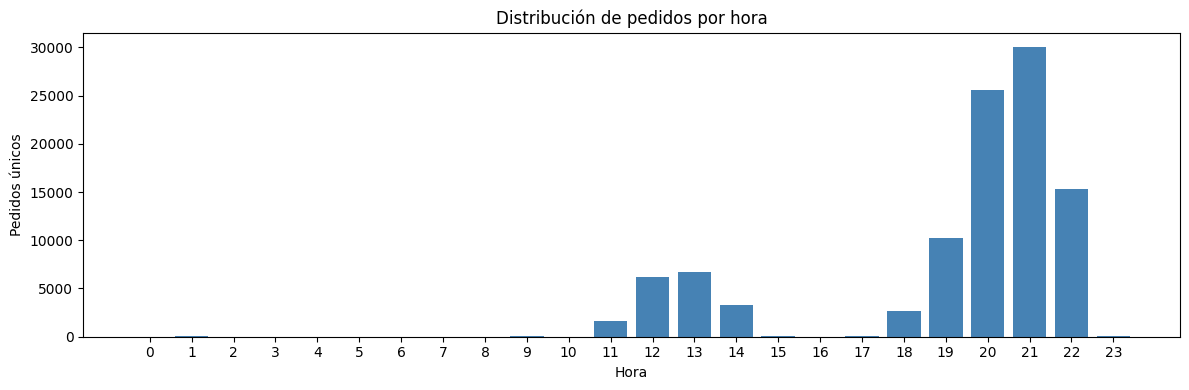

In [149]:
print("Distribución de pedidos por hora:")
ventas_por_hora = ventas.groupby('hora')['folio'].nunique().sort_index()
print(ventas_por_hora)

plt.figure(figsize=(12, 4))
plt.bar(ventas_por_hora.index, ventas_por_hora.values, color='steelblue')
plt.xlabel('Hora')
plt.ylabel('Pedidos únicos')
plt.title('Distribución de pedidos por hora')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#### Observaciones Grupo 10

- **idturno, turno_apertura, turno_cierre:** se usan para derivar la variable `turno` y luego se eliminan.
- **cierre, cierremes, cierresemana, cierredia, cierreyear:** redundantes con `fecha`, se eliminan.
- **observaciones:** 293,561 nulos y sin estructura útil, se elimina.
- Se identifican dos turnos claros con gap entre 15:00 y 18:00.

### Resumen de Limpieza

- Dataset reducido de 64 a 28 columnas.
- Variables redundantes, constantes y sin valor analítico eliminadas.
- Tipos de datos corregidos: precios a float, fechas a datetime.
- Variables nuevas creadas: `canal`, `turno`, `hora`, `fecha_dia`, `tiene_cliente`, `descripcion_normalizada`, `categoria_web`.
- Nulos esperables: pedidos anónimos en `idcliente` y `cliente_alta`, pedidos de mostrador en `cliente_direccion`.

#### Transformaciones Grupo 10

In [150]:
# Crear variable turno
def clasificar_turno(hora):
    if pd.isna(hora):
        return 'desconocido'
    elif 8 <= hora < 16:
        return 'mediodia'
    else:
        return 'noche'

ventas['turno'] = ventas['hora'].apply(clasificar_turno)

# Eliminar columnas innecesarias
ventas.drop(columns=['idturno', 'turno_apertura', 'turno_cierre', 'cierre',
                     'cierredia', 'cierreyear', 'observaciones'], inplace=True)

print("Distribución de turnos:")
print(ventas['turno'].value_counts())
print(f"\nColumnas restantes: {ventas.shape[1]}")

Distribución de turnos:
turno
noche       603906
mediodia    121062
Name: count, dtype: int64

Columnas restantes: 28


In [151]:
print(pd.crosstab(ventas['sucursal'], ventas['turno']))

turno     mediodia   noche
sucursal                  
COR             78  276805
PC          120984  327101


In [152]:
print(ventas[(ventas['sucursal'] == 'COR') & (ventas['turno'] == 'mediodia')]['hora'].value_counts().sort_index())

hora
9      3
10     6
11    31
12    17
13     9
14     3
15     9
Name: count, dtype: int64


### Resumen de Limpieza

In [153]:
print(f"Filas:    {len(ventas):,}")
print(f"Columnas: {ventas.shape[1]}")
print(f"\nColumnas finales:")
for col in ventas.columns:
    print(f"  {col:<35} {ventas[col].dtype}")
print(f"\nNulos por columna:")
nulos = ventas.isnull().sum()
print(nulos[nulos > 0])

Filas:    724,968
Columnas: 28

Columnas finales:
  sucursal                            object
  folio                               int64
  descuento                           float64
  precio                              float64
  cantidad                            float64
  idproducto                          int64
  descripcion                         object
  productocompuestoprincipal          int64
  modificador                         int64
  fecha                               datetime64[ns]
  idcliente                           object
  totalarticulos                      float64
  total                               float64
  descuentoimporte                    float64
  pago_efectivo                       float64
  pago_tarjeta                        float64
  cliente_direccion                   object
  cliente_alta                        datetime64[ns]
  calcpreciomenosdescuento            float64
  cierremes                           int64
  cierresemana                

## 4. Guardado del Dataset Limpio

In [154]:
ventas.to_csv(RUTA + 'ventas_limpio.csv', index=False)
print("Dataset guardado correctamente.")
print(f"Filas:    {len(ventas):,}")
print(f"Columnas: {ventas.shape[1]}")

Dataset guardado correctamente.
Filas:    724,968
Columnas: 28


## 5. Análisis Exploratorio de Datos (EDA)

Se analiza el comportamiento de las ventas desde distintas perspectivas:
temporal, por producto, por canal y por sucursal.

### 5.1 Análisis Temporal

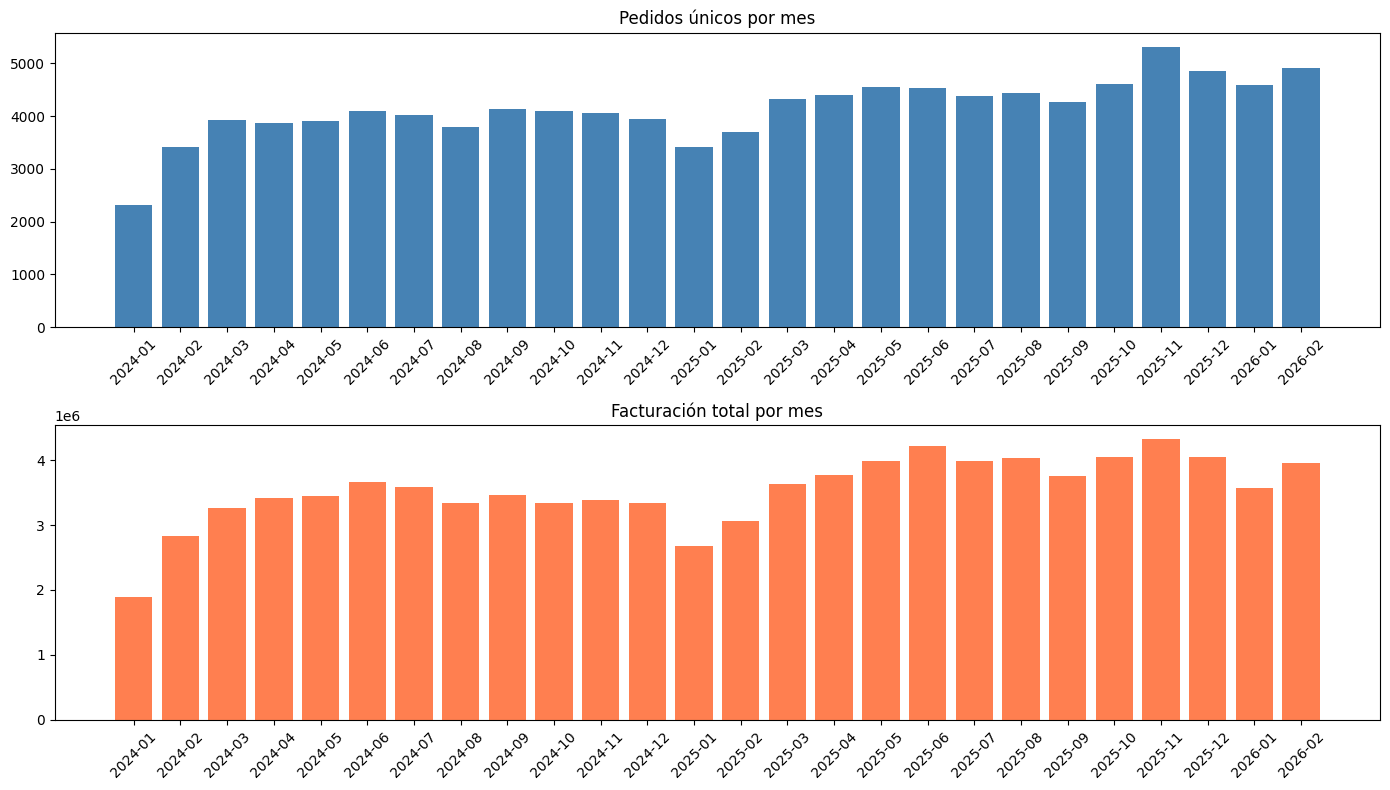

In [155]:
ventas['total'] = ventas['total'].apply(limpiar_precio) if ventas['total'].dtype == 'object' else ventas['total']

# Pedidos válidos (excluimos ajustes)
pedidos_validos = ventas[(ventas['total'] > 0) & (ventas['categoria_web'] != 'Ajustes')].copy()

# Clave única de pedido
pedidos_validos['pedido_id'] = pedidos_validos['sucursal'] + '-' + pedidos_validos['folio'].astype(str)

# Agregar a nivel pedido primero
pedidos = pedidos_validos.groupby(['pedido_id', 'fecha']).agg(
    total = ('total', 'first')
).reset_index()

# Evolución mensual
pedidos['anio_mes'] = pedidos['fecha'].dt.to_period('M')

evolucion = pedidos.groupby('anio_mes').agg(
    pedidos     = ('pedido_id', 'nunique'),
    facturacion = ('total', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(evolucion['anio_mes'].astype(str), evolucion['pedidos'], color='steelblue')
axes[0].set_title('Pedidos únicos por mes')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(evolucion['anio_mes'].astype(str), evolucion['facturacion'], color='coral')
axes[1].set_title('Facturación total por mes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Creación del Dataset de Pedidos

Se agrega el dataset de líneas a nivel pedido, que es la unidad de negocio real.
Cada fila representa un pedido completo con sus totales, productos y características.

In [156]:
# Vista de un pedido completo para entender la estructura
ver_pedido(121, 'COR')

,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
1464,ACUERDO COMERCIAL TARJETAS DE CREDITO,Ajustes,1.0,46394.72,0.0,46394.72,46394.72



Total del pedido: 46,394.72
Fecha:            2024-01-11 15:26:27
Canal:            LOCAL


In [157]:
# Buscar un pedido con varias líneas
folio_ejemplo = ventas[ventas['categoria_web'] == 'Empanadas']['folio'].iloc[0]
sucursal_ejemplo = ventas[ventas['categoria_web'] == 'Empanadas']['sucursal'].iloc[0]

print(f"Folio: {folio_ejemplo}, Sucursal: {sucursal_ejemplo}")
ver_pedido(folio_ejemplo, sucursal_ejemplo)

Folio: 8, Sucursal: PC


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
0,3 + BEBIDA DE REGALO,Promos,1.0,360.0,15.0,306.0,306.0
1,COCA-COLA SABOR ORIGINAL,Bebidas,1.0,0.0,15.0,0.0,306.0
2,TUCUMANA,Empanadas,1.0,0.0,15.0,0.0,306.0
3,RICO POLLO,Empanadas,1.0,0.0,15.0,0.0,306.0
4,QUESO Y VERDEO,Empanadas,1.0,0.0,15.0,0.0,306.0



Total del pedido: 306.00
Fecha:            2024-01-08 13:25:08
Canal:            LOCAL


#### Observaciones sobre la estructura de pedidos

A partir del análisis de un pedido ejemplo se identifican las siguientes características:

- **total:** se repite en todas las líneas del pedido — se toma `first` al agregar.
- **precio:** los componentes de promos tienen precio 0 — no sumar directamente.
- **descuento:** aparece en todas las líneas — tomar el valor del pedido, no sumar.
- **cantidad:** sumar solo para líneas de empanadas reales, excluyendo componentes de promos (`modificador = 1`).
- **productocompuestoprincipal:** indica si la línea es el producto principal de una promo (1) o un componente (0).

In [158]:
# Pedido con delivery (canal H o PY)
folio_delivery = ventas[ventas['canal'].isin(['H', 'PY'])]['folio'].iloc[100]
sucursal_delivery = ventas[ventas['canal'].isin(['H', 'PY'])]['sucursal'].iloc[100]

print("=== PEDIDO CON DELIVERY ===")
print(f"Folio: {folio_delivery}, Sucursal: {sucursal_delivery}")
ver_pedido(folio_delivery, sucursal_delivery)

# Pedido sin promo con múltiples sabores
folio_multi = ventas[
    (ventas['categoria_web'] == 'Empanadas') &
    (ventas['modificador'] == 0)
].groupby(['folio', 'sucursal']).filter(lambda x: len(x) >= 4)['folio'].iloc[0]

sucursal_multi = ventas[
    (ventas['categoria_web'] == 'Empanadas') &
    (ventas['modificador'] == 0)
].groupby(['folio', 'sucursal']).filter(lambda x: len(x) >= 4)['sucursal'].iloc[0]

print("\n=== PEDIDO CON MÚLTIPLES SABORES SIN PROMO ===")
print(f"Folio: {folio_multi}, Sucursal: {sucursal_multi}")
ver_pedido(folio_multi, sucursal_multi)

=== PEDIDO CON DELIVERY ===
Folio: 72, Sucursal: COR


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
737,NUEVA CAPRESE,Empanadas,2.0,130.0,0.0,130.0,1170.0
738,QUESO Y ACEITUNAS MARINADAS,Empanadas,2.0,130.0,0.0,130.0,1170.0
739,HUMITA,Empanadas,1.0,130.0,0.0,130.0,1170.0
740,TUCUMANA,Empanadas,2.0,130.0,0.0,130.0,1170.0
741,CORDERO,Empanadas,1.0,130.0,0.0,130.0,1170.0
742,QUESO Y VERDEO,Empanadas,1.0,130.0,0.0,130.0,1170.0



Total del pedido: 1,170.00
Fecha:            2024-01-09 21:59:31
Canal:            PY

=== PEDIDO CON MÚLTIPLES SABORES SIN PROMO ===
Folio: 18, Sucursal: PC


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
43,BERENJENA,Empanadas,1.0,120.0,100.0,0.0,0.0
44,ARABE,Empanadas,5.0,120.0,100.0,0.0,0.0
45,BERENJENA,Empanadas,1.0,120.0,100.0,0.0,0.0
46,BERENJENA,Empanadas,1.0,120.0,100.0,0.0,0.0
47,BERENJENA,Empanadas,1.0,120.0,100.0,0.0,0.0



Total del pedido: 0.00
Fecha:            2024-01-08 19:00:12
Canal:            LOCAL


In [159]:
# Pedido con descuento parcial
folio_desc = ventas[
    (ventas['descuento'] > 0) &
    (ventas['descuento'] < 100) &
    (ventas['total'] > 0)
]['folio'].iloc[0]

sucursal_desc = ventas[
    (ventas['descuento'] > 0) &
    (ventas['descuento'] < 100) &
    (ventas['total'] > 0)
]['sucursal'].iloc[0]

print(f"Folio: {folio_desc}, Sucursal: {sucursal_desc}")
ver_pedido(folio_desc, sucursal_desc)

Folio: 8, Sucursal: PC


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
0,3 + BEBIDA DE REGALO,Promos,1.0,360.0,15.0,306.0,306.0
1,COCA-COLA SABOR ORIGINAL,Bebidas,1.0,0.0,15.0,0.0,306.0
2,TUCUMANA,Empanadas,1.0,0.0,15.0,0.0,306.0
3,RICO POLLO,Empanadas,1.0,0.0,15.0,0.0,306.0
4,QUESO Y VERDEO,Empanadas,1.0,0.0,15.0,0.0,306.0



Total del pedido: 306.00
Fecha:            2024-01-08 13:25:08
Canal:            LOCAL


In [160]:
folio_desc = ventas[
    (ventas['descuento'] > 0) &
    (ventas['descuento'] < 100) &
    (ventas['total'] > 0) &
    (ventas['categoria_web'] == 'Empanadas') &
    (ventas['modificador'] == 0)
]['folio'].iloc[0]

sucursal_desc = ventas[
    (ventas['descuento'] > 0) &
    (ventas['descuento'] < 100) &
    (ventas['total'] > 0) &
    (ventas['categoria_web'] == 'Empanadas') &
    (ventas['modificador'] == 0)
]['sucursal'].iloc[0]

print(f"Folio: {folio_desc}, Sucursal: {sucursal_desc}")
ver_pedido(folio_desc, sucursal_desc)

Folio: 14, Sucursal: PC


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
7,AGUA CON GAS VITALE 625ML,Bebidas,1.0,110.0,15.0,93.5,705.5
8,3 + BEBIDA DE REGALO,Promos,1.0,360.0,15.0,306.0,705.5
9,NUEVA CAPRESE,Empanadas,1.0,0.0,15.0,0.0,705.5
10,"ESPINACA, RICOTA Y PARMESANO",Empanadas,1.0,0.0,15.0,0.0,705.5
11,RICO POLLO,Empanadas,1.0,0.0,15.0,0.0,705.5
12,COCA-COLA SIN AZUCAR,Bebidas,1.0,0.0,15.0,0.0,705.5
13,TUCUMANA,Empanadas,1.0,120.0,15.0,102.0,705.5
14,ARABE,Empanadas,1.0,120.0,15.0,102.0,705.5
15,RICO POLLO,Empanadas,1.0,120.0,15.0,102.0,705.5



Total del pedido: 705.50
Fecha:            2024-01-08 14:21:08
Canal:            LOCAL


#### Observaciones adicionales sobre estructura de pedidos

- **Sabores duplicados:** un mismo sabor puede aparecer en múltiples líneas — hay que sumar cantidades por sabor.
- **Componentes de promo:** tienen precio 0 y `modificador = 1` — excluir del conteo de empanadas individuales.
- **Descuento:** se aplica a nivel línea pero el importe total del descuento está en `descuentoimporte`.
- **Pedidos con descuento 100%:** total $0, pueden ser cortesías o errores — a considerar en el filtrado.
- **calcpreciomenosdescuento:** refleja el precio final real de cada línea, es la variable más confiable para precios.

#### Análisis de Campeonitas y Frescas

Antes de definir la estrategia de agregación se analiza el comportamiento de estas
categorías especiales para decidir si se incluyen o excluyen del dataset de pedidos.

In [161]:
# Ver distribución de campeonitas
camp = ventas[ventas['categoria_web'] == 'Campeonitas']
print("Distribución de Campeonitas:")
print(camp['descripcion_normalizada'].value_counts())

print(f"\n¿Cuántos pedidos únicos involucran Campeonitas?")
pedidos_camp = camp.groupby(['folio', 'sucursal']).size().reset_index()
print(f"Total: {len(pedidos_camp):,}")

print(f"\n¿Qué % del total de pedidos representan?")
total_pedidos = ventas.groupby(['folio', 'sucursal']).ngroups
print(f"{len(pedidos_camp)/total_pedidos*100:.2f}%")

Distribución de Campeonitas:
descripcion_normalizada
50 CAMP     126
XX CAMP      68
100 CAMP     31
150 CAMP     13
200 CAMP      3
Name: count, dtype: int64

¿Cuántos pedidos únicos involucran Campeonitas?
Total: 219

¿Qué % del total de pedidos representan?
0.20%


In [162]:
folio_camp = ventas[ventas['categoria_web'] == 'Campeonitas']['folio'].iloc[0]
sucursal_camp = ventas[ventas['categoria_web'] == 'Campeonitas']['sucursal'].iloc[0]

print(f"Folio: {folio_camp}, Sucursal: {sucursal_camp}")
ver_pedido(folio_camp, sucursal_camp)

Folio: 125, Sucursal: PC


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
978,50 CAMP,Campeonitas,1.0,4100.0,25.0,3075.0,3075.0



Total del pedido: 3,075.00
Fecha:            2024-01-10 20:08:25
Canal:            LOCAL


In [163]:
folio_fresca = ventas[ventas['categoria_web'] == 'Frescas']['folio'].iloc[0]
sucursal_fresca = ventas[ventas['categoria_web'] == 'Frescas']['sucursal'].iloc[0]

print(f"Folio: {folio_fresca}, Sucursal: {sucursal_fresca}")
ver_pedido(folio_fresca, sucursal_fresca)

Folio: 64, Sucursal: PC


,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
467,6 FRESCAS HONGOS Y ROQUEFORT,Frescas,1.0,615.0,15.0,522.75,1045.5
468,6 FRESCAS CORDERO,Frescas,1.0,615.0,15.0,522.75,1045.5



Total del pedido: 1,045.50
Fecha:            2024-01-09 20:22:40
Canal:            LOCAL


#### Decisiones de agregación

- **Unidad de análisis:** un registro por pedido (`folio + sucursal`)
- **Total:** `first` — se repite en todas las líneas del pedido
- **Descuento:** `first` de `descuentoimporte` — importe total del descuento a nivel pedido
- **Cantidades:** sumar `cantidad` por sabor, excluyendo componentes de promos (`modificador = 1`)
- **Sabores duplicados:** un mismo sabor puede aparecer en múltiples líneas — sumar cantidades
- **Frescas y Campeonitas:** excluidas — son paquetes cerrados que distorsionan el conteo de unidades
- **Pedidos con total = 0:** excluidos — cortesías o errores de registro
- **Ajustes:** excluidos — no son ventas reales

### 6.1 Dataset de Pedidos

In [164]:
def crear_dataset_pedidos(df):

    # ── 1. Filtros previos ─────────────────────────────────────────────────
    df_filtrado = df[
        (df['total'] > 0) &
        (df['cantidad'] % 1 == 0) &
        (~df['categoria_web'].isin(['Ajustes', 'Frescas', 'Campeonitas']))
    ].copy()

    # ── 2. Clave única de pedido ───────────────────────────────────────────
    df_filtrado['pedido_id'] = df_filtrado['sucursal'] + '-' + df_filtrado['folio'].astype(str)

    # ── 3. Agregación base ─────────────────────────────────────────────────
    pedidos = df_filtrado.groupby('pedido_id').agg(
        sucursal          = ('sucursal', 'first'),
        folio             = ('folio', 'first'),
        fecha             = ('fecha', 'first'),
        fecha_dia         = ('fecha_dia', 'first'),
        hora              = ('hora', 'first'),
        turno             = ('turno', 'first'),
        canal             = ('canal', 'first'),
        idcliente         = ('idcliente', 'first'),
        tiene_cliente     = ('tiene_cliente', 'first'),
        cliente_direccion = ('cliente_direccion', 'first'),
        cliente_alta      = ('cliente_alta', 'first'),
        total             = ('total', 'first'),
        totalarticulos    = ('totalarticulos', 'first'),
        descuentoimporte  = ('descuentoimporte', 'first'),
        pago_efectivo     = ('pago_efectivo', 'first'),
        pago_tarjeta      = ('pago_tarjeta', 'first'),
        cierremes         = ('cierremes', 'first'),
        cierresemana      = ('cierresemana', 'first'),
    ).reset_index()

    # ── 4. Cantidades por sabor y total empanadas ──────────────────────────
    empanadas = df_filtrado[df_filtrado['categoria_web'] == 'Empanadas']

    # Total empanadas por pedido
    total_emp = empanadas.groupby('pedido_id')['cantidad'].sum().reset_index()
    total_emp.columns = ['pedido_id', 'cant_total_empanadas']

    # Cantidad por sabor
    sabores = empanadas.groupby(['pedido_id', 'descripcion_normalizada'])['cantidad'].sum().unstack(fill_value=0)
    sabores.columns = ['emp_' + col.lower().replace(' ', '_').replace(',', '') for col in sabores.columns]

    # ── 5. Cantidades de bebidas ───────────────────────────────────────────
    bebidas = df_filtrado[df_filtrado['categoria_web'] == 'Bebidas'].groupby('pedido_id')['cantidad'].sum().reset_index()
    bebidas.columns = ['pedido_id', 'cant_total_bebidas']

    # ── 6. Tipo de entrega ─────────────────────────────────────────────────
    df_filtrado['tipo_entrega'] = df_filtrado['canal'].map({
        'H': 'delivery',
        'PY': 'delivery',
        'LOCAL': 'local'
    })
    tipo_entrega = df_filtrado.groupby('pedido_id')['tipo_entrega'].first().reset_index()

    # ── 7. Flags de categorías ─────────────────────────────────────────────
    flags = df_filtrado.groupby('pedido_id').agg(
        tiene_promo  = ('categoria_web', lambda x: int('Promos' in x.values)),
        tiene_bebida = ('categoria_web', lambda x: int('Bebidas' in x.values)),
        tiene_postre = ('categoria_web', lambda x: int('Postres' in x.values)),
    )

    # ── 8. Unificación ─────────────────────────────────────────────────────
    pedidos = pedidos.merge(total_emp,   on='pedido_id', how='left')
    pedidos = pedidos.merge(sabores,     on='pedido_id', how='left')
    pedidos = pedidos.merge(bebidas,     on='pedido_id', how='left')
    pedidos = pedidos.merge(tipo_entrega, on='pedido_id', how='left')
    pedidos = pedidos.merge(flags,       on='pedido_id', how='left')

    pedidos[sabores.columns] = pedidos[sabores.columns].fillna(0)
    pedidos['cant_total_empanadas'] = pedidos['cant_total_empanadas'].fillna(0)
    pedidos['cant_total_bebidas']   = pedidos['cant_total_bebidas'].fillna(0)

    return pedidos

pedidos_df = crear_dataset_pedidos(ventas)

print(f"Pedidos:  {len(pedidos_df):,}")
print(f"Columnas: {pedidos_df.shape[1]}")

Pedidos:  107,116
Columnas: 40


In [165]:
emp_cols = [c for c in pedidos_df.columns if c.startswith('emp_')]

for pedido_id in ['PC-8', 'COR-72', 'PC-14', 'PC-18']:
    print(f"\n{'='*50}")
    print(f"=== PEDIDO {pedido_id} ===")
    print(f"{'='*50}")
    ped = pedidos_df[pedidos_df['pedido_id'] == pedido_id]
    if ped.empty:
        print(f"No existe en el dataset — filtrado por total = 0")
        continue
    print(ped[['pedido_id', 'total', 'cant_total_empanadas', 'cant_total_bebidas',
               'descuentoimporte', 'tiene_promo', 'tiene_bebida', 'tiene_postre',
               'tipo_entrega', 'canal']].T)
    sabores = ped[emp_cols].T
    sabores = sabores[sabores.iloc[:, 0] > 0]
    if not sabores.empty:
        print("\nSabores:")
        print(sabores)


=== PEDIDO PC-8 ===
                     105055
pedido_id              PC-8
total                 306.0
cant_total_empanadas    3.0
cant_total_bebidas      1.0
descuentoimporte      44.26
tiene_promo               1
tiene_bebida              1
tiene_postre              0
tipo_entrega          local
canal                 LOCAL

Sabores:
                    105055
emp_queso_y_verdeo     1.0
emp_rico_pollo         1.0
emp_tucumana           1.0

=== PEDIDO COR-72 ===
                         38680
pedido_id               COR-72
total                   1170.0
cant_total_empanadas       9.0
cant_total_bebidas         0.0
descuentoimporte           0.0
tiene_promo                  0
tiene_bebida                 0
tiene_postre                 0
tipo_entrega          delivery
canal                       PY

Sabores:
                                 38680
emp_cordero                        1.0
emp_humita                         1.0
emp_nueva_caprese                  2.0
emp_queso_y_aceitunas_m

In [166]:
print("=== PEDIDO PC-14 ===")
pc14 = pedidos_df[pedidos_df['pedido_id'] == 'PC-14']
print(pc14[['pedido_id', 'total', 'cant_total_empanadas', 'descuentoimporte',
            'tiene_promo', 'tiene_bebida', 'tiene_postre', 'tipo_entrega', 'canal']].T)

print("\n=== SABORES ===")
sabores_pc14 = pc14[emp_cols].T
sabores_pc14 = sabores_pc14[sabores_pc14.iloc[:, 0] > 0]
print(sabores_pc14)

=== PEDIDO PC-14 ===
                       45713
pedido_id              PC-14
total                  705.5
cant_total_empanadas     6.0
descuentoimporte      102.05
tiene_promo                1
tiene_bebida               1
tiene_postre               0
tipo_entrega           local
canal                  LOCAL

=== SABORES ===
                                 45713
emp_arabe                          1.0
emp_espinaca_ricota_y_parmesano    1.0
emp_nueva_caprese                  1.0
emp_rico_pollo                     2.0
emp_tucumana                       1.0


### 6.2 Guardado del Dataset de Pedidos

In [167]:
pedidos_df.to_csv(RUTA + 'dataset_pedidos.csv', index=False)

print(f"Dataset guardado correctamente.")
print(f"Pedidos:  {len(pedidos_df):,}")
print(f"Columnas: {pedidos_df.shape[1]}")
print(f"Período:  {pedidos_df['fecha'].min()} → {pedidos_df['fecha'].max()}")

Dataset guardado correctamente.
Pedidos:  107,116
Columnas: 40
Período:  2024-01-08 13:25:08 → 2026-02-28 22:48:58


## 7. Análisis Exploratorio de Datos (EDA)

Se analiza el comportamiento de las ventas desde distintas perspectivas:
temporal, por producto, por canal y por sucursal.



### 7.1 Análisis Temporal

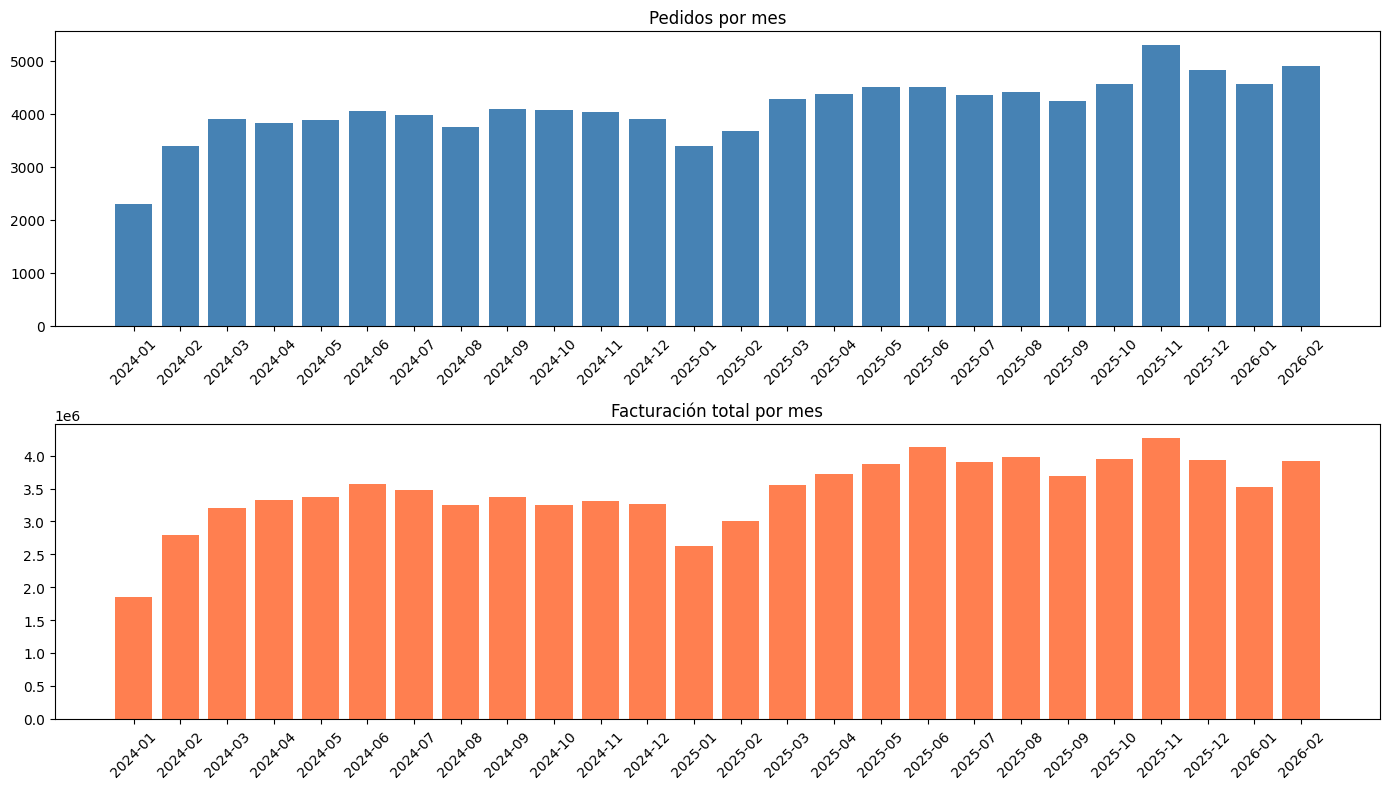

In [168]:
# Evolución mensual de pedidos y facturación
pedidos_df['anio_mes'] = pd.to_datetime(pedidos_df['fecha']).dt.to_period('M')

evolucion = pedidos_df.groupby('anio_mes').agg(
    pedidos     = ('pedido_id', 'count'),
    facturacion = ('total', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(evolucion['anio_mes'].astype(str), evolucion['pedidos'], color='steelblue')
axes[0].set_title('Pedidos por mes')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(evolucion['anio_mes'].astype(str), evolucion['facturacion'], color='coral')
axes[1].set_title('Facturación total por mes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [169]:
print(f"Ticket promedio: {pedidos_df['total'].mean():,.2f}")
print(f"Ticket mediana:  {pedidos_df['total'].median():,.2f}")
print(f"Ticket mínimo:   {pedidos_df['total'].min():,.2f}")
print(f"Ticket máximo:   {pedidos_df['total'].max():,.2f}")

Ticket promedio: 841.40
Ticket mediana:  693.01
Ticket mínimo:   0.01
Ticket máximo:   41,340.00


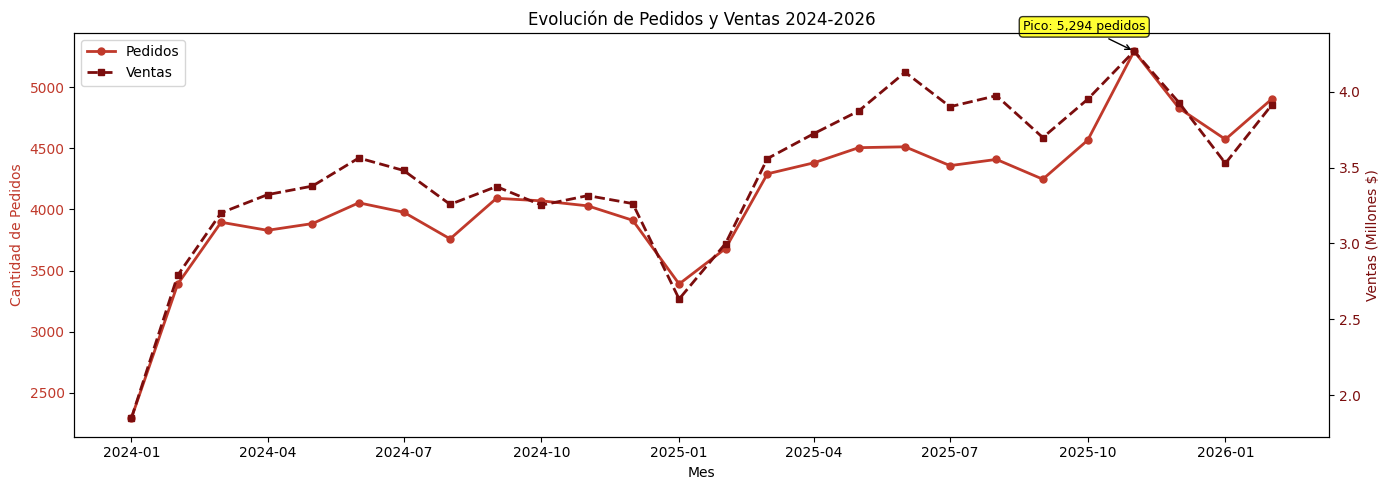

In [170]:
# ── Evolución mensual de pedidos y ventas ─────────────────────────────────
evol = pedidos_df.groupby('anio_mes').agg(
    pedidos = ('pedido_id', 'count'),
    ventas  = ('total', 'sum')
).reset_index()

evol['ventas_M'] = evol['ventas'] / 1_000_000
evol['anio_mes_dt'] = pd.to_datetime(evol['anio_mes'].astype(str), format='%Y-%m')

fig, ax1 = plt.subplots(figsize=(14, 5))

# Pedidos — eje izquierdo
ax1.plot(evol['anio_mes_dt'], evol['pedidos'],
         color='#c0392b', marker='o', linewidth=2, markersize=5, label='Pedidos')
ax1.set_ylabel('Cantidad de Pedidos', color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')

# Ventas — eje derecho
ax2 = ax1.twinx()
ax2.plot(evol['anio_mes_dt'], evol['ventas_M'],
         color='#7b0d0d', marker='s', linewidth=2, markersize=5,
         linestyle='--', label='Ventas')
ax2.set_ylabel('Ventas (Millones $)', color='#7b0d0d')
ax2.tick_params(axis='y', labelcolor='#7b0d0d')

# Pico
idx_pico = evol['pedidos'].idxmax()
ax1.annotate(f"Pico: {evol.loc[idx_pico, 'pedidos']:,} pedidos",
             xy=(evol.loc[idx_pico, 'anio_mes_dt'], evol.loc[idx_pico, 'pedidos']),
             xytext=(-80, 15), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.8))

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlabel('Mes')
ax1.set_title('Evolución de Pedidos y Ventas 2024-2026')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones - Evolución Temporal

- Enero 2024 muestra menos pedidos por ser el primer mes de datos, no refleja caída real.
- Tendencia creciente clara de 2024 a 2025 — el negocio está en expansión.
- Diciembre 2024 y enero 2025 muestran caída — estacionalidad de verano en Uruguay.
- Noviembre 2025 es el mes pico con más de 5,000 pedidos.
- La facturación crece proporcionalmente a los pedidos, el ticket promedio se mantiene estable.

### 7.2 Análisis del Ticket

=== ESTADÍSTICAS DESCRIPTIVAS ===
count    107116.000000
mean        841.403606
std         643.820592
min           0.010000
25%         460.000000
50%         693.010000
75%        1053.000000
max       41340.000000
Name: total, dtype: float64

Skewness: 7.45
Kurtosis: 213.10


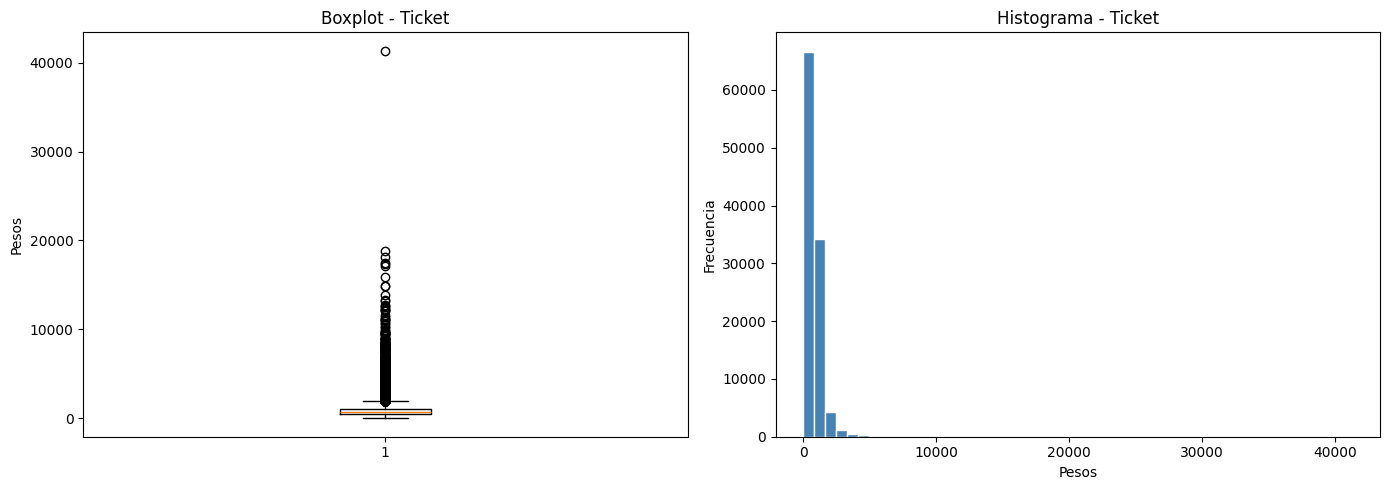

In [171]:
ticket = pedidos_df['total']

# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(ticket.describe())
print(f"\nSkewness: {ticket.skew():.2f}")
print(f"Kurtosis: {ticket.kurt():.2f}")

# Boxplot + histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(ticket, vert=True)
axes[0].set_title('Boxplot - Ticket')
axes[0].set_ylabel('Pesos')

axes[1].hist(ticket, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Histograma - Ticket')
axes[1].set_xlabel('Pesos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [172]:
print("=== PERCENTILES ===")
for p in [50, 75, 90, 95, 99, 99.5, 99.9]:
    val = ticket.quantile(p/100)
    n = (ticket > val).sum()
    print(f"  P{p:>4}: {val:>8,.2f} — {n:>5} pedidos por encima ({n/len(ticket)*100:.2f}%)")

print(f"\n=== PEDIDOS POR RANGO ===")
rangos = [500, 1000, 2000, 3000, 5000, 10000]
for r in rangos:
    n = (ticket <= r).sum()
    print(f"  Hasta ${r:>6,}: {n:>6,} pedidos ({n/len(ticket)*100:.1f}%)")

=== PERCENTILES ===
  P  50:   693.01 — 53555 pedidos por encima (50.00%)
  P  75: 1,053.00 — 26763 pedidos por encima (24.99%)
  P  90: 1,430.00 —  9847 pedidos por encima (9.19%)
  P  95: 1,755.00 —  5341 pedidos por encima (4.99%)
  P  99: 3,094.00 —  1060 pedidos por encima (0.99%)
  P99.5: 3,960.00 —   533 pedidos por encima (0.50%)
  P99.9: 6,803.60 —   108 pedidos por encima (0.10%)

=== PEDIDOS POR RANGO ===
  Hasta $   500: 30,219 pedidos (28.2%)
  Hasta $ 1,000: 78,893 pedidos (73.7%)
  Hasta $ 2,000: 103,415 pedidos (96.5%)
  Hasta $ 3,000: 105,997 pedidos (99.0%)
  Hasta $ 5,000: 106,855 pedidos (99.8%)
  Hasta $10,000: 107,087 pedidos (100.0%)


In [173]:
outliers = pedidos_df[pedidos_df['total'] > pedidos_df['total'].quantile(0.99)]
print(f"Pedidos outliers (>P99): {len(outliers):,}")
print(f"\nDistribución por canal:")
print(outliers['canal'].value_counts())
print(f"\nDistribución por sucursal:")
print(outliers['sucursal'].value_counts())
print(f"\nTop 10 tickets más altos:")
print(outliers.nlargest(10, 'total')[['pedido_id', 'total', 'cant_total_empanadas',
                                       'canal', 'sucursal', 'fecha']])

Pedidos outliers (>P99): 1,060

Distribución por canal:
canal
LOCAL    623
PY       259
H        178
Name: count, dtype: int64

Distribución por sucursal:
sucursal
PC     828
COR    232
Name: count, dtype: int64

Top 10 tickets más altos:
       pedido_id    total  cant_total_empanadas  canal sucursal  \
77532   PC-44695  41340.0                 346.0  LOCAL       PC   
50060    PC-1827  18810.0                   0.0  LOCAL       PC   
103648  PC-69593  18122.0                 178.0  LOCAL       PC   
100632   PC-6674  17490.0                   0.0  LOCAL       PC   
89820    PC-5644  17370.0                   6.0  LOCAL       PC   
69546   PC-37054  17160.0                 192.0  LOCAL       PC   
95436   PC-61748  15900.0                 120.0  LOCAL       PC   
67346   PC-34937  14850.0                 180.0  LOCAL       PC   
90928   PC-57496  14832.5                 146.0  LOCAL       PC   
97674   PC-63907  13860.0                 100.0  LOCAL       PC   

                     fe

In [174]:
ver_pedido(1827, 'PC')

,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
18317,DOCENA DE CAMPEONAS,Promos,9.0,1320.0,0.0,1320.0,18810.0
18318,6 + FRANUI,Promos,7.0,990.0,0.0,990.0,18810.0



Total del pedido: 18,810.00
Fecha:            2024-02-06 11:59:53
Canal:            LOCAL


In [175]:
# Ver cómo aparecen en el dataset original
docena = ventas[ventas['descripcion_normalizada'] == 'DOCENA DE CAMPEONAS']
print(f"Modificador values: {docena['modificador'].value_counts().to_dict()}")
print(f"Categoría: {docena['categoria_web'].unique()}")
print(f"\nEjemplo pedido 1827:")
print(ventas[ventas['folio'] == 1827][['descripcion_normalizada', 'categoria_web',
                                        'cantidad', 'modificador']].to_string())

Modificador values: {0: 12586}
Categoría: ['Promos']

Ejemplo pedido 1827:
            descripcion_normalizada categoria_web  cantidad  modificador
18317           DOCENA DE CAMPEONAS        Promos       9.0            0
18318                    6 + FRANUI        Promos       7.0            0
25216                         ARABE     Empanadas       1.0            0
25217                 NUEVA CAPRESE     Empanadas       1.0            0
25218  ESPINACA, RICOTA Y PARMESANO     Empanadas       1.0            0
25219  HONGOS SHIITAKE Y QUESO AZUL     Empanadas       1.0            0


In [176]:
print(ventas[ventas['folio'] == 1827][['folio', 'sucursal', 'descripcion_normalizada',
                                        'categoria_web', 'cantidad', 'modificador']].to_string())

       folio sucursal       descripcion_normalizada categoria_web  cantidad  modificador
18317   1827       PC           DOCENA DE CAMPEONAS        Promos       9.0            0
18318   1827       PC                    6 + FRANUI        Promos       7.0            0
25216   1827      COR                         ARABE     Empanadas       1.0            0
25217   1827      COR                 NUEVA CAPRESE     Empanadas       1.0            0
25218   1827      COR  ESPINACA, RICOTA Y PARMESANO     Empanadas       1.0            0
25219   1827      COR  HONGOS SHIITAKE Y QUESO AZUL     Empanadas       1.0            0


In [177]:
ver_pedido(1827, 'COR')

,descripcion_normalizada,categoria_web,cantidad,precio,descuento,calcpreciomenosdescuento,total
25216,ARABE,Empanadas,1.0,130.0,0.0,130.0,520.0
25217,NUEVA CAPRESE,Empanadas,1.0,130.0,0.0,130.0,520.0
25218,"ESPINACA, RICOTA Y PARMESANO",Empanadas,1.0,130.0,0.0,130.0,520.0
25219,HONGOS SHIITAKE Y QUESO AZUL,Empanadas,1.0,130.0,0.0,130.0,520.0



Total del pedido: 520.00
Fecha:            2024-02-15 21:22:24
Canal:            PY


In [178]:
print(ventas[(ventas['folio'] == 1827) & (ventas['sucursal'] == 'PC')]
      [['folio', 'sucursal', 'descripcion_normalizada', 'categoria_web', 'cantidad', 'modificador']].to_string())

       folio sucursal descripcion_normalizada categoria_web  cantidad  modificador
18317   1827       PC     DOCENA DE CAMPEONAS        Promos       9.0            0
18318   1827       PC              6 + FRANUI        Promos       7.0            0


#### Observaciones - Análisis del Ticket

- Distribución muy sesgada a la derecha (skewness: 7.45, kurtosis: 213) — la gran mayoría de pedidos se concentra entre $460 y $1,053.
- El 99% de los pedidos está por debajo de $3,094.
- Los outliers (>P99) son en su mayoría pedidos de catering o eventos — legítimos pero atípicos. Se concentran en PC, canal LOCAL y horario de mediodía.
- Ticket promedio: $841 — mediana: $693. La diferencia entre ambos confirma el sesgo por pedidos grandes.
- Para el análisis de comportamiento típico del negocio se trabajará filtrando pedidos hasta el P99 ($3,094).
- Al comparar sucursales siempre se controlará por turno, ya que COR no opera al mediodía.

### 7.3 Análisis por Día de la Semana

=== ESTADÍSTICAS POR DÍA DE LA SEMANA ===
            pedidos   media  mediana  desvio   min     max
dia_semana                                                
Lunes         13086  761.68    663.0  442.05  0.01  3060.0
Martes        13503  795.74    675.0  474.47  0.99  3094.0
Miércoles     13854  785.88    675.0  470.69  0.01  3094.0
Jueves        14831  793.63    675.0  470.41  0.01  3094.0
Viernes       17902  799.64    693.0  462.81  0.01  3094.0
Sábado        15756  832.55    720.0  464.08  0.01  3094.0
Domingo       17124  836.59    724.5  452.93  0.01  3094.0


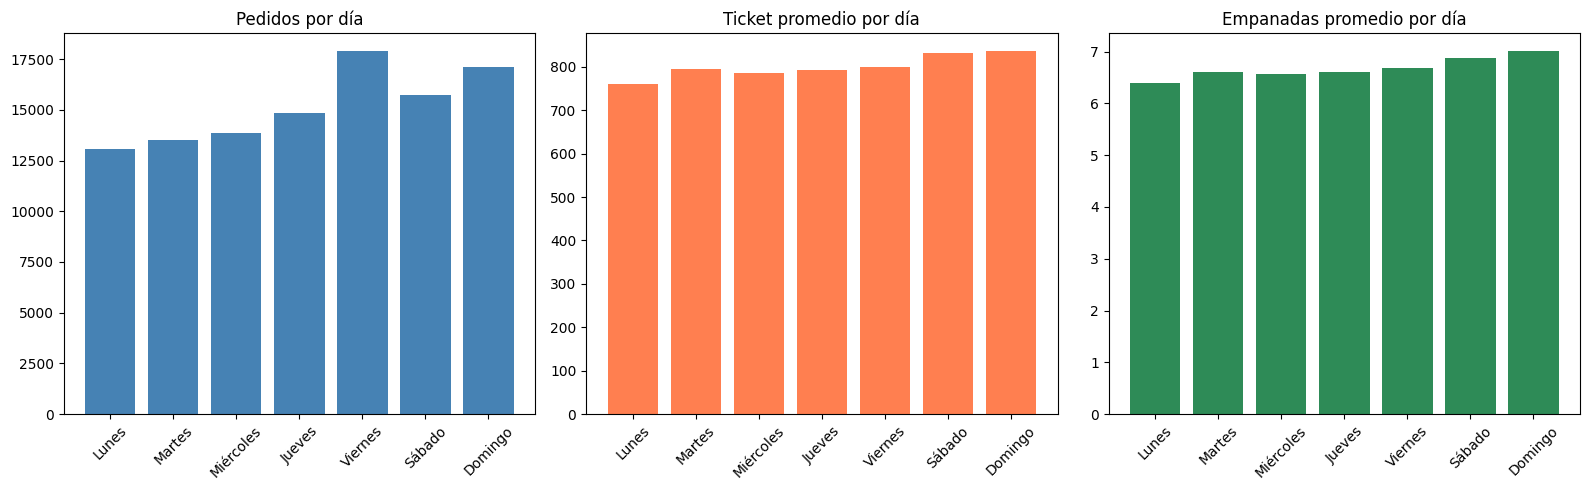

In [179]:
pedidos_df['dia_semana'] = pd.to_datetime(pedidos_df['fecha']).dt.day_name()
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dias_map = dict(zip(dias_orden, dias_es))
pedidos_df['dia_semana'] = pedidos_df['dia_semana'].map(dias_map)

# Filtrar outliers
p99 = pedidos_df['total'].quantile(0.99)
pedidos_analisis = pedidos_df[pedidos_df['total'] <= p99].copy()

# Estadísticas descriptivas por día
print("=== ESTADÍSTICAS POR DÍA DE LA SEMANA ===")
stats_dia = pedidos_analisis.groupby('dia_semana')['total'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).reindex(dias_es)
stats_dia.columns = ['pedidos', 'media', 'mediana', 'desvio', 'min', 'max']
print(stats_dia.round(2))

# Gráficos
stats_dia_plot = pedidos_analisis.groupby('dia_semana').agg(
    pedidos            = ('pedido_id', 'count'),
    ticket_promedio    = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reindex(dias_es).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(stats_dia_plot['dia_semana'], stats_dia_plot['pedidos'], color='steelblue')
axes[0].set_title('Pedidos por día')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(stats_dia_plot['dia_semana'], stats_dia_plot['ticket_promedio'], color='coral')
axes[1].set_title('Ticket promedio por día')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(stats_dia_plot['dia_semana'], stats_dia_plot['empanadas_promedio'], color='seagreen')
axes[2].set_title('Empanadas promedio por día')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Observaciones - Análisis por Día de la Semana

- Viernes y domingo concentran la mayor cantidad de pedidos, consistente con hábitos de consumo uruguayos.
- Lunes es el día más bajo en volumen y ticket — el negocio tiene una promo "Anti Lunes" que reconoce este patrón.
- El ticket promedio crece hacia el fin de semana ($762 lunes → $ 837 domingo).
- La cantidad de empanadas por pedido es muy estable (6.5–7.0) independientemente del día.
- El desvío estándar es alto (~$450–$475) en todos los días, confirmando la heterogeneidad de pedidos.

### 7.4 Análisis por Turno

=== ESTADÍSTICAS POR TURNO ===
          pedidos   media  mediana  desvio   min     max
turno                                                   
mediodia    16877  672.74    520.0  492.12  0.01  3094.0
noche       89179  827.27    720.0  453.29  0.01  3094.0

=== ESTADÍSTICAS POR TURNO Y SUCURSAL ===
                   pedidos   media  mediana  desvio
sucursal turno                                     
COR      mediodia        1  102.01   102.01     NaN
         noche       41371  803.69   720.00  431.99
PC       mediodia    16876  672.77   520.00  492.12
         noche       47808  847.67   739.50  469.98


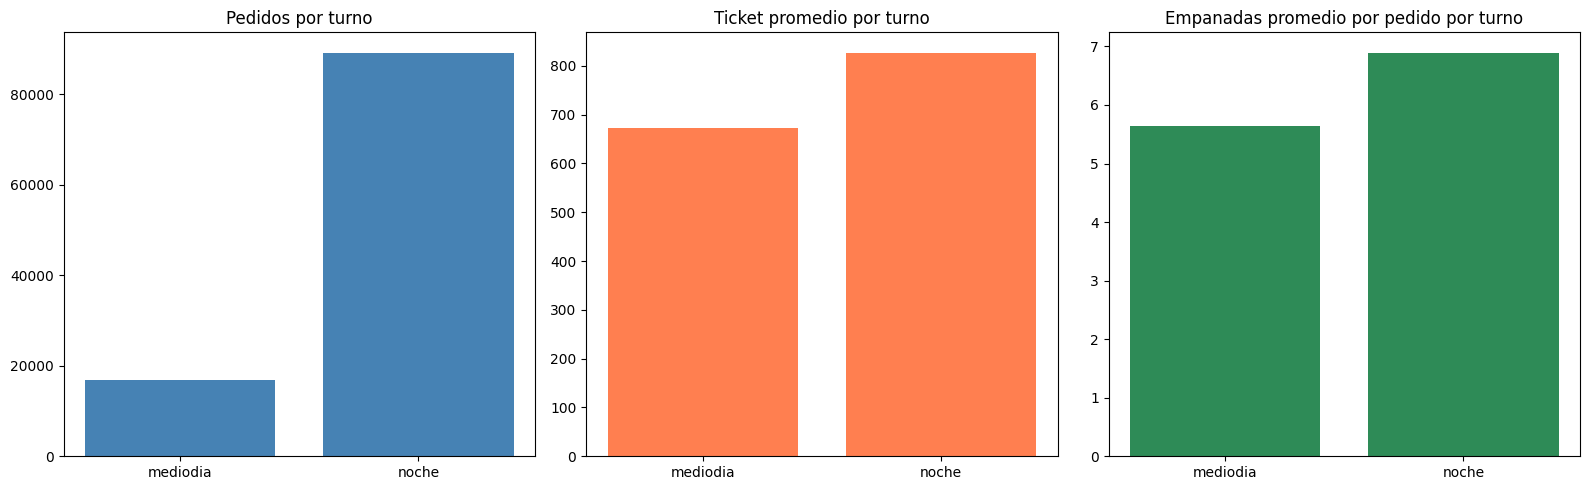

In [180]:
# Estadísticas descriptivas por turno
print("=== ESTADÍSTICAS POR TURNO ===")
stats_turno = pedidos_analisis.groupby('turno')['total'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
stats_turno.columns = ['pedidos', 'media', 'mediana', 'desvio', 'min', 'max']
print(stats_turno.round(2))

# Por turno y sucursal (controlando COR sin mediodía)
print("\n=== ESTADÍSTICAS POR TURNO Y SUCURSAL ===")
stats_turno_suc = pedidos_analisis.groupby(['sucursal', 'turno'])['total'].agg(
    ['count', 'mean', 'median', 'std']
)
stats_turno_suc.columns = ['pedidos', 'media', 'mediana', 'desvio']
print(stats_turno_suc.round(2))

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

stats_t = pedidos_analisis.groupby('turno').agg(
    pedidos            = ('pedido_id', 'count'),
    ticket_promedio    = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reset_index()

axes[0].bar(stats_t['turno'], stats_t['pedidos'], color='steelblue')
axes[0].set_title('Pedidos por turno')

axes[1].bar(stats_t['turno'], stats_t['ticket_promedio'], color='coral')
axes[1].set_title('Ticket promedio por turno')

axes[2].bar(stats_t['turno'], stats_t['empanadas_promedio'], color='seagreen')
axes[2].set_title('Empanadas promedio por pedido por turno')

plt.tight_layout()
plt.show()

#### Observaciones - Análisis por Turno

- El turno noche concentra el *83%* de los pedidos — es el turno principal del negocio.
- El ticket promedio de noche es significativamente mayor (*827 vs 673*) — pedidos más grandes.
- Las empanadas por pedido también son mayores de noche (*7.0 vs 5.6*).
- COR opera prácticamente solo en turno noche — 1 pedido registrado al mediodía en todo el período.
- PC noche tiene el ticket más alto de todas las combinaciones sucursal-turno (*848*).
- Al comparar sucursales se usará exclusivamente el turno noche para evitar sesgo.

### 7.5 Análisis por Sucursal

=== ESTADÍSTICAS POR SUCURSAL (turno noche) ===
          pedidos   media  mediana  desvio   min     max
sucursal                                                
COR         41371  803.69    720.0  431.99  0.01  3094.0
PC          47808  847.67    739.5  469.98  0.01  3094.0


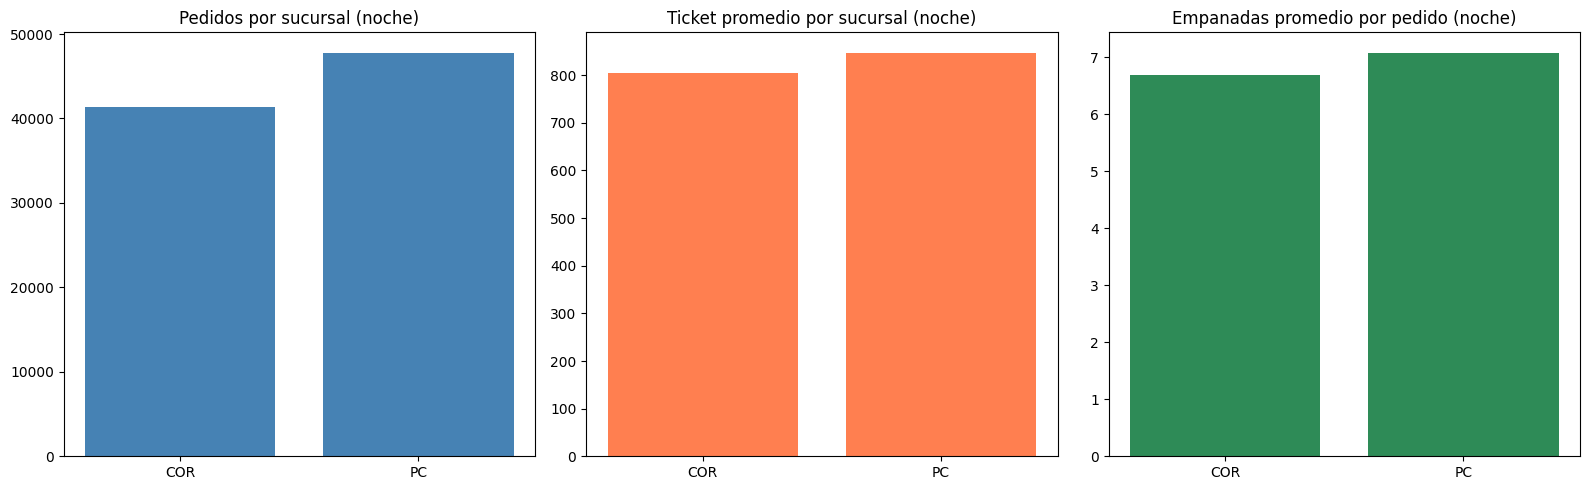

In [181]:
# Solo turno noche para comparación justa
pedidos_noche = pedidos_analisis[pedidos_analisis['turno'] == 'noche'].copy()

# Estadísticas descriptivas por sucursal
print("=== ESTADÍSTICAS POR SUCURSAL (turno noche) ===")
stats_suc = pedidos_noche.groupby('sucursal')['total'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
stats_suc.columns = ['pedidos', 'media', 'mediana', 'desvio', 'min', 'max']
print(stats_suc.round(2))

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

stats_s = pedidos_noche.groupby('sucursal').agg(
    pedidos            = ('pedido_id', 'count'),
    ticket_promedio    = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reset_index()

axes[0].bar(stats_s['sucursal'], stats_s['pedidos'], color='steelblue')
axes[0].set_title('Pedidos por sucursal (noche)')

axes[1].bar(stats_s['sucursal'], stats_s['ticket_promedio'], color='coral')
axes[1].set_title('Ticket promedio por sucursal (noche)')

axes[2].bar(stats_s['sucursal'], stats_s['empanadas_promedio'], color='seagreen')
axes[2].set_title('Empanadas promedio por pedido (noche)')

plt.tight_layout()
plt.show()

#### Observaciones - Análisis por Sucursal (turno noche)

- PC tiene más pedidos que COR (*47,808 vs 41,371*) — aproximadamente un *15%* más de volumen.
- El ticket promedio de PC es levemente mayor (*848 vs 804*) — diferencia del *5%*.
- Las empanadas por pedido son similares (*7.0 PC vs 6.8 COR*) — el tamaño del pedido es comparable.
- El desvío estándar es alto en ambas sucursales (*~430–470*) — alta variabilidad en el ticket.
- Las diferencias entre sucursales son moderadas — ambas operan con patrones similares de consumo.

### 7.6 Análisis PC por Turno

=== ESTADÍSTICAS PC POR TURNO ===
          pedidos   media  mediana  desvio   min     max
turno                                                   
mediodia    16876  672.77    520.0  492.12  0.01  3094.0
noche       47808  847.67    739.5  469.98  0.01  3094.0

=== EMPANADAS POR TURNO (PC) ===
          mean  median   std
turno                       
mediodia  5.64     4.0  4.47
noche     7.08     6.0  4.31


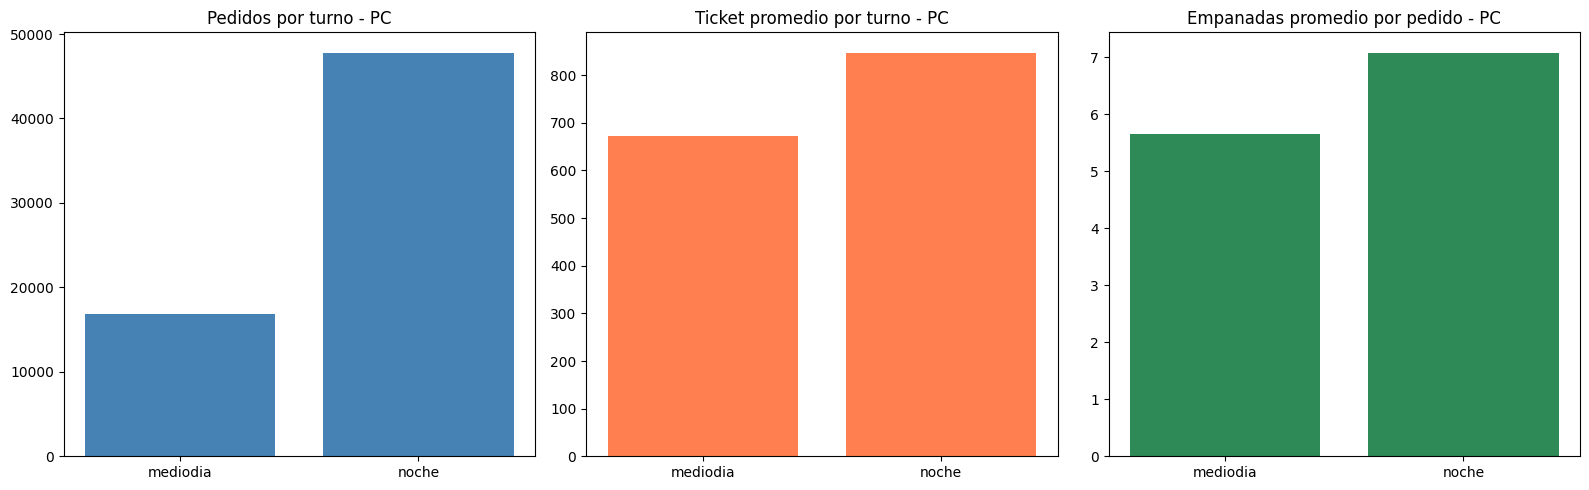

In [182]:
pc = pedidos_analisis[pedidos_analisis['sucursal'] == 'PC'].copy()

print("=== ESTADÍSTICAS PC POR TURNO ===")
stats_pc = pc.groupby('turno')['total'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
stats_pc.columns = ['pedidos', 'media', 'mediana', 'desvio', 'min', 'max']
print(stats_pc.round(2))

print("\n=== EMPANADAS POR TURNO (PC) ===")
print(pc.groupby('turno')['cant_total_empanadas'].agg(['mean', 'median', 'std']).round(2))

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

stats_pt = pc.groupby('turno').agg(
    pedidos            = ('pedido_id', 'count'),
    ticket_promedio    = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reset_index()

axes[0].bar(stats_pt['turno'], stats_pt['pedidos'], color='steelblue')
axes[0].set_title('Pedidos por turno - PC')

axes[1].bar(stats_pt['turno'], stats_pt['ticket_promedio'], color='coral')
axes[1].set_title('Ticket promedio por turno - PC')

axes[2].bar(stats_pt['turno'], stats_pt['empanadas_promedio'], color='seagreen')
axes[2].set_title('Empanadas promedio por pedido - PC')

plt.tight_layout()
plt.show()

#### Observaciones - PC por Turno

- El turno noche concentra el *74%* de los pedidos de PC (*47,808 vs 16,876*).
- El ticket promedio de noche es significativamente mayor (*848 vs 673*) — diferencia del *26%*.
- Las empanadas por pedido también son mayores de noche (*7.1 vs 5.6*).
- La mediana de empanadas al mediodía es *4* vs *6* de noche — pedidos más chicos y más variables al mediodía.
- El desvío estándar del ticket al mediodía es mayor (*492 vs 470*) — más heterogeneidad en los pedidos de mediodía, probablemente por la mezcla de pedidos individuales y catering.

### 7.7 Análisis por Canal

=== ESTADÍSTICAS POR CANAL (turno noche) ===
       pedidos   media  mediana  desvio    min     max
canal                                                 
H        25175  855.46   773.49  431.31   1.08  3094.0
LOCAL    28870  789.38   714.00  466.46  11.25  3094.0
PY       35134  838.21   690.00  455.61   0.01  3090.0

=== EMPANADAS POR CANAL (turno noche) ===
       mean  median   std
canal                    
H      7.38     6.0  4.08
LOCAL  7.09     6.0  4.78
PY     6.39     6.0  3.51


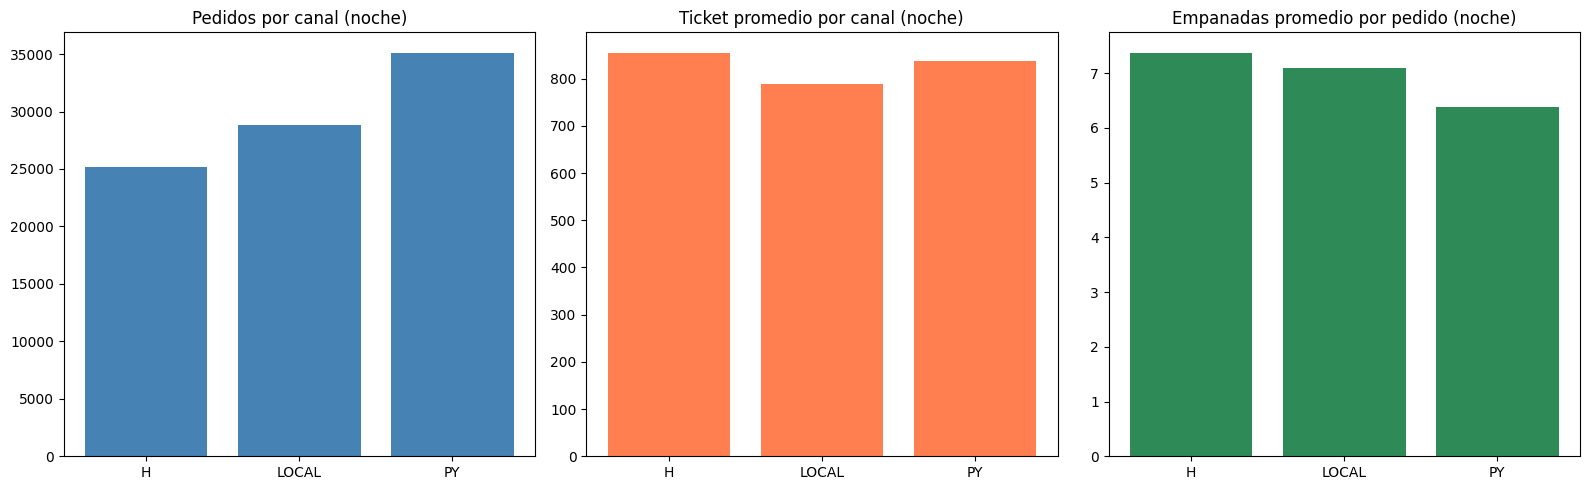

In [183]:
# Estadísticas descriptivas por canal
print("=== ESTADÍSTICAS POR CANAL (turno noche) ===")
stats_canal = pedidos_noche.groupby('canal')['total'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
stats_canal.columns = ['pedidos', 'media', 'mediana', 'desvio', 'min', 'max']
print(stats_canal.round(2))

print("\n=== EMPANADAS POR CANAL (turno noche) ===")
print(pedidos_noche.groupby('canal')['cant_total_empanadas'].agg(['mean', 'median', 'std']).round(2))

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

stats_c = pedidos_noche.groupby('canal').agg(
    pedidos            = ('pedido_id', 'count'),
    ticket_promedio    = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reset_index()

axes[0].bar(stats_c['canal'], stats_c['pedidos'], color='steelblue')
axes[0].set_title('Pedidos por canal (noche)')

axes[1].bar(stats_c['canal'], stats_c['ticket_promedio'], color='coral')
axes[1].set_title('Ticket promedio por canal (noche)')

axes[2].bar(stats_c['canal'], stats_c['empanadas_promedio'], color='seagreen')
axes[2].set_title('Empanadas promedio por pedido (noche)')

plt.tight_layout()
plt.show()

#### Observaciones - Análisis por Canal (turno noche)

- PY es el canal con más pedidos (*35,134*), seguido de LOCAL (*28,870*) y H — web propia (*25,175*).
- H (web propia) tiene el ticket promedio más alto (*855*) — los pedidos online directos tienden a ser más grandes.
- PY tiene la mediana más baja (*690*) — muchos pedidos chicos que bajan la mediana pese al volumen alto.
- LOCAL tiene el ticket promedio más bajo (*789*) pero con mayor desvío (*466*) — mezcla de pedidos individuales y grupales.
- Las empanadas por pedido son similares entre canales (*6.4–7.4*), H ligeramente mayor.
- PY tiene el menor desvío en empanadas (*3.51*) — pedidos más homogéneos, probablemente por las restricciones de la plataforma.

### 7.8 Análisis de Sabores

=== TOP 20 SABORES POR CANTIDAD ===
Tucumana                        112103.0
Jamon Y Queso                    82136.0
Hongos Shiitake Y Queso Azul     68681.0
Arabe                            59871.0
Cordero                          57853.0
Queso Y Verdeo                   53632.0
Nueva Caprese                    49756.0
Queso Y Aceitunas Marinadas      46273.0
Espinaca Ricota Y Parmesano      44606.0
Rico Pollo                       42418.0
Humita                           41578.0
Camarones                        27682.0
Berenjena                        22894.0
Calabresa                          630.0
Chimi Y Provolone                   33.0
dtype: float64


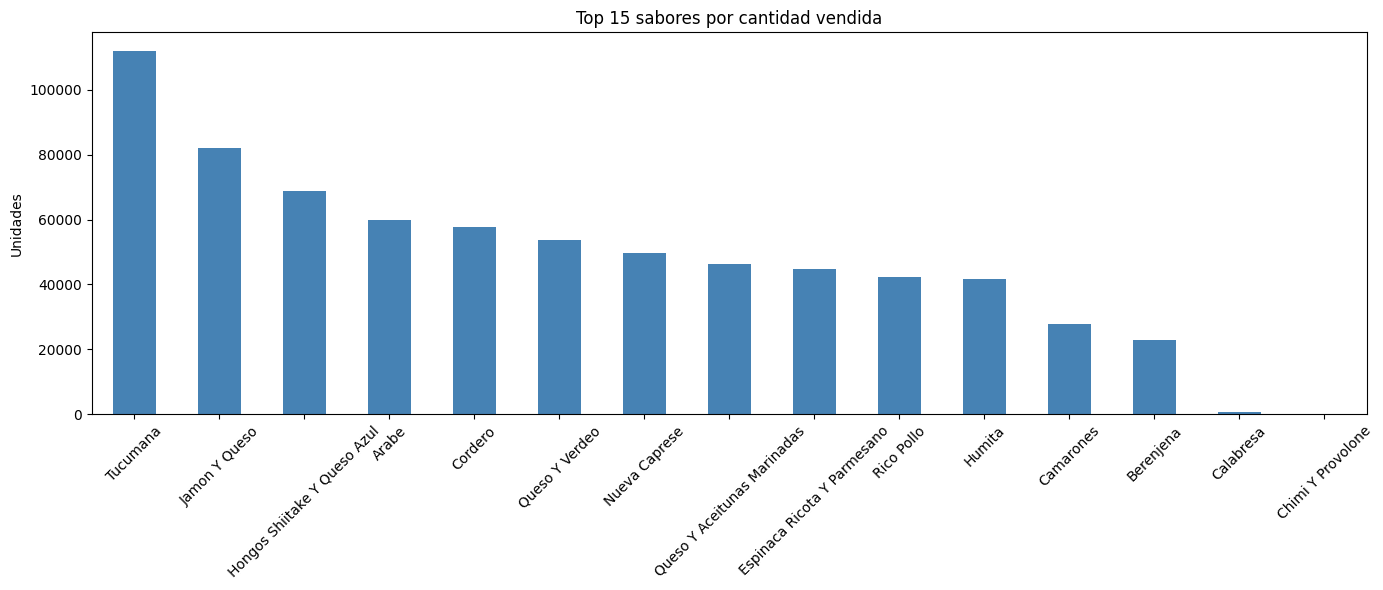

In [184]:
# Top sabores por cantidad total vendida
emp_cols = [c for c in pedidos_analisis.columns if c.startswith('emp_')]

sabores_total = pedidos_analisis[emp_cols].sum().sort_values(ascending=False)
sabores_total.index = sabores_total.index.str.replace('emp_', '').str.replace('_', ' ').str.title()

print("=== TOP 20 SABORES POR CANTIDAD ===")
print(sabores_total.head(20).round(0))

# Gráfico top 15
fig, ax = plt.subplots(figsize=(14, 6))
sabores_total.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 sabores por cantidad vendida')
ax.set_ylabel('Unidades')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### Observaciones - Análisis de Sabores

- **Tucumana** es el sabor más vendido con 112,103 unidades — un 36% más que Jamón y Queso en segundo lugar.
- El top 5 (*Tucumana, Jamón y Queso, Hongos Shiitake y Queso Azul, Árabe, Cordero*) concentra la mayor parte de la demanda.
- Los primeros *11* sabores tienen volúmenes similares entre sí (*40,000–82,000*), luego hay un quiebre importante con Camarones (*27,682*) y Berenjena (*22,894*).
- **Calabresa** (*630*) y **Chimi y Provolone** (*33*) son sabores marginales — discontinuados.
- El portafolio activo real es de *13 sabores* con volumen significativo.

#### Sabores por Sucursal

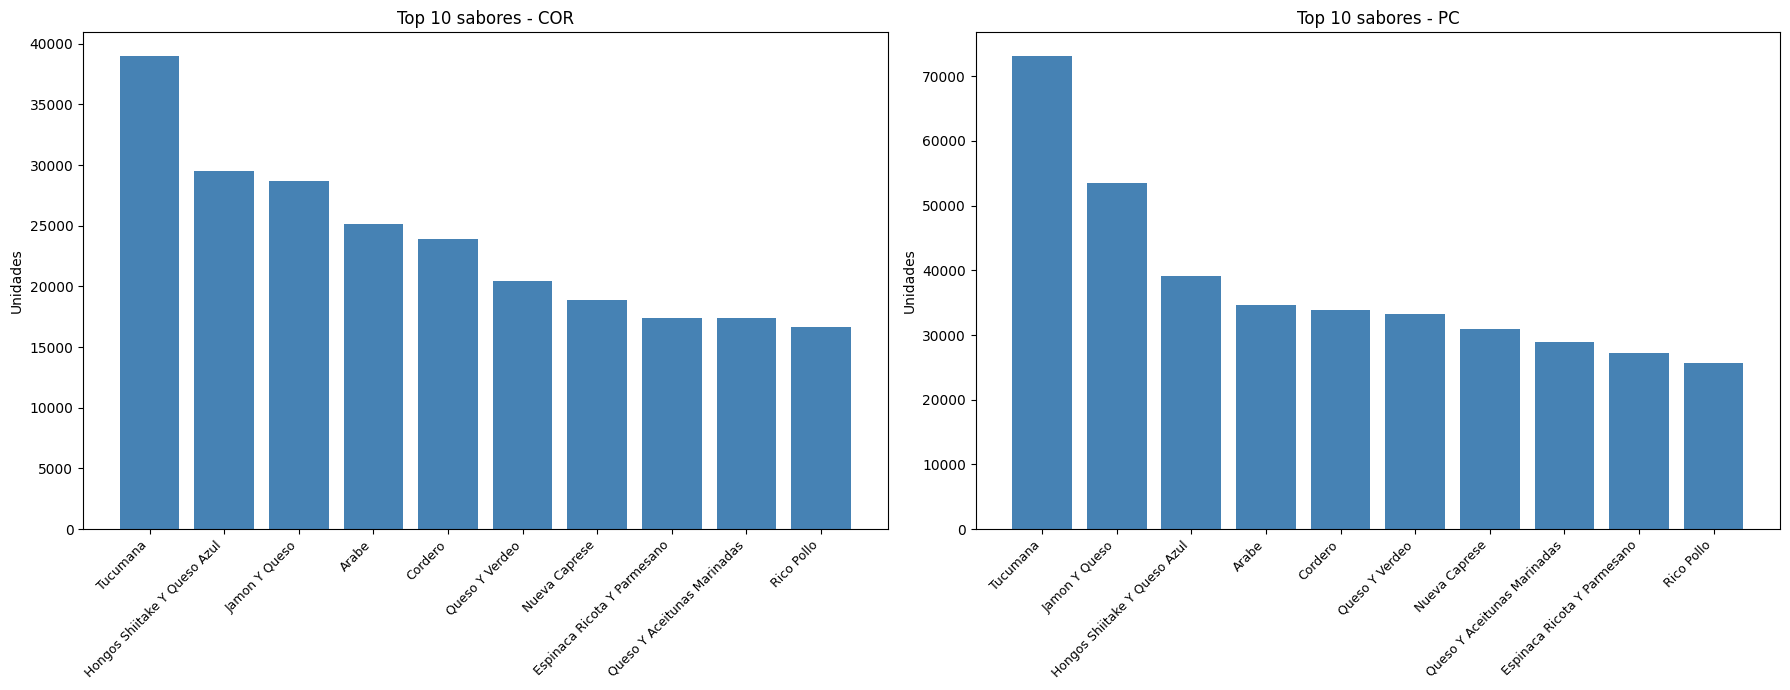

=== TOP 10 SABORES POR SUCURSAL ===
sucursal                          COR       PC  diferencia_%
Tucumana                      38982.0  73121.0          88.0
Jamon Y Queso                 28705.0  53431.0          86.0
Hongos Shiitake Y Queso Azul  29533.0  39148.0          33.0
Arabe                         25175.0  34696.0          38.0
Cordero                       23925.0  33928.0          42.0
Queso Y Verdeo                20420.0  33212.0          63.0
Nueva Caprese                 18868.0  30888.0          64.0
Queso Y Aceitunas Marinadas   17368.0  28905.0          66.0
Espinaca Ricota Y Parmesano   17375.0  27231.0          57.0
Rico Pollo                    16669.0  25749.0          54.0


In [185]:
# Sabores por sucursal
sabores_suc = pedidos_analisis.groupby('sucursal')[emp_cols].sum()
sabores_suc.columns = sabores_suc.columns.str.replace('emp_', '').str.replace('_', ' ').str.title()

# Top 10 por sucursal
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, suc in enumerate(['COR', 'PC']):
    top = sabores_suc.loc[suc].sort_values(ascending=False).head(10)
    axes[i].bar(range(len(top)), top.values, color='steelblue')
    axes[i].set_title(f'Top 10 sabores - {suc}')
    axes[i].set_xticks(range(len(top)))
    axes[i].set_xticklabels(top.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_ylabel('Unidades')

plt.tight_layout()
plt.show()

# Tabla comparativa top 10
print("=== TOP 10 SABORES POR SUCURSAL ===")
comp = sabores_suc.T
comp['diferencia_%'] = ((comp['PC'] - comp['COR']) / comp['COR'] * 100).round(1)
comp = comp.sort_values('PC', ascending=False).head(10)
print(comp.round(0))

#### Observaciones - Sabores por Sucursal

- El ranking de sabores es prácticamente idéntico en ambas sucursales — las preferencias de los clientes son consistentes independientemente de la ubicación.
- Tucumana lidera en ambas sucursales con amplia diferencia.
- Las variaciones entre sucursales son menores: en COR Hongos Shiitake supera a Jamón y Queso, y Queso y Aceitunas Marinadas supera a Espinaca Ricota y Parmesano; en PC es al revés en ambos casos.
- PC tiene mayor volumen en todos los sabores (*+33% a +88%*) — refleja la combinación de mayor volumen de pedidos y turno mediodía.
- La diferencia porcentual es mayor en Tucumana y Jamón y Queso (*~88%*) que en sabores más especiales como Hongos Shiitake (*33%*) — sugiere que los sabores clásicos son más populares en el mediodía de PC.

#### Estacionalidad de Sabores

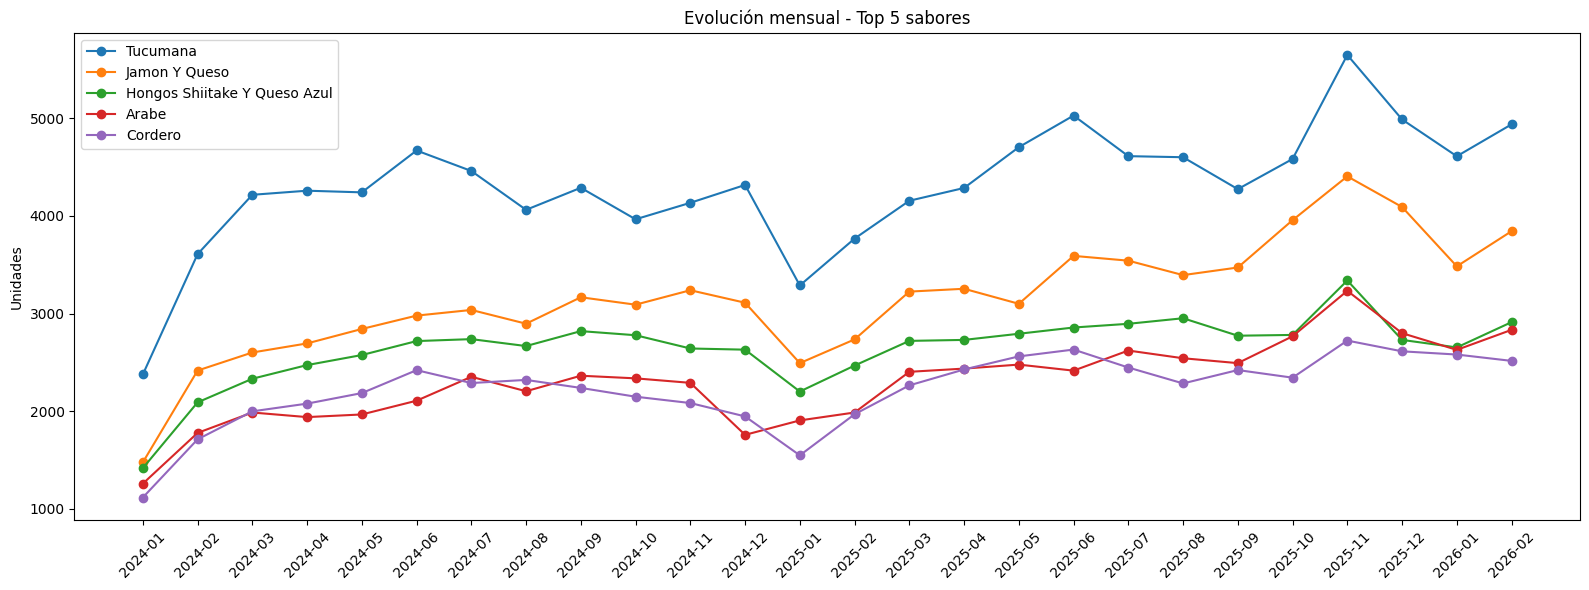

In [186]:
# Evolución mensual de los top 5 sabores
pedidos_analisis['anio_mes'] = pd.to_datetime(pedidos_analisis['fecha']).dt.to_period('M')

top5 = sabores_total.head(5).index.str.lower().str.replace(' ', '_')
top5_cols = ['emp_' + s for s in top5]

estacionalidad = pedidos_analisis.groupby('anio_mes')[top5_cols].sum().reset_index()
estacionalidad['anio_mes'] = estacionalidad['anio_mes'].astype(str)
estacionalidad.columns = ['anio_mes'] + [c.replace('emp_', '').replace('_', ' ').title() for c in top5_cols]

fig, ax = plt.subplots(figsize=(16, 6))
for col in estacionalidad.columns[1:]:
    ax.plot(estacionalidad['anio_mes'], estacionalidad[col], marker='o', label=col)

ax.set_title('Evolución mensual - Top 5 sabores')
ax.set_ylabel('Unidades')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

#### Observaciones - Estacionalidad de Sabores

- Todos los sabores muestran el mismo patrón estacional — caída en diciembre-enero (verano uruguayo) y picos en invierno (junio) y noviembre.
- El ranking relativo entre los top 5 sabores se mantiene estable durante todo el período — las preferencias no cambian con la estación.
- Tucumana amplía su ventaja en los meses pico — es el sabor más sensible a la estacionalidad.
- Noviembre 2025 es el mes pico para todos los sabores, consistente con el análisis temporal general.
- La caída de diciembre 2024 - enero 2025 es pronunciada (*~25-30%*) — importante para la planificación de producción.

### 7.9 Análisis de Descuentos

Pedidos con descuento: 47,809 (45.1%)
Pedidos sin descuento: 58,247 (54.9%)

=== DESCUENTO PROMEDIO POR CANAL ===
       pedidos  descuento_medio  descuento_mediana  ticket_medio
canal                                                           
H        11697           162.89             133.20        797.82
LOCAL    23782           148.88             119.06        784.77
PY       12330           153.59             132.79        729.03

=== TICKET CON VS SIN DESCUENTO ===
                   mean  median  count
tiene_descuento                       
0                826.55   720.0  58247
1                773.59   652.5  47809


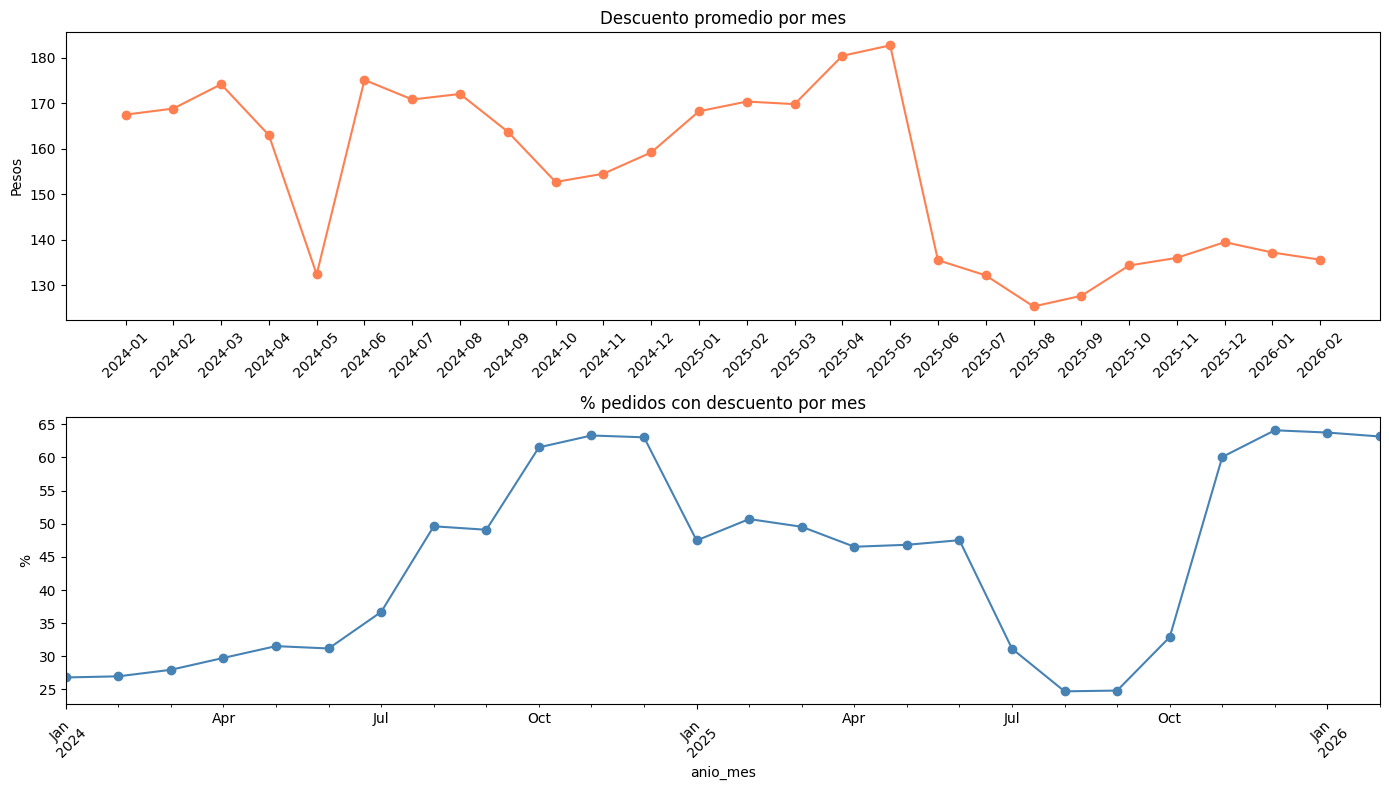

In [187]:
# % de pedidos con descuento
pedidos_analisis['tiene_descuento'] = (pedidos_analisis['descuentoimporte'] > 0).astype(int)

total = len(pedidos_analisis)
con_desc = pedidos_analisis['tiene_descuento'].sum()
print(f"Pedidos con descuento: {con_desc:,} ({con_desc/total*100:.1f}%)")
print(f"Pedidos sin descuento: {total-con_desc:,} ({(total-con_desc)/total*100:.1f}%)")

# Descuento promedio por canal
print("\n=== DESCUENTO PROMEDIO POR CANAL ===")
desc_canal = pedidos_analisis[pedidos_analisis['tiene_descuento'] == 1].groupby('canal').agg(
    pedidos          = ('pedido_id', 'count'),
    descuento_medio  = ('descuentoimporte', 'mean'),
    descuento_mediana= ('descuentoimporte', 'median'),
    ticket_medio     = ('total', 'mean'),
).round(2)
print(desc_canal)

# Impacto en ticket — con vs sin descuento
print("\n=== TICKET CON VS SIN DESCUENTO ===")
print(pedidos_analisis.groupby('tiene_descuento')['total'].agg(['mean', 'median', 'count']).round(2))

# Evolución mensual del descuento promedio
evol_desc = pedidos_analisis[pedidos_analisis['tiene_descuento'] == 1].groupby('anio_mes').agg(
    descuento_medio = ('descuentoimporte', 'mean'),
    pct_con_descuento = ('tiene_descuento', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(evol_desc['anio_mes'].astype(str), evol_desc['descuento_medio'], marker='o', color='coral')
axes[0].set_title('Descuento promedio por mes')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Pesos')

pedidos_analisis.groupby('anio_mes')['tiene_descuento'].mean().mul(100).plot(
    ax=axes[1], marker='o', color='steelblue')
axes[1].set_title('% pedidos con descuento por mes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

#### Observaciones - Análisis de Descuentos

- El *45%* de los pedidos tiene algún descuento — es un porcentaje alto que indica una política activa de promociones.
- El descuento promedio es similar entre canales (*149–163 pesos*) — H tiene el descuento más alto en valor absoluto.
- Los pedidos con descuento tienen ticket menor (*774 vs 827*) — el descuento no compensa el menor volumen del pedido.
- El % de pedidos con descuento muestra dos regímenes claros: *~27-30%* en el primer semestre 2024, sube a *~63%* entre octubre 2024 y enero 2025, cae nuevamente en julio-septiembre 2025 a *~25%*, y vuelve a subir a *~63%* desde octubre 2025.
- Este patrón sugiere cambios en la política comercial o integración con plataformas de descuentos — a confirmar con el negocio.
- El descuento promedio en pesos cae a partir de junio 2025 (*~130 vs ~170*) — los descuentos son más frecuentes pero más chicos.

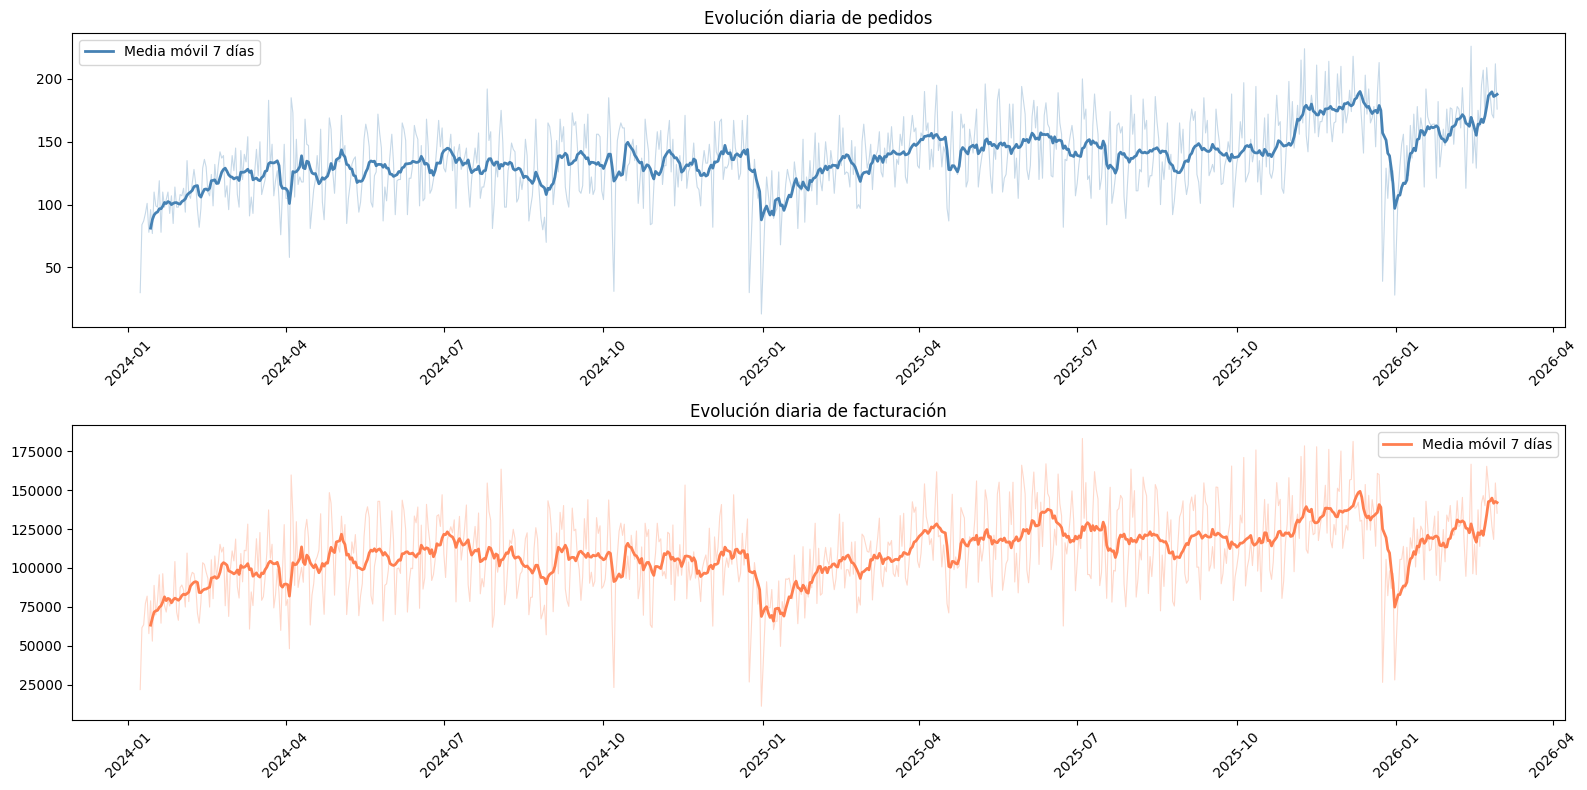

In [188]:
# Evolución diaria de ventas con media móvil
ventas_diarias = pedidos_analisis.groupby('fecha_dia').agg(
    pedidos     = ('pedido_id', 'count'),
    facturacion = ('total', 'sum')
).reset_index()

ventas_diarias['fecha_dia'] = pd.to_datetime(ventas_diarias['fecha_dia'])
ventas_diarias = ventas_diarias.sort_values('fecha_dia')
ventas_diarias['mm_pedidos']     = ventas_diarias['pedidos'].rolling(7).mean()
ventas_diarias['mm_facturacion'] = ventas_diarias['facturacion'].rolling(7).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(ventas_diarias['fecha_dia'], ventas_diarias['pedidos'],
             alpha=0.3, color='steelblue', linewidth=0.8)
axes[0].plot(ventas_diarias['fecha_dia'], ventas_diarias['mm_pedidos'],
             color='steelblue', linewidth=2, label='Media móvil 7 días')
axes[0].set_title('Evolución diaria de pedidos')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(ventas_diarias['fecha_dia'], ventas_diarias['facturacion'],
             alpha=0.3, color='coral', linewidth=0.8)
axes[1].plot(ventas_diarias['fecha_dia'], ventas_diarias['mm_facturacion'],
             color='coral', linewidth=2, label='Media móvil 7 días')
axes[1].set_title('Evolución diaria de facturación')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Observaciones - Evolución Diaria de Ventas

- Tendencia creciente sostenida durante todo el período — el negocio creció aproximadamente un *50%* en volumen de pedidos entre enero 2024 y febrero 2026.
- Patrón estacional claro: caída en diciembre-enero (*verano uruguayo*) y recuperación en otoño-invierno.
- Los valles más pronunciados corresponden a días puntuales — probablemente feriados o cierres excepcionales.
- La variabilidad diaria es alta pero la media móvil de 7 días muestra la tendencia subyacente con claridad.
- La facturación crece en línea con los pedidos — el ticket promedio se mantiene estable en el tiempo.

### 7.10 Análisis Geográfico de Delivery

In [189]:
dirs = pedidos_analisis[pedidos_analisis['cliente_direccion'].notna()]['cliente_direccion']

print(f"Total con dirección: {len(dirs):,}")
print(f"Direcciones únicas:  {dirs.nunique():,}")
print(f"\nMuestra de 20 direcciones:")
print(dirs.sample(20, random_state=42).tolist())

Total con dirección: 36,133
Direcciones únicas:  11,291

Muestra de 20 direcciones:
['Doctor Emilio Frugoni 1319, Apt: Casa , (Fiorella 098493502 )', 'Hugo de los Santos Recarte 1290 Depto. 102', 'San Salvador 2114 Depto. 001 esquina Salterain', '21 de setiembre 2570 Depto. 1001 esquina Sarmiento', 'José María montero 2869 Depto. Casa esquina Ellauri', 'Reconquista 334 Depto. 301', 'Rambla Armenia 1616 Apto:Administracion', 'Joaquín de Salterain 1519 Apto:205', 'Juan Paullier 1280, Apt: 003, (Avisar al celular,  no funciona el tim', ' Apto:', 'Sinergia Faro Depto. 16 Deloitte', 'Rambla Gandhi 229 Depto. 502', 'Retiro en el local', 'Julio César 1365 1365 Apto:103', 'Marco Bruto 1380 Depto. Apto 10', 'Coronel Mora 540 Apto: 2 Esq. gregorio suarez', '26 de Marzo 1281, Apt: 602', 'Gastón Ramón 2360 esquina 20 de septiembre', 'Presidente General Oscar Gestido 2752', 'Calle Coronel Brandzen 2120 Apto: 404B edificio Ventura Esq. Entre re']


#### Limpieza de Direcciones

In [190]:
import re

def limpiar_direccion(dir_raw):
    if pd.isna(dir_raw):
        return np.nan

    d = str(dir_raw).strip()

    # Eliminar texto entre paréntesis
    d = re.sub(r'\(.*?\)', '', d)

    # Eliminar apartamento/depto y lo que sigue
    d = re.sub(r'(?i)\b(depto\.?|apto\.?|apt\.?|apartamento|piso)\s*[:\.]?\s*.*', '', d)

    # Eliminar "esquina X" — quedarnos solo con calle y número
    d = re.sub(r'(?i)\s*esq(uina)?\s+.*', '', d)

    # Eliminar números duplicados (ej: "Julio César 1365 1365")
    d = re.sub(r'\b(\d+)\s+\1\b', r'\1', d)

    # Limpiar espacios y comas sobrantes
    d = re.sub(r'[,\s]+$', '', d.strip())

    # Filtrar direcciones inválidas
    invalidas = ['retiro', 'local', 'apto', 'apt', 'sin direccion', 'sin dirección', '']
    if any(d.lower().strip() == inv for inv in invalidas) or len(d) < 5:
        return np.nan

    return d.strip() + ', Montevideo, Uruguay'

# Aplicar limpieza
pedidos_analisis['direccion_limpia'] = pedidos_analisis['cliente_direccion'].apply(limpiar_direccion)

total_dirs = pedidos_analisis['cliente_direccion'].notna().sum()
dirs_limpias = pedidos_analisis['direccion_limpia'].notna().sum()

print(f"Direcciones originales: {total_dirs:,}")
print(f"Direcciones válidas:    {dirs_limpias:,}")
print(f"Descartadas:            {total_dirs - dirs_limpias:,}")

print("\nMuestra de direcciones limpias:")
muestra = pedidos_analisis[pedidos_analisis['direccion_limpia'].notna()]['direccion_limpia'].sample(10, random_state=42)
for d in muestra:
    print(f"  {d}")

Direcciones originales: 36,133
Direcciones válidas:    33,592
Descartadas:            2,541

Muestra de direcciones limpias:
  Rafael Pastoriza 1481, Montevideo, Uruguay
  Ramos 4212, Montevideo, Uruguay
  Jaime Zudañez 2514, Montevideo, Uruguay
  Avenue Julio Herrera y Reissig 780, Montevideo, Uruguay
  Maldonado 1788, Montevideo, Uruguay
  Magallanes 1260, Montevideo, Uruguay
  Jose Maria Roo 1275, Montevideo, Uruguay
  Avenida Ingeniero Luis Ponce 1435, Montevideo, Uruguay
  Bv. Gral. Artigas 1671, Montevideo, Uruguay
  Scoseria 2910, Montevideo, Uruguay


#### Geocodificación de Direcciones

In [191]:
import os

checkpoint_path = RUTA + 'geo_checkpoint.csv'

# Retomar desde checkpoint si existe
if os.path.exists(checkpoint_path):
    geo_checkpoint = pd.read_csv(checkpoint_path)
    dirs_procesadas = set(geo_checkpoint['direccion_limpia'].tolist())
    resultados = geo_checkpoint.to_dict('records')
    print(f"Retomando desde checkpoint: {len(resultados):,} ya procesadas")
else:
    resultados = []
    dirs_procesadas = set()

dirs_unicas = pedidos_analisis[pedidos_analisis['direccion_limpia'].notna()]['direccion_limpia'].unique()
dirs_pendientes = [d for d in dirs_unicas if d not in dirs_procesadas]
print(f"Pendientes: {len(dirs_pendientes):,}")

geolocator = Nominatim(user_agent="lacampeona_empanadas", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

for i, dir_ in enumerate(dirs_pendientes):
    try:
        location = geocode(dir_)
        resultados.append({
            'direccion_limpia': dir_,
            'lat': location.latitude if location else np.nan,
            'lon': location.longitude if location else np.nan
        })
    except Exception:
        resultados.append({
            'direccion_limpia': dir_,
            'lat': np.nan,
            'lon': np.nan
        })

    # Guardar checkpoint cada 100
    if i % 100 == 0:
        pd.DataFrame(resultados).to_csv(checkpoint_path, index=False)
        print(f"  Checkpoint guardado: {len(resultados):,} / {len(dirs_unicas):,}")

# Guardar final
geo_df = pd.DataFrame(resultados)
geo_df = geo_df[
    (geo_df['lat'].between(-34.95, -34.75)) &
    (geo_df['lon'].between(-56.35, -56.05))
]
geo_df.to_csv(RUTA + 'geocodificadas.csv', index=False)
print(f"\nFinalizado. Geocodificadas exitosamente: {len(geo_df):,}")

Retomando desde checkpoint: 7,405 ya procesadas
Pendientes: 50
  Checkpoint guardado: 7,406 / 7,455

Finalizado. Geocodificadas exitosamente: 5,741


#### Mapa de Delivery

In [192]:
# Recargar geocodificadas y recrear pedidos_geo
geo_df = pd.read_csv(RUTA + 'geocodificadas.csv')

pedidos_geo = pedidos_analisis.merge(geo_df, on='direccion_limpia', how='inner')
print(f"Pedidos con coordenadas: {len(pedidos_geo):,}")

Pedidos con coordenadas: 27,589


In [193]:
from geopy.distance import geodesic

# Coordenadas correctas de los locales
coord_cor = (-34.9041, -56.1820)  # Constituyente 1892, Cordón
coord_pc  = (-34.9186, -56.1589)  # Guipúzcoa 420, Punta Carretas

pedidos_geo['dist_cor'] = pedidos_geo.apply(
    lambda r: geodesic((r['lat'], r['lon']), coord_cor).km, axis=1)
pedidos_geo['dist_pc'] = pedidos_geo.apply(
    lambda r: geodesic((r['lat'], r['lon']), coord_pc).km, axis=1)
pedidos_geo['dist_min_km'] = pedidos_geo[['dist_cor', 'dist_pc']].min(axis=1)

print("Pedidos a más de 5km:", (pedidos_geo['dist_min_km'] > 5).sum())
print("Pedidos a más de 8km:", (pedidos_geo['dist_min_km'] > 8).sum())
print("Pedidos a más de 10km:", (pedidos_geo['dist_min_km'] > 10).sum())

Pedidos a más de 5km: 90
Pedidos a más de 8km: 57
Pedidos a más de 10km: 52


In [194]:
lejos = pedidos_geo[pedidos_geo['dist_min_km'] > 8][['direccion_limpia', 'lat', 'lon', 'dist_min_km']].drop_duplicates('direccion_limpia').sort_values('dist_min_km', ascending=False)
print(lejos.to_string())

                                          direccion_limpia        lat        lon  dist_min_km
1843             Javier de Viana 1004, Montevideo, Uruguay -34.760148 -56.218604    16.316883
11695      Jose Batlle y Ordóñez 1511, Montevideo, Uruguay -34.762799 -56.221269    16.081864
16124  jose batlle y ordonez  1316 De, Montevideo, Uruguay -34.762810 -56.221128    16.077851
15481                      Carace 520, Montevideo, Uruguay -34.768282 -56.225655    15.587517
18809                  AV LEZICA 6692, Montevideo, Uruguay -34.787603 -56.259173    14.725633
3866                  Tacuarembó 1443, Montevideo, Uruguay -34.776324 -56.139000    14.710630
27025                  Br Artigas 120, Montevideo, Uruguay -34.791792 -56.228034    13.151368
16530              Vehicular Peatonal, Montevideo, Uruguay -34.807732 -56.111353    12.491367
6563              Avenida Italia 2850, Montevideo, Uruguay -34.876400 -56.050378    10.968379
7841                  Av. Italia 2850, Montevideo, Uruguay -

#### Filtro de Radio de Cobertura

Al revisar las direcciones geocodificadas a más de 8km de los locales se identificaron
errores de geocodificación — calles de Montevideo confundidas con homónimas (ej: Salterain, 21 de Setiembre, Bulevar Artigas).

Se aplica un filtro de *10km* desde el local más cercano, eliminando 57 pedidos que
representan errores de geocodificación. Las direcciones válidas más alejadas corresponden
a Av. Italia en Carrasco, zona que sí está dentro del área de cobertura real del negocio.

In [195]:
# Filtrar por radio de 10km
pedidos_geo_filtrado = pedidos_geo[pedidos_geo['dist_min_km'] <= 10].copy()
print(f"Pedidos antes del filtro: {len(pedidos_geo):,}")
print(f"Pedidos después del filtro: {len(pedidos_geo_filtrado):,}")
print(f"Descartados: {len(pedidos_geo) - len(pedidos_geo_filtrado):,}")

# Agrupar por coordenada y sucursal
mapa_data = pedidos_geo_filtrado.groupby(['lat', 'lon', 'sucursal']).agg(
    pedidos = ('pedido_id', 'count')
).reset_index()

Pedidos antes del filtro: 27,589
Pedidos después del filtro: 27,537
Descartados: 52


In [196]:
from folium.plugins import HeatMap

# ── 1. Heatmap por sucursal ───────────────────────────────────────────────
m_heat = folium.Map(location=[-34.9141, -56.1700], zoom_start=13)

heat_cor = pedidos_geo_filtrado[pedidos_geo_filtrado['sucursal'] == 'COR'][['lat', 'lon']].values.tolist()
heat_pc  = pedidos_geo_filtrado[pedidos_geo_filtrado['sucursal'] == 'PC'][['lat', 'lon']].values.tolist()

HeatMap(heat_cor, name='COR - Cordón', gradient={'0.4': 'blue', '0.7': 'cyan', '1': 'white'}).add_to(m_heat)
HeatMap(heat_pc,  name='PC - Punta Carretas', gradient={'0.4': 'red', '0.7': 'orange', '1': 'yellow'}).add_to(m_heat)

folium.Marker(coord_cor, popup='COR', icon=folium.Icon(color='blue', icon='star')).add_to(m_heat)
folium.Marker(coord_pc,  popup='PC',  icon=folium.Icon(color='red',  icon='star')).add_to(m_heat)

folium.LayerControl().add_to(m_heat)
m_heat.save('/content/mapa_heatmap.html')

# ── 2. Barrios con más pedidos ────────────────────────────────────────────
# Usar reverse geocoding aproximado por zona — agrupar por cuadrícula de 0.01 grados (~1km)
pedidos_geo_filtrado['zona_lat'] = (pedidos_geo_filtrado['lat'] / 0.01).round() * 0.01
pedidos_geo_filtrado['zona_lon'] = (pedidos_geo_filtrado['lon'] / 0.01).round() * 0.01

zonas = pedidos_geo_filtrado.groupby(['zona_lat', 'zona_lon']).agg(
    pedidos        = ('pedido_id', 'count'),
    ticket_promedio = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reset_index().sort_values('pedidos', ascending=False)

print("=== TOP 15 ZONAS POR PEDIDOS ===")
print(zonas.head(15).round(2).to_string())

# ── 3. Mapa de ticket promedio por zona ───────────────────────────────────
m_ticket = folium.Map(location=[-34.9141, -56.1700], zoom_start=13)

for _, row in zonas.iterrows():
    # Color según ticket — verde bajo, amarillo medio, rojo alto
    ticket = row['ticket_promedio']
    if ticket < 600:
        color = 'green'
    elif ticket < 900:
        color = 'orange'
    else:
        color = 'red'

    folium.CircleMarker(
        location=[row['zona_lat'], row['zona_lon']],
        radius=min(row['pedidos'] / 10, 20),
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=f"Pedidos: {row['pedidos']} | Ticket: ${row['ticket_promedio']:.0f} | Emp: {row['empanadas_promedio']:.1f}"
    ).add_to(m_ticket)

folium.Marker(coord_cor, popup='COR', icon=folium.Icon(color='blue', icon='star')).add_to(m_ticket)
folium.Marker(coord_pc,  popup='PC',  icon=folium.Icon(color='red',  icon='star')).add_to(m_ticket)

m_ticket.save('/content/mapa_ticket.html')
print("\nMapas guardados.")
m_heat

=== TOP 15 ZONAS POR PEDIDOS ===
    zona_lat  zona_lon  pedidos  ticket_promedio  empanadas_promedio
9     -34.91    -56.16     3359           832.76                6.78
2     -34.92    -56.16     2989           908.78                7.48
10    -34.91    -56.15     2968           855.48                6.98
8     -34.91    -56.17     2684           830.14                6.76
7     -34.91    -56.18     2508           806.39                6.55
3     -34.92    -56.15     2375           890.14                7.22
17    -34.90    -56.17     1869           824.02                6.76
11    -34.91    -56.14     1279           867.96                7.06
6     -34.91    -56.19     1235           753.17                6.08
16    -34.90    -56.18      728           695.38                5.69
18    -34.90    -56.16      714           914.89                7.65
5     -34.91    -56.20      664           872.72                6.92
20    -34.90    -56.14      575           809.14                6.32
1

In [197]:
# Ver todas las direcciones geocodificadas al oeste del puerto (lon < -56.25)
# que es donde está el Cerro
sospechosas = pedidos_geo_filtrado[pedidos_geo_filtrado['lon'] < -56.25][
    ['direccion_limpia', 'lat', 'lon', 'dist_min_km']
].drop_duplicates('direccion_limpia').sort_values('lon')

print(f"Direcciones sospechosas (zona Cerro/oeste): {len(sospechosas)}")
print(sospechosas.to_string())

Direcciones sospechosas (zona Cerro/oeste): 5
                                direccion_limpia       lat        lon  dist_min_km
12163  Claudio Williman 573, Montevideo, Uruguay -34.88076 -56.254176     7.087376
14682  Claudio Williman 575, Montevideo, Uruguay -34.88076 -56.254176     7.087376
16229  Claudio Williman 599, Montevideo, Uruguay -34.88076 -56.254176     7.087376
18627  Claudio Williman 533, Montevideo, Uruguay -34.88076 -56.254176     7.087376
24097  Claudio Williman 565, Montevideo, Uruguay -34.88076 -56.254176     7.087376


In [198]:
# Norte (lat > -34.85) y Este (lon > -56.10)
norte = pedidos_geo_filtrado[pedidos_geo_filtrado['lat'] > -34.85][
    ['direccion_limpia', 'lat', 'lon', 'dist_min_km']
].drop_duplicates('direccion_limpia').sort_values('lat', ascending=False)

este = pedidos_geo_filtrado[pedidos_geo_filtrado['lon'] > -56.10][
    ['direccion_limpia', 'lat', 'lon', 'dist_min_km']
].drop_duplicates('direccion_limpia').sort_values('lon', ascending=False)

print(f"Direcciones sospechosas al norte (lat > -34.85): {len(norte)}")
print(norte.to_string())

print(f"\nDirecciones sospechosas al este (lon > -56.10): {len(este)}")
print(este.to_string())

Direcciones sospechosas al norte (lat > -34.85): 2
                             direccion_limpia        lat        lon  dist_min_km
20242  21 setiembre 3137, Montevideo, Uruguay -34.833234 -56.239853     9.475645
8039     San Martín 2553, Montevideo, Uruguay -34.841809 -56.169148     7.009682

Direcciones sospechosas al este (lon > -56.10): 6
                                 direccion_limpia        lat        lon  dist_min_km
8562         Av. Italia 2584, Montevideo, Uruguay -34.880802 -56.077679     8.525994
10448         Av Italia 1890, Montevideo, Uruguay -34.880802 -56.077679     8.525994
11174      Av Italia s/n 000, Montevideo, Uruguay -34.880802 -56.077679     8.525994
11751        Av. Italia 1826, Montevideo, Uruguay -34.880802 -56.077679     8.525994
25199  MAR MEDITERRANEO 5858, Montevideo, Uruguay -34.896897 -56.080740     7.537959
11349         Mangaripé 1485, Montevideo, Uruguay -34.891562 -56.084580     7.425212


In [199]:
dirs_revisar = [
    'Claudio Williman 573, Montevideo, Uruguay',
    'Claudio Williman 575, Montevideo, Uruguay',
    'Claudio Williman 599, Montevideo, Uruguay',
    'Claudio Williman 533, Montevideo, Uruguay',
    'Claudio Williman 565, Montevideo, Uruguay',
    '21 setiembre 3137, Montevideo, Uruguay',
    'San Martín 2553, Montevideo, Uruguay'
]

print("=== PEDIDOS POR DIRECCIÓN SOSPECHOSA ===")
for dir_ in dirs_revisar:
    n = pedidos_geo_filtrado[pedidos_geo_filtrado['direccion_limpia'] == dir_].shape[0]
    print(f"  {n:>4} pedidos — {dir_}")

=== PEDIDOS POR DIRECCIÓN SOSPECHOSA ===
     1 pedidos — Claudio Williman 573, Montevideo, Uruguay
     2 pedidos — Claudio Williman 575, Montevideo, Uruguay
     1 pedidos — Claudio Williman 599, Montevideo, Uruguay
     2 pedidos — Claudio Williman 533, Montevideo, Uruguay
     1 pedidos — Claudio Williman 565, Montevideo, Uruguay
     1 pedidos — 21 setiembre 3137, Montevideo, Uruguay
     1 pedidos — San Martín 2553, Montevideo, Uruguay


#### Corrección de Geocodificaciones Incorrectas

Se identificaron 7 direcciones mal geocodificadas — calles de Montevideo confundidas
con homónimas en otras zonas. Al ser solo 9 pedidos en total se opta por excluirlas
del análisis geográfico.

In [200]:
dirs_excluir = [
    'Claudio Williman 573, Montevideo, Uruguay',
    'Claudio Williman 575, Montevideo, Uruguay',
    'Claudio Williman 599, Montevideo, Uruguay',
    'Claudio Williman 533, Montevideo, Uruguay',
    'Claudio Williman 565, Montevideo, Uruguay',
    '21 setiembre 3137, Montevideo, Uruguay',
    'San Martín 2553, Montevideo, Uruguay'
]

pedidos_geo_filtrado = pedidos_geo_filtrado[
    ~pedidos_geo_filtrado['direccion_limpia'].isin(dirs_excluir)
].copy()

print(f"Pedidos en el mapa final: {len(pedidos_geo_filtrado):,}")

Pedidos en el mapa final: 27,528


In [201]:
print(f"Direcciones válidas después de limpieza:  {pedidos_analisis['direccion_limpia'].notna().sum():,}")
print(f"Pedidos con coordenadas (join con geo_df): {len(pedidos_geo):,}")
print(f"Pedidos dentro de 10km:                   {len(pedidos_geo[pedidos_geo['dist_min_km'] <= 10]):,}")
print(f"Pedidos tras excluir mal geocodificadas:   {len(pedidos_geo_filtrado):,}")
print(f"\nPérdida total: {pedidos_analisis['direccion_limpia'].notna().sum() - len(pedidos_geo_filtrado):,}")

Direcciones válidas después de limpieza:  33,592
Pedidos con coordenadas (join con geo_df): 27,589
Pedidos dentro de 10km:                   27,537
Pedidos tras excluir mal geocodificadas:   27,528

Pérdida total: 6,064


#### Resumen del proceso de geocodificación

- *33,592* pedidos con dirección válida tras limpieza de texto.
- *27,589* pedidos geocodificados exitosamente (*82%*) — el *18%* restante no fue encontrado por Nominatim debido a variaciones en el texto de las direcciones.
- *52* pedidos excluidos por estar fuera del radio de *10km* — errores de geocodificación.
- *9* pedidos excluidos por direcciones mal geocodificadas identificadas manualmente.
- **Total en el mapa: *27,528* pedidos.**

In [202]:
import requests
import geopandas as gpd

url_barrios = 'https://raw.githubusercontent.com/vierja/geojson_montevideo/master/barrios.geojson'
r = requests.get(url_barrios)
r.encoding = 'latin-1'

with open('/content/barrios.geojson', 'w', encoding='utf-8') as f:
    f.write(r.text)

barrios = gpd.read_file('/content/barrios.geojson')
print(f"Barrios cargados: {len(barrios)}")
print(barrios[['id_barrio', 'nombre']].head(10))

Barrios cargados: 63
   id_barrio                     nombre
0         32         MANGA TOLEDO CHICO
1         58      COLON SURESTE ABAYUBA
2         61   VILLA GARCIA MANGA RURAL
3         16        BAÑADOS DE CARRASCO
4         62                      MANGA
5         34          PENAROL LAVALLEJA
6         20  PUNTA RIELES BELLA ITALIA
7         30                  CASAVALLE
8         31            PIEDRAS BLANCAS
9         52                     SAYAGO


In [203]:
from shapely.geometry import Point

# Convertir pedidos a GeoDataFrame
gdf_pedidos = gpd.GeoDataFrame(
    pedidos_geo_filtrado,
    geometry=gpd.points_from_xy(pedidos_geo_filtrado['lon'], pedidos_geo_filtrado['lat']),
    crs='EPSG:4326'
)

barrios = barrios.set_crs('EPSG:4326', allow_override=True)

# Join espacial
pedidos_barrio = gpd.sjoin(gdf_pedidos, barrios[['nombre', 'geometry']], how='left', predicate='within')

# Estadísticas por barrio
stats_barrio = pedidos_barrio.groupby('nombre').agg(
    pedidos         = ('pedido_id', 'count'),
    ticket_promedio = ('total', 'mean'),
    empanadas_promedio = ('cant_total_empanadas', 'mean')
).reset_index().sort_values('pedidos', ascending=False)

print("=== TOP 15 BARRIOS POR PEDIDOS ===")
print(stats_barrio.head(15).round(2).to_string())

=== TOP 15 BARRIOS POR PEDIDOS ===
                       nombre  pedidos  ticket_promedio  empanadas_promedio
21                    POCITOS     8395           845.48                6.89
24             PUNTA CARRETAS     4793           910.38                7.44
9                      CORDON     3943           791.47                6.43
20                PARQUE RODO     2536           832.39                6.82
19                    PALERMO     1792           814.16                6.65
2                  BARRIO SUR     1212           765.42                6.19
7                      CENTRO      903           838.24                6.79
22  PQUE BATLLE VILLA DOLORES      895           951.91                7.52
4                       BUCEO      813           938.96                7.25
27                TRES CRUCES      799           889.26                7.25
8                CIUDAD VIEJA      728           861.19                6.44
0                      AGUADA      108           762.

### Análisis por Barrio

In [204]:
import geopandas as gpd
import folium
import branca.colormap as cm

barrios['centroid'] = barrios.geometry.centroid
barrios['lat_c'] = barrios['centroid'].y
barrios['lon_c'] = barrios['centroid'].x

barrios_plot = barrios.merge(stats_barrio, on='nombre', how='left')
barrios_plot['pedidos'] = barrios_plot['pedidos'].fillna(0)
barrios_plot['ticket_promedio'] = barrios_plot['ticket_promedio'].fillna(0)

con_pedidos = barrios_plot[barrios_plot['pedidos'] > 0]
colormap = cm.LinearColormap(
    colors=['#ffffb2', '#fecc5c', '#fd8d3c', '#f03b20', '#bd0026'],
    vmin=con_pedidos['ticket_promedio'].min(),
    vmax=con_pedidos['ticket_promedio'].max(),
    caption='Ticket promedio (pesos)'
)

m = folium.Map(location=[-34.9141, -56.1700], zoom_start=13)

folium.GeoJson(
    barrios_plot[['nombre', 'geometry', 'pedidos', 'ticket_promedio']].to_json(),
    style_function=lambda feature: {
        'fillColor': colormap(feature['properties']['ticket_promedio'])
                     if feature['properties']['pedidos'] > 0 else '#e0e0e0',
        'color': '#555555',
        'weight': 0.8,
        'fillOpacity': 0.55,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['nombre', 'pedidos', 'ticket_promedio'],
        aliases=['Barrio', 'Pedidos', 'Ticket promedio'],
        localize=True
    )
).add_to(m)

# Burbujas con número adentro usando DivIcon
for _, row in barrios_plot[barrios_plot['pedidos'] > 0].iterrows():
    radio = max(row['pedidos'] ** 0.45, 3)
    size = int(radio * 2) + 6  # diámetro del div
    font_size = max(int(radio * 0.55), 7)
    color = colormap(row['ticket_promedio'])

    folium.Marker(
        location=[row['lat_c'], row['lon_c']],
        icon=folium.DivIcon(
            html=f"""
                <div style="
                    width:{size}px; height:{size}px;
                    border-radius:50%;
                    background:{color};
                    border:1.5px solid white;
                    display:flex; align-items:center; justify-content:center;
                    font-size:{font_size}px; font-weight:bold;
                    color:white; text-shadow:0 0 3px #333;
                    white-space:nowrap;
                ">{int(row['pedidos']):,}</div>
            """,
            icon_size=(size, size),
            icon_anchor=(size // 2, size // 2)
        ),
        popup=folium.Popup(
            f"<b>{row['nombre']}</b><br>"
            f"Pedidos: {int(row['pedidos']):,}<br>"
            f"Ticket prom: ${row['ticket_promedio']:,.0f}<br>"
            f"Empanadas/pedido: {row['empanadas_promedio']:.1f}",
            max_width=200
        )
    ).add_to(m)

folium.Marker(coord_cor, popup='COR - Cordón',
              icon=folium.Icon(color='blue', icon='star')).add_to(m)
folium.Marker(coord_pc, popup='PC - Punta Carretas',
              icon=folium.Icon(color='red', icon='star')).add_to(m)

colormap.add_to(m)
m.save('/content/mapa_barrios.html')
print("Mapa guardado.")
m

Mapa guardado.


### Observaciones - Análisis Geográfico de Delivery

- **Pocitos** es el barrio con mayor volumen de pedidos (8,397) — casi el doble que Punta Carretas (4,791) en segundo lugar. Ambos son barrios de alto poder adquisitivo adyacentes a la sucursal PC.
- **Cordón** ocupa el tercer lugar (3,943) — el barrio sede de la sucursal COR, con el ticket más bajo del top 5 (791), consistente con un perfil de cliente más local y pedidos más chicos.
- **Parque Rodó** (2,536) y **Palermo** (1,792) completan el top 5 — barrios contiguos a ambas sucursales, con tickets intermedios (~814–832).
- Los barrios con **ticket más alto** son La Blanqueada (965), Parque Batlle/Villa Dolores (952) y Villa Muñoz/Retiro (951) — barrios con mayor distancia a los locales, lo que sugiere que los clientes más alejados tienden a hacer pedidos más grandes para justificar el delivery.

### Resumen del Análisis Geográfico

El análisis geográfico cubre **27,528 pedidos de delivery** (82% de cobertura de geocodificación)
distribuidos en 63 barrios de Montevideo.

| Indicador | Valor |
|-----------|-------|
| Barrio con más pedidos | Pocitos (8,397) |
| Barrio con ticket más alto | La Blanqueada ($965) |
| Barrios con presencia significativa | 15 |
| Radio de cobertura efectivo | ~10 km desde cada sucursal |

La demanda se concentra en una franja central de Montevideo — desde Ciudad Vieja hasta Carrasco
en el eje este-oeste — coincidiendo con los barrios de mayor densidad poblacional y poder
adquisitivo de la ciudad.

## 9. Segmentación de Clientes

El análisis geográfico mostró que los pedidos se concentran en una franja central de Montevideo, con Pocitos, Punta Carretas y Cordón como barrios dominantes. Ahora profundizamos en el comportamiento de los clientes que generan esa demanda.

Usamos `direccion_limpia` como proxy de cliente: asumimos que una dirección única corresponde a un cliente recurrente. Para que los perfiles sean estables y representativos, filtramos por frecuencia mínima de pedidos antes de segmentar.

El objetivo es identificar grupos de clientes con comportamientos similares — no como ejercicio técnico, sino para responder preguntas concretas: ¿quiénes son los clientes más valiosos? ¿qué piden? ¿con qué frecuencia? ¿desde dónde?

In [205]:
freq_dir = pedidos_analisis.groupby('direccion_limpia').size()
print(freq_dir.describe())
print()
print(freq_dir.value_counts().sort_index().head(20))
print()
# Cuántos clientes quedan según el corte
for corte in [3, 5, 10, 15, 20]:
    n = (freq_dir >= corte).sum()
    print(f">= {corte} pedidos: {n:,} direcciones ({n/len(freq_dir)*100:.1f}%)")

count    7455.000000
mean        4.505969
std         9.255949
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       423.000000
dtype: float64

1     3405
2     1157
3      659
4      422
5      310
6      229
7      174
8      136
9      114
10      99
11      94
12      63
13      43
14      59
15      39
16      64
17      32
18      33
19      28
20      20
Name: count, dtype: int64

>= 3 pedidos: 2,893 direcciones (38.8%)
>= 5 pedidos: 1,812 direcciones (24.3%)
>= 10 pedidos: 849 direcciones (11.4%)
>= 15 pedidos: 491 direcciones (6.6%)
>= 20 pedidos: 295 direcciones (4.0%)


### 9.1 Frecuencia de pedidos por dirección

La distribución de frecuencia revela una base de clientes muy heterogénea:

- **Mediana: 2 pedidos** — la mitad de las direcciones pidió solo 1 o 2 veces en dos años
- **Media: 4.5 pedidos** — la distribución tiene cola larga hacia la derecha
- **Máximo: 423 pedidos** — un cliente que pidió en promedio cada dos días

Para que los perfiles de segmentación sean estables y representativos, filtramos por **frecuencia mínima de 10 pedidos**. Con menos de 10 pedidos en dos años es difícil distinguir preferencias reales de elecciones puntuales.

Este corte retiene **849 direcciones (11.4% del total)**, pero presumiblemente concentra una proporción mucho mayor del revenue — son los clientes con hábito de compra real y los más relevantes para el negocio.

In [206]:
freq_dir = pedidos_analisis.groupby('direccion_limpia').size()
clientes_freq = freq_dir[freq_dir >= 10].index

revenue_total = pedidos_analisis['total'].sum()
revenue_freq = pedidos_analisis[pedidos_analisis['direccion_limpia'].isin(clientes_freq)]['total'].sum()

print(f"Clientes >= 10 pedidos: {len(clientes_freq):,} ({len(clientes_freq)/len(freq_dir)*100:.1f}%)")
print(f"Revenue que representan: {revenue_freq/revenue_total*100:.1f}%")

Clientes >= 10 pedidos: 849 (11.4%)
Revenue que representan: 17.1%


In [207]:
# Investigar la dirección con 423 pedidos
dir_top = freq_dir.idxmax()
print(f"Dirección: {dir_top}")
print(f"Pedidos: {freq_dir.max()}")
print()

pedidos_top = pedidos_analisis[pedidos_analisis['direccion_limpia'] == dir_top]
print(pedidos_top[['fecha', 'total', 'canal', 'sucursal', 'turno']].describe())
print()
print("Primeros registros:")
pedidos_top[['fecha', 'total', 'canal', 'sucursal', 'turno']].head(10)

Dirección: Retiro en el local, Montevideo, Uruguay
Pedidos: 423

                               fecha        total
count                            423   423.000000
mean   2025-11-05 02:44:39.295508480  1007.425603
min              2025-07-10 14:22:19   110.500000
25%              2025-09-05 16:12:22   663.000000
50%              2025-11-05 20:19:39   884.000000
75%              2026-01-04 22:18:29  1215.500000
max              2026-02-28 21:21:39  3094.000000
std                              NaN   535.591138

Primeros registros:


,fecha,total,canal,sucursal,turno
20687,2025-07-11 19:49:59,850.0,H,COR,noche
20773,2025-07-12 20:05:02,1430.0,H,COR,noche
20797,2025-07-12 20:34:02,1989.0,H,COR,noche
20881,2025-07-13 21:03:55,1878.5,H,COR,noche
21065,2025-07-16 21:55:40,442.0,H,COR,noche
21108,2025-07-17 21:07:15,520.0,H,COR,noche
21186,2025-07-19 21:47:30,952.0,H,COR,noche
21285,2025-07-20 22:37:53,884.0,H,COR,noche
21290,2025-07-21 20:08:07,1430.0,H,COR,noche
21297,2025-07-21 20:23:08,884.0,H,COR,noche


In [208]:
# Ver direcciones que parecen ser del local, no clientes reales
dirs_sospechosas = ['retiro en el local', 'local', 'mostrador']  # ajustar según lo que aparezca

freq_dir_limpio = freq_dir[~freq_dir.index.str.lower().str.contains('local|mostrador|retiro en el local', na=False)]

print(f"Direcciones antes: {len(freq_dir):,}")
print(f"Direcciones después: {len(freq_dir_limpio):,}")
print()
# Ver top 10 para detectar otros casos raros
print(freq_dir_limpio.sort_values(ascending=False).head(10))

Direcciones antes: 7,455
Direcciones después: 7,453

direccion_limpia
Simón Bolivar 1194, Montevideo, Uruguay                 153
Carlos Quijano 1072, Montevideo, Uruguay                143
Take Away, Montevideo, Uruguay                          129
José Benito Lamas 2856, Montevideo, Uruguay             101
José Enrique Rodó 2073, Montevideo, Uruguay              98
Canelones 1539, Montevideo, Uruguay                      90
Doctor José María Montero 2840, Montevideo, Uruguay      90
Doctor Carlos Maria Morales 912, Montevideo, Uruguay     80
Avenida Gonzalo Ramírez 1329, Montevideo, Uruguay        79
Avenida 18 de Julio 1532, Montevideo, Uruguay            74
dtype: int64


In [209]:
# Filtrar ambas direcciones falsas
dirs_excluir = freq_dir.index.str.lower().str.contains('local|mostrador|retiro|take away', na=False)
freq_dir_limpio = freq_dir[~dirs_excluir]

print(f"Direcciones eliminadas: {dirs_excluir.sum()}")
print(f"Direcciones finales: {len(freq_dir_limpio):,}")
print()

# Recalcular revenue con filtro correcto
clientes_freq = freq_dir_limpio[freq_dir_limpio >= 10].index
revenue_total = pedidos_analisis['total'].sum()
revenue_freq = pedidos_analisis[pedidos_analisis['direccion_limpia'].isin(clientes_freq)]['total'].sum()

print(f"Clientes >= 10 pedidos (limpio): {len(clientes_freq):,} ({len(clientes_freq)/len(freq_dir_limpio)*100:.1f}%)")
print(f"Revenue que representan: {revenue_freq/revenue_total*100:.1f}%")

Direcciones eliminadas: 3
Direcciones finales: 7,452

Clientes >= 10 pedidos (limpio): 847 (11.4%)
Revenue que representan: 16.5%


### 9.2 Limpieza y filtro de direcciones

Antes de segmentar, identificamos y eliminamos direcciones que no corresponden a clientes reales sino a modalidades de retiro en el local:

- **"Retiro en el local"** — pedidos presenciales en COR registrados con dirección genérica
- **"Take Away"** — ídem para retiros sin dirección real

Se eliminaron 3 direcciones de este tipo, quedando **7,452 direcciones únicas**.

#### Corte de frecuencia mínima

Con dos años de datos, fijamos un mínimo de **10 pedidos por dirección** para asegurar que los perfiles de segmentación sean estables. Con menos de 10 pedidos en dos años es difícil distinguir preferencias reales de elecciones puntuales.

| Corte | Direcciones | % del total |
|-------|-------------|-------------|
| ≥ 3   | 2,893       | 38.8%       |
| ≥ 5   | 1,812       | 24.3%       |
| ≥ 10  | 847         | 11.4%       |
| ≥ 15  | 491         | 6.6%        |
| ≥ 20  | 295         | 4.0%        |

Los **847 clientes frecuentes (≥ 10 pedidos)** representan el **16.5% del revenue total** — una proporción más modesta de lo esperada, lo que sugiere que la base de clientes de La Campeona es amplia y relativamente distribuida, sin una concentración excesiva en pocos clientes.

> **Limitación:** se usa dirección como proxy de cliente. En edificios de apartamentos, una misma dirección puede agrupar varios clientes distintos. Los resultados deben interpretarse como perfiles por zona de entrega más que por individuo.

### 9.3 Construcción de perfiles por dirección

Para cada dirección frecuente construimos un perfil multidimensional que combina:

- **Comportamiento de compra:** frecuencia, ticket promedio, empanadas por pedido
- **Preferencias de sabores:** proporción de cada variedad sobre el total pedido
- **Hábitos:** canal más usado, turno habitual, día de la semana típico
- **Adicionales:** proporción de pedidos con descuento, con bebida, con postre

In [210]:
# ── Filtrar clientes frecuentes ────────────────────────────────────────────
pedidos_seg = pedidos_analisis[
    pedidos_analisis['direccion_limpia'].isin(clientes_freq)
].copy()

print(f"Pedidos para segmentación: {len(pedidos_seg):,}")
print(f"Direcciones (clientes): {pedidos_seg['direccion_limpia'].nunique():,}")

# ── Construir perfil por dirección ─────────────────────────────────────────
emp_cols = [c for c in pedidos_seg.columns if c.startswith('emp_')]

perfil = pedidos_seg.groupby('direccion_limpia').agg(
    frecuencia        = ('pedido_id', 'count'),
    total_promedio    = ('total', 'mean'),
    empanadas_promedio= ('cant_total_empanadas', 'mean'),
    pct_descuento     = ('tiene_descuento', 'mean'),
    pct_bebida        = ('tiene_bebida', 'mean'),
    pct_postre        = ('tiene_postre', 'mean'),
    canal_top         = ('canal', lambda x: x.mode()[0]),
    turno_top         = ('turno', lambda x: x.mode()[0]),
    dia_top           = ('dia_semana', lambda x: x.mode()[0]),
).reset_index()

# Proporción de cada sabor sobre total de empanadas
emp_totales = pedidos_seg.groupby('direccion_limpia')[emp_cols].sum()
emp_totales_sum = emp_totales.sum(axis=1)
emp_prop = emp_totales.div(emp_totales_sum, axis=0)
emp_prop.columns = [c + '_pct' for c in emp_cols]

perfil = perfil.merge(emp_prop.reset_index(), on='direccion_limpia')

print(f"\nPerfil construido: {perfil.shape[0]} clientes × {perfil.shape[1]} variables")
perfil.head(3)

Pedidos para segmentación: 17,400
Direcciones (clientes): 847

Perfil construido: 847 clientes × 25 variables


,direccion_limpia,frecuencia,total_promedio,empanadas_promedio,pct_descuento,pct_bebida,pct_postre,canal_top,turno_top,dia_top,emp_arabe_pct,emp_berenjena_pct,emp_calabresa_pct,emp_camarones_pct,emp_chimi_y_provolone_pct,emp_cordero_pct,emp_espinaca_ricota_y_parmesano_pct,emp_hongos_shiitake_y_queso_azul_pct,emp_humita_pct,emp_jamon_y_queso_pct,emp_nueva_caprese_pct,emp_queso_y_aceitunas_marinadas_pct,emp_queso_y_verdeo_pct,emp_rico_pollo_pct,emp_tucumana_pct
0,"14 de Julio 1434, Montevideo, Uruguay",10,678.150000,5.100000,0.1,0.200000,0.000000,H,noche,Lunes,0.058824,0.039216,0.0,0.058824,0.0,0.019608,0.039216,0.156863,0.000000,0.372549,0.156863,0.019608,0.019608,0.039216,0.019608
1,"14 de Julio 1439 Esq. bado, Montevideo, Uruguay",14,802.679286,5.571429,0.5,0.357143,0.142857,H,noche,Sábado,0.064103,0.000000,0.0,0.000000,0.0,0.115385,0.166667,0.012821,0.000000,0.384615,0.012821,0.012821,0.000000,0.102564,0.128205
2,"18 de julio 1714, Montevideo, Uruguay",10,1532.200000,13.200000,0.0,0.000000,0.300000,H,noche,Domingo,0.128788,0.022727,0.0,0.060606,0.0,0.143939,0.030303,0.106061,0.098485,0.000000,0.068182,0.090909,0.030303,0.166667,0.053030


### 9.4 PCA y reducción de dimensionalidad

Antes de segmentar, escalamos las variables numéricas (z-score) para que ninguna domine por su escala, y aplicamos PCA para reducir dimensionalidad y visualizar los clientes en 2D.

Las variables categóricas (canal, turno, día) se codifican como dummies.

Varianza explicada acumulada:
  PC1: 8.0%
  PC2: 14.7%
  PC3: 21.2%
  PC4: 26.4%
  PC5: 30.9%
  PC6: 35.2%
  PC7: 39.2%
  PC8: 43.1%
  PC9: 46.8%
  PC10: 50.5%


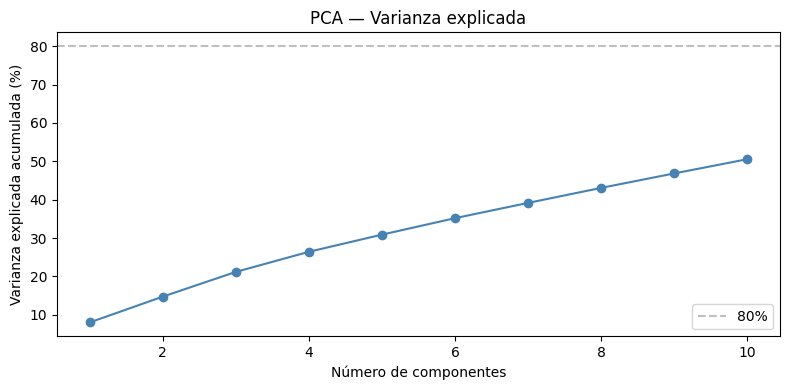

In [211]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── Codificar variables categóricas ───────────────────────────────────────
perfil_enc = pd.get_dummies(perfil, columns=['canal_top', 'turno_top', 'dia_top'], drop_first=False)

# ── Seleccionar features numéricas ────────────────────────────────────────
features = [c for c in perfil_enc.columns if c != 'direccion_limpia']
X = perfil_enc[features].fillna(0)

# ── Escalar ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── PCA ───────────────────────────────────────────────────────────────────
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza_acum = pca.explained_variance_ratio_.cumsum()
print("Varianza explicada acumulada:")
for i, v in enumerate(varianza_acum):
    print(f"  PC{i+1}: {v*100:.1f}%")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 11), varianza_acum * 100, marker='o', color='steelblue')
ax.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80%')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza explicada acumulada (%)')
ax.set_title('PCA — Varianza explicada')
ax.legend()
plt.tight_layout()
plt.show()

### 9.5 PCA de sabores

Antes de la segmentación completa, exploramos la estructura de preferencias de sabores de forma aislada. Trabajamos solo con las proporciones de cada variedad sobre el total de empanadas pedidas por cliente.

El objetivo es identificar si existen "perfiles de paladar" naturales — grupos de clientes que comparten preferencias similares independientemente de su frecuencia, canal o zona.

Varianza explicada PC1: 11.4%
Varianza explicada PC2: 9.4%
Total: 20.8%

Loadings PC1 (sabores que más contribuyen):
                                   PC1       PC2
hongos_shiitake_y_queso_azul  0.542898  0.021266
camarones                     0.367633  0.088681
cordero                       0.317812  0.394464
berenjena                     0.314295 -0.267348
calabresa                     0.125762 -0.107475
arabe                         0.008173 -0.042669
nueva_caprese                 0.004199 -0.102641
chimi_y_provolone            -0.008139 -0.123830
queso_y_aceitunas_marinadas  -0.016070 -0.111926
humita                       -0.098283 -0.393619
espinaca_ricota_y_parmesano  -0.116182 -0.496402
queso_y_verdeo               -0.211810 -0.058190
tucumana                     -0.253105  0.531974
rico_pollo                   -0.259206  0.157376
jamon_y_queso                -0.393479  0.018409


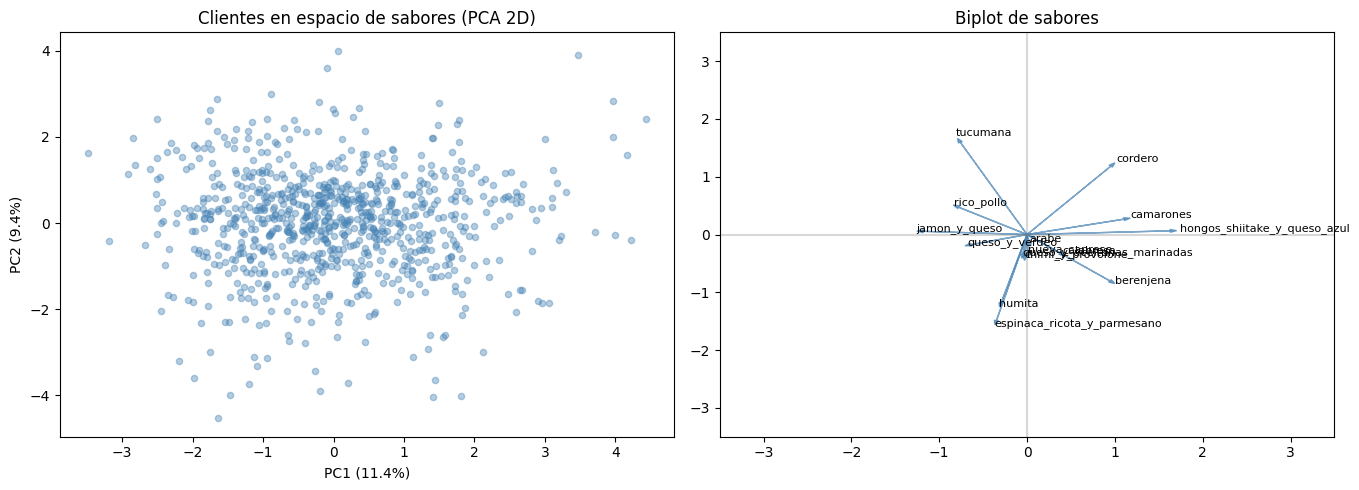

In [212]:
# ── PCA solo sobre sabores ─────────────────────────────────────────────────
emp_pct_cols = [c for c in perfil.columns if c.endswith('_pct')]

X_sab = perfil[emp_pct_cols].fillna(0)
X_sab_scaled = StandardScaler().fit_transform(X_sab)

pca_sab = PCA(n_components=2, random_state=42)
X_sab_2d = pca_sab.fit_transform(X_sab_scaled)

print(f"Varianza explicada PC1: {pca_sab.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza explicada PC2: {pca_sab.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {pca_sab.explained_variance_ratio_.sum()*100:.1f}%")

# Loadings — qué sabores definen cada componente
loadings = pd.DataFrame(
    pca_sab.components_.T,
    index=[c.replace('emp_','').replace('_pct','') for c in emp_pct_cols],
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

print("\nLoadings PC1 (sabores que más contribuyen):")
print(loadings)

# ── Visualización ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter clientes en espacio PCA
axes[0].scatter(X_sab_2d[:, 0], X_sab_2d[:, 1],
                alpha=0.4, s=20, color='steelblue')
axes[0].set_xlabel(f'PC1 ({pca_sab.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_sab.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Clientes en espacio de sabores (PCA 2D)')

# Biplot de loadings
for i, (sabor, row) in enumerate(loadings.iterrows()):
    axes[1].arrow(0, 0, row['PC1']*3, row['PC2']*3,
                  head_width=0.05, color='steelblue', alpha=0.7)
    axes[1].text(row['PC1']*3.2, row['PC2']*3.2, sabor, fontsize=8)
axes[1].set_xlim(-3.5, 3.5)
axes[1].set_ylim(-3.5, 3.5)
axes[1].axhline(0, color='gray', alpha=0.3)
axes[1].axvline(0, color='gray', alpha=0.3)
axes[1].set_title('Biplot de sabores')

plt.tight_layout()
plt.show()

### 9.5.1 Observaciones — PCA de sabores

El PCA sobre proporciones de sabores explica apenas el **20.8% de la varianza en 2 componentes** (PC1: 11.4%, PC2: 9.4%), lo que indica que las preferencias de sabores son altamente heterogéneas y no se reducen a unos pocos ejes dominantes.

El biplot permite interpretar los componentes:

- **PC1 — "Gourmet vs. Clásico":** el extremo positivo agrupa los sabores premium y menos frecuentes (hongos shiitake y queso azul, camarones, cordero, berenjena), mientras que el extremo negativo concentra los sabores más populares y accesibles (jamón y queso, rico pollo, tucumana).

- **PC2 — "Contundente vs. Suave":** separa los sabores más intensos (tucumana, cordero) de los más suaves o vegetarianos (espinaca, ricota y parmesano, humita).

El scatter de clientes no muestra agrupaciones visualmente obvias — la nube es continua y sin clusters bien definidos. Esto refleja que **la mayoría de los clientes mezcla sabores** en lugar de especializarse, y que no existe un perfil de "cliente gourmet puro" claramente separado del "cliente clásico".

Para la segmentación utilizaremos el **perfil completo** (sabores + frecuencia + ticket + canal + turno + día), con más componentes PCA, donde los patrones de comportamiento deberían ser más discriminantes que las preferencias de sabor aisladas.

### 9.6 Segmentación con perfil completo — KMeans

Incorporamos todas las dimensiones del perfil de cliente: frecuencia, ticket promedio, empanadas por pedido, proporción de descuentos, bebidas y postres, canal, turno, día habitual y proporciones de sabores.

Usamos PCA con suficientes componentes para capturar al menos el 70% de la varianza, y luego aplicamos KMeans. El número óptimo de clusters se determina combinando el método del codo y el coeficiente de silueta.

Componentes para 70% de varianza: 16
Varianza explicada acumulada con 16 componentes: 70.4%


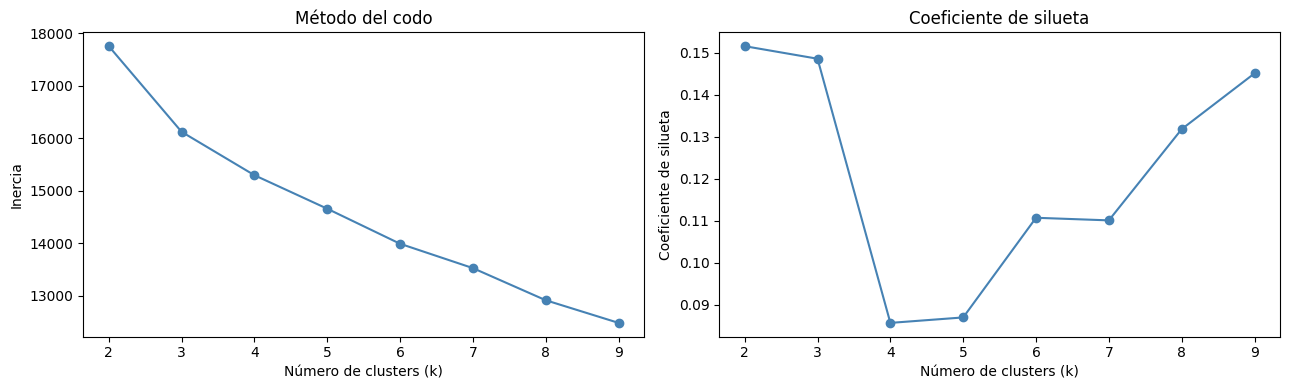


Silhouette scores:
  k=2: 0.1516
  k=3: 0.1486
  k=4: 0.0857
  k=5: 0.0870
  k=6: 0.1108
  k=7: 0.1101
  k=8: 0.1319
  k=9: 0.1451


In [213]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── PCA con más componentes ────────────────────────────────────────────────
pca_full = PCA(n_components=20, random_state=42)
X_full_pca = pca_full.fit_transform(X_scaled)

var_acum = pca_full.explained_variance_ratio_.cumsum()
n_comp_70 = next(i+1 for i, v in enumerate(var_acum) if v >= 0.70)
print(f"Componentes para 70% de varianza: {n_comp_70}")
print(f"Varianza explicada acumulada con {n_comp_70} componentes: {var_acum[n_comp_70-1]*100:.1f}%")

X_cluster = X_full_pca[:, :n_comp_70]

# ── Elbow + Silhouette ─────────────────────────────────────────────────────
inertias, silhouettes = [], []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')

axes[1].plot(K, silhouettes, marker='o', color='steelblue')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta')

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.4f}")

Distribución de clusters:
cluster
0    615
1    190
2     42
Name: count, dtype: int64

Silhouette score final: 0.1486


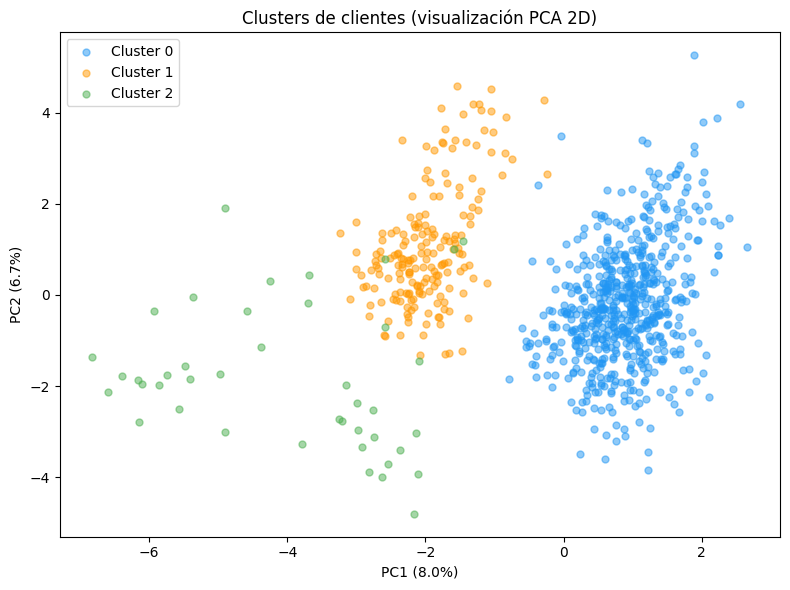

In [214]:
# ── KMeans final con k=3 ──────────────────────────────────────────────────
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
perfil['cluster'] = km_final.fit_predict(X_cluster)

print("Distribución de clusters:")
print(perfil['cluster'].value_counts().sort_index())
print()
print(f"Silhouette score final: {silhouette_score(X_cluster, perfil['cluster']):.4f}")

# ── Visualización en PCA 2D ───────────────────────────────────────────────
pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_scaled)

colores = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}
fig, ax = plt.subplots(figsize=(8, 6))

for c in [0, 1, 2]:
    mask = perfil['cluster'] == c
    ax.scatter(X_viz[mask, 0], X_viz[mask, 1],
               c=colores[c], label=f'Cluster {c}',
               alpha=0.5, s=25)

ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Clusters de clientes (visualización PCA 2D)')
ax.legend()
plt.tight_layout()
plt.show()

In [215]:
# ── Perfil de cada cluster ─────────────────────────────────────────────────
cols_resumen = ['frecuencia', 'total_promedio', 'empanadas_promedio',
                'pct_descuento', 'pct_bebida', 'pct_postre']

resumen = perfil.groupby('cluster')[cols_resumen].mean().round(2)
print(resumen)
print()

# Canal, turno y día más frecuente por cluster
for col in ['canal_top', 'turno_top', 'dia_top']:
    print(f"\n{col}:")
    print(perfil.groupby('cluster')[col].value_counts().unstack().fillna(0).astype(int))

# Top 3 sabores por cluster
print("\nTop 3 sabores por cluster:")
emp_pct_cols = [c for c in perfil.columns if c.endswith('_pct')]
for c in [0, 1, 2]:
    top = perfil[perfil['cluster'] == c][emp_pct_cols].mean().sort_values(ascending=False).head(3)
    top.index = top.index.str.replace('emp_', '').str.replace('_pct', '')
    print(f"\nCluster {c}:")
    print(top.round(3))

         frecuencia  total_promedio  empanadas_promedio  pct_descuento  \
cluster                                                                  
0             22.09          823.51                6.91           0.35   
1             16.12          822.53                6.25           0.10   
2             17.93          687.97                5.77           0.36   

         pct_bebida  pct_postre  
cluster                          
0              0.13        0.04  
1              0.19        0.03  
2              0.24        0.02  


canal_top:
canal_top    H  LOCAL   PY
cluster                   
0          613      2    0
1            1      1  188
2           22      3   17

turno_top:
turno_top  mediodia  noche
cluster                   
0                 0    615
1                 0    190
2                42      0

dia_top:
dia_top  Domingo  Jueves  Lunes  Martes  Miércoles  Sábado  Viernes
cluster                                                            
0            179  

### 9.7 Interpretación de clusters

Los tres clusters están definidos principalmente por **canal de compra y turno**, no por preferencias de sabores — el top 3 de sabores es prácticamente idéntico en los tres grupos (tucumana, hongos shiitake y queso azul, jamón y queso).

| | Cluster 0 | Cluster 1 | Cluster 2 |
|---|---|---|---|
| **Nombre** | Cliente web noche | Cliente PedidosYa noche | Cliente mediodía |
| **Tamaño** | 615 (73%) | 190 (22%) | 42 (5%) |
| **Canal** | H (web propia) | PY | Mix |
| **Turno** | Noche | Noche | Mediodía |
| **Frecuencia** | 22 pedidos | 16 pedidos | 18 pedidos |
| **Ticket promedio** | $824 | $823 | $688 |
| **% con descuento** | 35% | 10% | 36% |
| **% con bebida** | 13% | 19% | 24% |
| **Día típico** | Domingo | Domingo | Distribuido |

#### Hallazgos clave

- **El canal es el principal diferenciador** entre clientes frecuentes, no los sabores ni la frecuencia.
- **Cluster 1 (PedidosYa) paga sin descuento:** solo el 10% de sus pedidos tiene promoción, contra el 35% del Cluster 0. Son clientes de alto valor que no necesitan incentivo para comprar.
- **Cluster 2 (mediodía) tiene perfil de almuerzo:** ticket más bajo, más bebidas, menos empanadas por pedido. Probablemente clientes de oficina o zona laboral.
- **Los sabores no segmentan:** todos los clientes frecuentes comparten las mismas preferencias de sabor, lo que sugiere que el menú tiene una propuesta de valor consistente independientemente del perfil de compra.

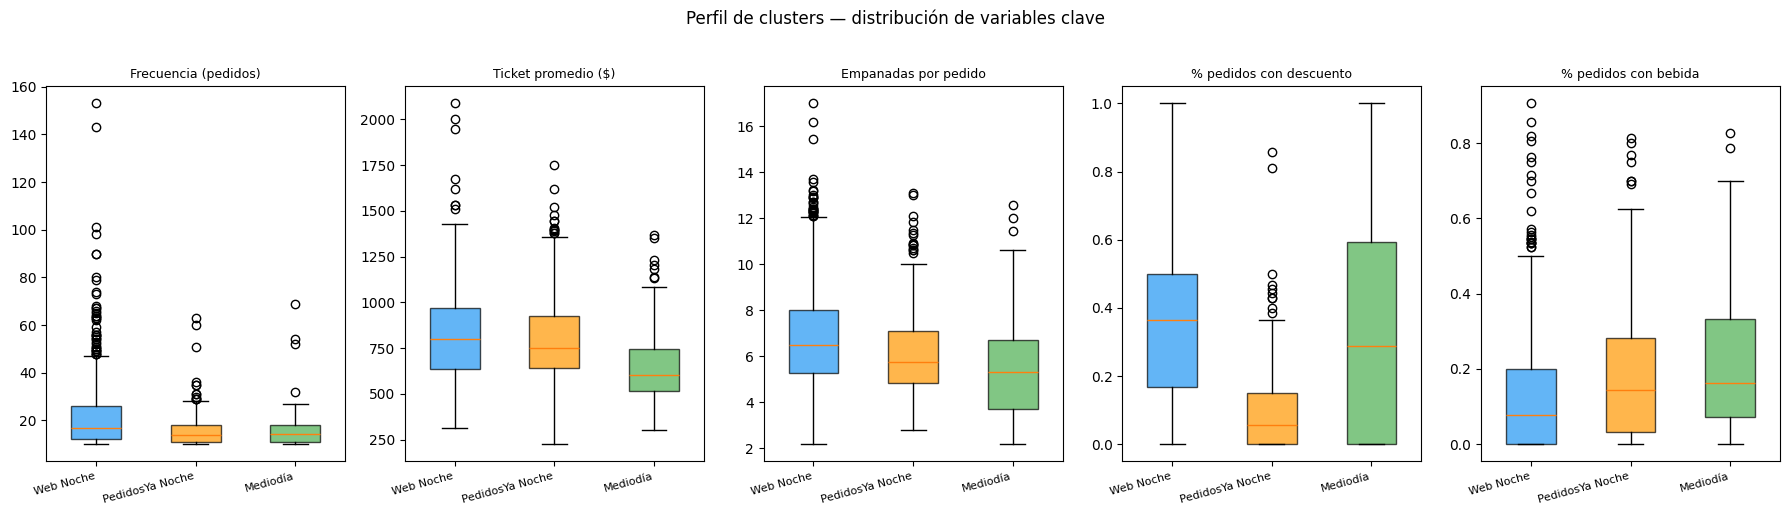

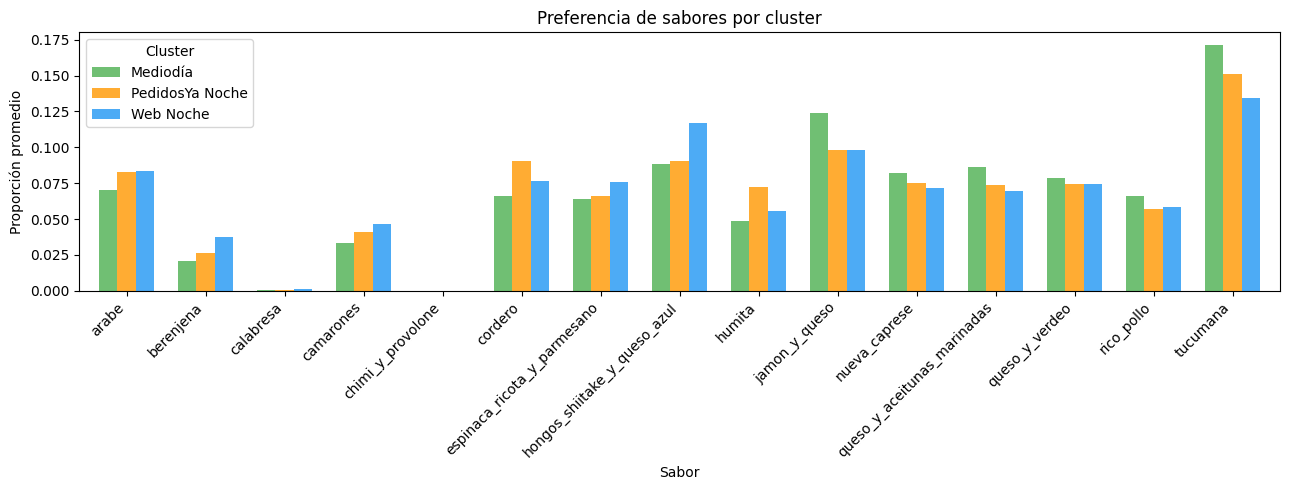

In [216]:
# ── Profiling visual — boxplots ───────────────────────────────────────────
cluster_nombres = {0: 'Web Noche', 1: 'PedidosYa Noche', 2: 'Mediodía'}
perfil['cluster_nombre'] = perfil['cluster'].map(cluster_nombres)
colores_cluster = {'Web Noche': '#2196F3', 'PedidosYa Noche': '#FF9800', 'Mediodía': '#4CAF50'}

cols_box = ['frecuencia', 'total_promedio', 'empanadas_promedio', 'pct_descuento', 'pct_bebida']
titulos  = ['Frecuencia (pedidos)', 'Ticket promedio ($)', 'Empanadas por pedido',
            '% pedidos con descuento', '% pedidos con bebida']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col, titulo in zip(axes, cols_box, titulos):
    data_plot = [perfil[perfil['cluster_nombre'] == n][col].values
                 for n in cluster_nombres.values()]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5)
    for patch, nombre in zip(bp['boxes'], cluster_nombres.values()):
        patch.set_facecolor(colores_cluster[nombre])
        patch.set_alpha(0.7)
    ax.set_xticklabels(cluster_nombres.values(), rotation=15, ha='right', fontsize=8)
    ax.set_title(titulo, fontsize=9)

plt.suptitle('Perfil de clusters — distribución de variables clave', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Profiling visual — barplot sabores ────────────────────────────────────
emp_pct_cols = [c for c in perfil.columns if c.endswith('_pct')]
sabores_media = perfil.groupby('cluster_nombre')[emp_pct_cols].mean()
sabores_media.columns = sabores_media.columns.str.replace('emp_','').str.replace('_pct','')

fig, ax = plt.subplots(figsize=(13, 5))
sabores_media.T.plot(kind='bar', ax=ax,
                     color=[colores_cluster[n] for n in sabores_media.index],
                     alpha=0.8, width=0.7)
ax.set_xlabel('Sabor')
ax.set_ylabel('Proporción promedio')
ax.set_title('Preferencia de sabores por cluster')
ax.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.8 Observaciones — Profiling visual

Los boxplots confirman y enriquecen el perfil de cada cluster:

**Frecuencia:** el cluster Web Noche tiene la frecuencia más alta y más dispersa, con outliers de hasta 150 pedidos en dos años — clientes extremadamente fieles que piden casi semanalmente.

**Ticket promedio:** Web Noche y PedidosYa Noche tienen tickets similares (aprox 825), ambos significativamente más altos que Mediodía (aprox 688). La dispersión es mayor en Web Noche, donde conviven pedidos individuales y grupales.

**Descuentos:** el hallazgo más relevante para el negocio. PedidosYa Noche tiene una mediana de descuento cercana a cero y muy poca dispersión — la gran mayoría compra sin promoción. Web Noche y Mediodía reciben descuentos en aproximadamente el 35% de sus pedidos.

**Bebidas:** el cluster Mediodía agrega bebida con más frecuencia, consistente con un perfil de almuerzo completo.

**Sabores:** las preferencias son prácticamente idénticas entre los tres clusters. Tucumana, hongos shiitake y queso azul y jamón y queso lideran en todos los grupos, lo que confirma que el menú tiene una propuesta de valor transversal independiente del perfil de compra.

> El canal de compra es el principal eje de diferenciación entre clientes frecuentes de La Campeona — no los sabores, no el ticket, no la frecuencia.

In [217]:
# ── Cruzar clusters con coordenadas ───────────────────────────────────────
perfil_geo = perfil[['direccion_limpia', 'cluster', 'cluster_nombre',
                      'frecuencia', 'total_promedio']].merge(
    pedidos_geo_filtrado[['direccion_limpia', 'lat', 'lon']].drop_duplicates('direccion_limpia'),
    on='direccion_limpia', how='inner'
)

print(f"Clientes con coordenadas: {len(perfil_geo):,} de {len(perfil):,}")

# ── Mapa ──────────────────────────────────────────────────────────────────
import folium

colores_folium = {'Web Noche': '#2196F3', 'PedidosYa Noche': '#FF9800', 'Mediodía': '#4CAF50'}

m = folium.Map(location=[-34.9011, -56.1645], zoom_start=13,
               tiles='CartoDB positron')

for _, row in perfil_geo.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=colores_folium[row['cluster_nombre']],
        fill=True,
        fill_color=colores_folium[row['cluster_nombre']],
        fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['cluster_nombre']}</b><br>"
            f"Frecuencia: {row['frecuencia']} pedidos<br>"
            f"Ticket prom: ${row['total_promedio']:.0f}",
            max_width=200
        )
    ).add_to(m)

# Leyenda
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.2); font-family:sans-serif; font-size:13px;">
  <b>Clusters</b><br>
  <span style="color:#2196F3">●</span> Web Noche<br>
  <span style="color:#FF9800">●</span> PedidosYa Noche<br>
  <span style="color:#4CAF50">●</span> Mediodía
</div>
"""
m.get_root().html.add_child(folium.Element(leyenda))

m.save('/content/mapa_clusters.html')
print("Mapa guardado en /content/mapa_clusters.html")

Clientes con coordenadas: 738 de 847
Mapa guardado en /content/mapa_clusters.html


In [218]:
from google.colab import files
files.download('/content/mapa_clusters.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9.9 Conclusiones y recomendaciones — Segmentación

La segmentación de clientes frecuentes (≥ 10 pedidos en dos años) revela que **el canal de compra es el principal eje de diferenciación**, por encima de los sabores, el ticket o la zona geográfica. Los tres clusters no tienen patrón espacial — están distribuidos homogéneamente por Montevideo, lo que indica que la elección de canal es una preferencia personal, no geográfica.

#### Recomendaciones por cluster

**Cluster 0 — Web Noche (73% de los clientes frecuentes)**
Son el núcleo de la base de clientes: alta frecuencia, ticket alto, canal propio. El 35% de sus pedidos tiene descuento — vale la pena analizar si esos descuentos son necesarios para retenerlos o si comprarían igual sin promoción. Un programa de fidelización (puntos, beneficios por frecuencia) podría reducir la dependencia del descuento manteniendo la retención.

**Cluster 1 — PedidosYa Noche (22% de los clientes frecuentes)**
Son el segmento de mayor oportunidad. Pagan sin descuento (solo 10% de sus pedidos tiene promoción), lo que los convierte en clientes de alto valor neto. Sin embargo, cada pedido implica una comisión para PedidosYa. **Migrar aunque sea una parte de estos clientes al canal propio (H) con un incentivo de bienvenida podría tener un impacto directo en el margen**, sin necesidad de bajar el ticket.

**Cluster 2 — Mediodía (5% de los clientes frecuentes)**
Grupo pequeño pero con perfil diferenciado: almuerzo, más bebidas, ticket más bajo. Si existe interés en crecer en el segmento de almuerzo, este cluster define bien el perfil objetivo: pedidos de entre 5 y 6 empanadas acompañadas de bebida, de lunes a viernes.

#### Limitación
El uso de dirección como proxy de cliente subestima la cantidad real de clientes únicos, especialmente en edificios de apartamentos. Los perfiles son robustos a nivel de zona de entrega pero deben interpretarse con cautela a nivel individual.

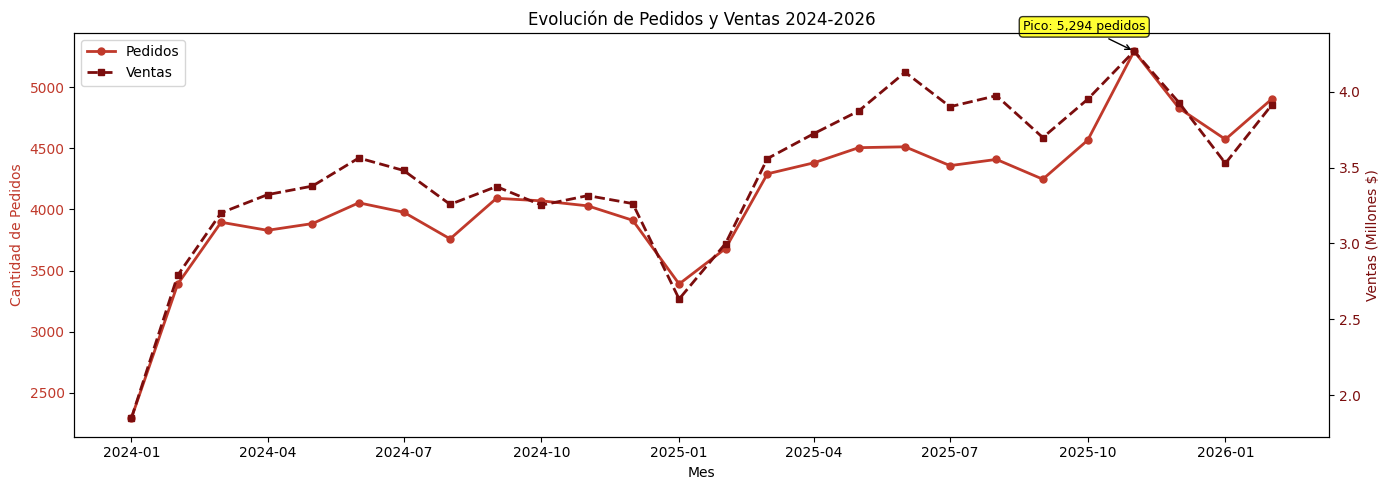

In [219]:
# ── Evolución mensual de pedidos y ventas ─────────────────────────────────
evol = pedidos_df.groupby('anio_mes').agg(
    pedidos = ('pedido_id', 'count'),
    ventas  = ('total', 'sum')
).reset_index()

evol['ventas_M'] = evol['ventas'] / 1_000_000
evol['anio_mes_dt'] = pd.to_datetime(evol['anio_mes'].astype(str), format='%Y-%m')

fig, ax1 = plt.subplots(figsize=(14, 5))

# Pedidos — eje izquierdo
ax1.plot(evol['anio_mes_dt'], evol['pedidos'],
         color='#c0392b', marker='o', linewidth=2, markersize=5, label='Pedidos')
ax1.set_ylabel('Cantidad de Pedidos', color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')

# Ventas — eje derecho
ax2 = ax1.twinx()
ax2.plot(evol['anio_mes_dt'], evol['ventas_M'],
         color='#7b0d0d', marker='s', linewidth=2, markersize=5,
         linestyle='--', label='Ventas')
ax2.set_ylabel('Ventas (Millones $)', color='#7b0d0d')
ax2.tick_params(axis='y', labelcolor='#7b0d0d')

# Pico
idx_pico = evol['pedidos'].idxmax()
ax1.annotate(f"Pico: {evol.loc[idx_pico, 'pedidos']:,} pedidos",
             xy=(evol.loc[idx_pico, 'anio_mes_dt'], evol.loc[idx_pico, 'pedidos']),
             xytext=(-80, 15), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.8))

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlabel('Mes')
ax1.set_title('Evolución de Pedidos y Ventas 2024-2026')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Modelos Predictivos

### 10.1 Construcción del Dataset de Pronóstico

El dataset de pronóstico tiene una granularidad diferente al dataset de análisis: **un registro por día × sucursal × sabor**. Esto permite predecir cuántas unidades de cada sabor se venden en cada sucursal cada día, que es la información directamente útil para planificar la producción.

Se construye a partir de `pedidos_df` (sin el filtro de outliers de total, ya que nos interesa la cantidad de empanadas, no el ticket) agregando las columnas `emp_*` por día y sucursal.

In [220]:
# ── Dataset de pronóstico: día × sucursal × sabor ─────────────────────────
emp_cols = [c for c in pedidos_df.columns if c.startswith('emp_')]

# Agregar por día y sucursal
df_agg = pedidos_df.groupby(['fecha_dia', 'sucursal'])[emp_cols].sum().reset_index()

# Pasar a formato largo (un registro por día × sucursal × sabor)
df_largo = df_agg.melt(
    id_vars=['fecha_dia', 'sucursal'],
    value_vars=emp_cols,
    var_name='sabor',
    value_name='cantidad'
)

# Limpiar nombre del sabor
df_largo['sabor'] = df_largo['sabor'].str.replace('emp_', '', regex=False)

# Fecha como datetime
df_largo['fecha_dia'] = pd.to_datetime(df_largo['fecha_dia'])

# Ordenar
df_largo = df_largo.sort_values(['sucursal', 'sabor', 'fecha_dia']).reset_index(drop=True)

print(f"Filas:      {len(df_largo):,}")
print(f"Sucursales: {df_largo['sucursal'].nunique()}")
print(f"Sabores:    {df_largo['sabor'].nunique()}")
print(f"Período:    {df_largo['fecha_dia'].min()} → {df_largo['fecha_dia'].max()}")
print()
print(df_largo.head(10))

Filas:      23,055
Sucursales: 2
Sabores:    15
Período:    2024-01-08 00:00:00 → 2026-02-28 00:00:00

   fecha_dia sucursal  sabor  cantidad
0 2024-01-08      COR  arabe      10.0
1 2024-01-09      COR  arabe      23.0
2 2024-01-10      COR  arabe      20.0
3 2024-01-11      COR  arabe      39.0
4 2024-01-12      COR  arabe      27.0
5 2024-01-13      COR  arabe      21.0
6 2024-01-14      COR  arabe      19.0
7 2024-01-15      COR  arabe      17.0
8 2024-01-16      COR  arabe      24.0
9 2024-01-17      COR  arabe      24.0


In [221]:
# ── Eliminar sabores discontinuados y rehacer desde df_agg ────────────────
sabores_discontinuados = ['chimi_y_provolone', 'calabresa']

emp_cols_filtrados = [c for c in emp_cols
                      if c.replace('emp_', '') not in sabores_discontinuados]

# Formato largo sin discontinuados
df_largo = df_agg.melt(
    id_vars=['fecha_dia', 'sucursal'],
    value_vars=emp_cols_filtrados,
    var_name='sabor',
    value_name='cantidad'
)

df_largo['sabor']     = df_largo['sabor'].str.replace('emp_', '', regex=False)
df_largo['fecha_dia'] = pd.to_datetime(df_largo['fecha_dia'])
df_largo = df_largo.sort_values(['sucursal', 'sabor', 'fecha_dia']).reset_index(drop=True)

print(f"Sabores: {df_largo['sabor'].nunique()} → {df_largo['sabor'].unique()}")
print(f"Filas:   {len(df_largo):,}")

Sabores: 13 → ['arabe' 'berenjena' 'camarones' 'cordero' 'espinaca_ricota_y_parmesano'
 'hongos_shiitake_y_queso_azul' 'humita' 'jamon_y_queso' 'nueva_caprese'
 'queso_y_aceitunas_marinadas' 'queso_y_verdeo' 'rico_pollo' 'tucumana']
Filas:   19,981


In [222]:
# ── Verificar días faltantes ───────────────────────────────────────────────
fecha_min = df_largo['fecha_dia'].min()
fecha_max = df_largo['fecha_dia'].max()
calendario = pd.date_range(fecha_min, fecha_max, freq='D')

# Combinaciones esperadas
from itertools import product
sucursales = df_largo['sucursal'].unique()
sabores    = df_largo['sabor'].unique()

idx_completo = pd.MultiIndex.from_product(
    [calendario, sucursales, sabores],
    names=['fecha_dia', 'sucursal', 'sabor']
)

df_completo = pd.DataFrame(index=idx_completo).reset_index()
df_completo = df_completo.merge(df_largo, on=['fecha_dia', 'sucursal', 'sabor'], how='left')
df_completo['cantidad'] = df_completo['cantidad'].fillna(0)

df_completo['cantidad_manana'] = (
    df_completo
    .groupby(['sucursal', 'sabor'])['cantidad']
    .shift(-1)
)

print(f"Filas esperadas:  {len(df_completo):,}")
print(f"Filas originales: {len(df_largo):,}")
print(f"Días faltantes rellenados: {len(df_completo) - len(df_largo):,}")
print(f"\nDataset completo shape: {df_completo.shape}")

Filas esperadas:  20,358
Filas originales: 19,981
Días faltantes rellenados: 377

Dataset completo shape: (20358, 5)


In [223]:
# ── Verificación puntual ───────────────────────────────────────────────────
dia_test    = '2025-06-06'  # un viernes cualquiera
sabor_test  = 'tucumana'
suc_test    = 'COR'

# Lo que dice df_completo
valor_agg = df_completo[
    (df_completo['fecha_dia'] == dia_test) &
    (df_completo['sabor'] == sabor_test) &
    (df_completo['sucursal'] == suc_test)
]['cantidad'].values[0]

# Lo que dicen los pedidos originales
valor_orig = pedidos_df[
    (pedidos_df['fecha_dia'].astype(str) == dia_test) &
    (pedidos_df['sucursal'] == suc_test)
]['emp_tucumana'].sum()

print(f"Día:      {dia_test}")
print(f"Sucursal: {suc_test}")
print(f"Sabor:    {sabor_test}")
print(f"df_completo: {valor_agg}")
print(f"pedidos_df:  {valor_orig}")
print(f"¿Coinciden? {valor_agg == valor_orig}")

Día:      2025-06-06
Sucursal: COR
Sabor:    tucumana
df_completo: 64.0
pedidos_df:  64.0
¿Coinciden? True


### 10.2 Feature Engineering

Se agregan variables que capturan patrones temporales, estacionalidad y demanda histórica reciente. Estas son las variables más predictivas para series temporales de ventas.

In [224]:
# ── Ordenar ────────────────────────────────────────────────────────────────
df_modelo = df_completo.sort_values(['sucursal', 'sabor', 'fecha_dia']).reset_index(drop=True)

# ── Día de semana ──────────────────────────────────────────────────────────
df_modelo['dia_semana'] = df_modelo['fecha_dia'].dt.dayofweek

# ── Lags y promedios móviles (por sucursal × sabor) ───────────────────────
grupo = ['sucursal', 'sabor']

for lag in [7, 14]:
    df_modelo[f'lag_{lag}'] = df_modelo.groupby(grupo)['cantidad'].shift(lag)

for ventana in [7, 14, 30]:
    df_modelo[f'ma_{ventana}'] = (
        df_modelo.groupby(grupo)['cantidad']
        .transform(lambda x: x.shift(1).rolling(ventana, min_periods=1).mean())
    )

# ── Eliminar filas sin lags ────────────────────────────────────────────────
df_modelo = df_modelo.dropna(subset=['lag_7', 'lag_14', 'cantidad_manana']).reset_index(drop=True)

print(f"Shape: {df_modelo.shape}")
print(f"Columnas: {df_modelo.columns.tolist()}")

Shape: (19968, 11)
Columnas: ['fecha_dia', 'sucursal', 'sabor', 'cantidad', 'cantidad_manana', 'dia_semana', 'lag_7', 'lag_14', 'ma_7', 'ma_14', 'ma_30']


In [225]:
# ── Ordenar ────────────────────────────────────────────────────────────────
df_modelo = df_completo.sort_values(['sucursal', 'sabor', 'fecha_dia']).reset_index(drop=True)

# ── Día de semana ──────────────────────────────────────────────────────────
df_modelo['dia_semana'] = df_modelo['fecha_dia'].dt.dayofweek

# ── Lags y promedios móviles (por sucursal × sabor) ───────────────────────
grupo = ['sucursal', 'sabor']

for lag in [7, 14]:
    df_modelo[f'lag_{lag}'] = df_modelo.groupby(grupo)['cantidad'].shift(lag)

for ventana in [7, 14, 30]:
    df_modelo[f'ma_{ventana}'] = (
        df_modelo.groupby(grupo)['cantidad']
        .transform(lambda x: x.shift(1).rolling(ventana, min_periods=1).mean())
    )

# ── Clásicos Nacional vs Peñarol ──────────────────────────────────────────
clasicos = pd.to_datetime([
    '2024-01-17', '2024-01-23', '2024-03-29', '2024-08-04', '2024-10-06',
    '2025-01-20', '2025-01-26', '2025-02-09', '2025-07-06', '2025-08-09',
    '2025-11-23', '2025-11-30', '2026-01-26', '2026-03-01',
])

# ── Libertadores ──────────────────────────────────────────────────────────
libertadores_pen = pd.to_datetime([
    '2024-04-04', '2024-04-10', '2024-04-23', '2024-05-07', '2024-05-14', '2024-05-28',
    '2024-08-14', '2024-08-21', '2024-09-19', '2024-09-26', '2024-10-23', '2024-10-30',
    '2025-04-02', '2025-04-08', '2025-04-23', '2025-05-06', '2025-05-14', '2025-05-29',
    '2025-08-12', '2025-08-19',
])

libertadores_nac = pd.to_datetime([
    '2024-02-21', '2024-02-28', '2024-03-07', '2024-03-14',
    '2024-04-03', '2024-04-11', '2024-04-24', '2024-05-07', '2024-05-15', '2024-05-30',
    '2024-08-15', '2024-08-22',
    '2025-04-02', '2025-04-09', '2025-04-22', '2025-05-07', '2025-05-15', '2025-05-28',
])

todos_libertadores = libertadores_pen.union(libertadores_nac)

df_modelo['es_clasico']      = df_modelo['fecha_dia'].isin(clasicos).astype(int)
df_modelo['es_libertadores'] = df_modelo['fecha_dia'].isin(todos_libertadores).astype(int)

# ── Selección uruguaya ────────────────────────────────────────────────────
partidos_seleccion = pd.to_datetime([
    '2024-06-23', '2024-06-27', '2024-07-01', '2024-07-06', '2024-07-10', '2024-07-13',
    '2024-09-06', '2024-09-10', '2024-10-11', '2024-10-15', '2024-11-15', '2024-11-19',
    '2025-03-21', '2025-06-05', '2025-06-10', '2025-09-04', '2025-09-09',
])

df_modelo['es_seleccion'] = df_modelo['fecha_dia'].isin(partidos_seleccion).astype(int)

# ── Eliminar filas sin lags ────────────────────────────────────────────────
df_modelo = df_modelo.dropna().reset_index(drop=True)

print(f"Shape: {df_modelo.shape}")
print(f"Columnas: {df_modelo.columns.tolist()}")
print(f"\nPartidos en el período:")
print(f"  Clásicos:      {df_modelo['es_clasico'].sum() // df_modelo['sucursal'].nunique() // df_modelo['sabor'].nunique()}")
print(f"  Libertadores:  {df_modelo['es_libertadores'].sum() // df_modelo['sucursal'].nunique() // df_modelo['sabor'].nunique()}")
print(f"  Selección:     {df_modelo['es_seleccion'].sum() // df_modelo['sucursal'].nunique() // df_modelo['sabor'].nunique()}")

Shape: (19968, 14)
Columnas: ['fecha_dia', 'sucursal', 'sabor', 'cantidad', 'cantidad_manana', 'dia_semana', 'lag_7', 'lag_14', 'ma_7', 'ma_14', 'ma_30', 'es_clasico', 'es_libertadores', 'es_seleccion']

Partidos en el período:
  Clásicos:      12
  Libertadores:  36
  Selección:     17


In [226]:
# ── One-hot encoding ───────────────────────────────────────────────────────
df_modelo = pd.get_dummies(df_modelo, columns=['sucursal', 'sabor'], drop_first=False)

print(f"Shape: {df_modelo.shape}")
print(f"Columnas: {df_modelo.columns.tolist()}")

Shape: (19968, 27)
Columnas: ['fecha_dia', 'cantidad', 'cantidad_manana', 'dia_semana', 'lag_7', 'lag_14', 'ma_7', 'ma_14', 'ma_30', 'es_clasico', 'es_libertadores', 'es_seleccion', 'sucursal_COR', 'sucursal_PC', 'sabor_arabe', 'sabor_berenjena', 'sabor_camarones', 'sabor_cordero', 'sabor_espinaca_ricota_y_parmesano', 'sabor_hongos_shiitake_y_queso_azul', 'sabor_humita', 'sabor_jamon_y_queso', 'sabor_nueva_caprese', 'sabor_queso_y_aceitunas_marinadas', 'sabor_queso_y_verdeo', 'sabor_rico_pollo', 'sabor_tucumana']


In [227]:
# ── Train/Test split temporal ─────────────────────────────────────────────
fecha_corte = pd.Timestamp('2025-11-01')

feature_cols = [c for c in df_modelo.columns if c not in ['fecha_dia', 'cantidad','cantidad_manana']]

X = df_modelo[feature_cols]
y = df_modelo['cantidad_manana']

X_train = X[df_modelo['fecha_dia'] < fecha_corte]
X_test  = X[df_modelo['fecha_dia'] >= fecha_corte]
y_train = y[df_modelo['fecha_dia'] < fecha_corte]
y_test  = y[df_modelo['fecha_dia'] >= fecha_corte]

print(f"Train: {len(X_train):,} filas ({df_modelo[df_modelo['fecha_dia'] < fecha_corte]['fecha_dia'].min().date()} → {df_modelo[df_modelo['fecha_dia'] < fecha_corte]['fecha_dia'].max().date()})")
print(f"Test:  {len(X_test):,} filas  ({df_modelo[df_modelo['fecha_dia'] >= fecha_corte]['fecha_dia'].min().date()} → {df_modelo[df_modelo['fecha_dia'] >= fecha_corte]['fecha_dia'].max().date()})")
print(f"% test: {len(X_test)/len(X)*100:.1f}%")

Train: 16,874 filas (2024-01-22 → 2025-10-31)
Test:  3,094 filas  (2025-11-01 → 2026-02-27)
% test: 15.5%


In [228]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ── Baseline: Regresión Lineal ─────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# ── Métricas ───────────────────────────────────────────────────────────────
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

# MAPE excluyendo días con cantidad = 0 (división por cero)
mask = y_test > 0
mape_lr = np.mean(np.abs((y_test[mask] - y_pred_lr[mask]) / y_test[mask])) * 100

print(f"Baseline — Regresión Lineal")
print(f"MAE:  {mae_lr:.2f} empanadas")
print(f"MAPE: {mape_lr:.2f}%")
print(f"R²:   {r2_lr:.4f}")

Baseline — Regresión Lineal
MAE:  11.54 empanadas
MAPE: 31.63%
R²:   0.6288


In [229]:
from sklearn.ensemble import RandomForestRegressor

# ── Random Forest ──────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
mask    = y_test > 0
mape_rf = np.mean(np.abs((y_test[mask] - y_pred_rf[mask]) / y_test[mask])) * 100

print(f"Random Forest")
print(f"MAE:  {mae_rf:.2f} empanadas")
print(f"MAPE: {mape_rf:.2f}%")
print(f"R²:   {r2_rf:.4f}")

Random Forest
MAE:  12.24 empanadas
MAPE: 33.86%
R²:   0.6094


In [230]:
from xgboost import XGBRegressor

# ── XGBoost ────────────────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)
mask     = y_test > 0
mape_xgb = np.mean(np.abs((y_test[mask] - y_pred_xgb[mask]) / y_test[mask])) * 100

print(f"XGBoost")
print(f"MAE:  {mae_xgb:.2f} empanadas")
print(f"MAPE: {mape_xgb:.2f}%")
print(f"R²:   {r2_xgb:.4f}")

XGBoost
MAE:  12.21 empanadas
MAPE: 32.90%
R²:   0.6023


In [231]:
# ── Ver cuántos ceros hay en test ──────────────────────────────────────────
print(f"Ceros en y_test:     {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"No ceros en y_test:  {(y_test > 0).sum():,} ({(y_test > 0).mean()*100:.1f}%)")

# Métricas solo sobre días con ventas reales
mask = y_test > 0
mae_xgb_sinc  = mean_absolute_error(y_test[mask], y_pred_xgb[mask])
r2_xgb_sinc   = r2_score(y_test[mask], y_pred_xgb[mask])
mape_xgb_sinc = np.mean(np.abs((y_test[mask] - y_pred_xgb[mask]) / y_test[mask])) * 100

print(f"\nXGBoost sin ceros:")
print(f"MAE:  {mae_xgb_sinc:.2f}")
print(f"MAPE: {mape_xgb_sinc:.2f}%")
print(f"R²:   {r2_xgb_sinc:.4f}")

Ceros en y_test:     81 (2.6%)
No ceros en y_test:  3,013 (97.4%)

XGBoost sin ceros:
MAE:  11.60
MAPE: 32.90%
R²:   0.6304


In [232]:
resumen = df_completo.groupby(['sucursal', 'sabor']).agg(
    total_dias     = ('fecha_dia', 'count'),
    dias_con_venta = ('cantidad', lambda x: (x > 0).sum()),
    ultima_venta   = ('fecha_dia', 'max'),
    primera_venta  = ('fecha_dia', 'min'),
).reset_index()

resumen['pct_activo'] = resumen['dias_con_venta'] / resumen['total_dias'] * 100

print(resumen.sort_values('pct_activo').to_string())

   sucursal                         sabor  total_dias  dias_con_venta ultima_venta primera_venta  pct_activo
0       COR                         arabe         783             758   2026-02-28    2024-01-08   96.807152
8       COR                 nueva_caprese         783             758   2026-02-28    2024-01-08   96.807152
1       COR                     berenjena         783             762   2026-02-28    2024-01-08   97.318008
2       COR                     camarones         783             763   2026-02-28    2024-01-08   97.445722
3       COR                       cordero         783             763   2026-02-28    2024-01-08   97.445722
4       COR   espinaca_ricota_y_parmesano         783             765   2026-02-28    2024-01-08   97.701149
6       COR                        humita         783             765   2026-02-28    2024-01-08   97.701149
5       COR  hongos_shiitake_y_queso_azul         783             765   2026-02-28    2024-01-08   97.701149
7       COR        

In [233]:
print(f"pedidos_df filas:  {len(pedidos_df):,}")
print(f"df_agg filas:      {len(df_agg):,}")
print(f"Período pedidos_df: {pedidos_df['fecha_dia'].min()} → {pedidos_df['fecha_dia'].max()}")
print(f"Período df_agg:     {df_agg['fecha_dia'].min()} → {df_agg['fecha_dia'].max()}")
print(f"\nTotal empanadas pedidos_df: {pedidos_df[emp_cols].sum().sum():,.0f}")
print(f"Total empanadas df_agg:     {df_agg[emp_cols_filtrados].sum().sum():,.0f}")

pedidos_df filas:  107,116
df_agg filas:      1,537
Período pedidos_df: 2024-01-08 → 2026-02-28
Período df_agg:     2024-01-08 → 2026-02-28

Total empanadas pedidos_df: 751,043
Total empanadas df_agg:     750,290


In [234]:
from lightgbm import LGBMRegressor

# ── LightGBM ───────────────────────────────────────────────────────────────
lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

mae_lgbm  = mean_absolute_error(y_test, y_pred_lgbm)
r2_lgbm   = r2_score(y_test, y_pred_lgbm)
mask      = y_test > 0
mape_lgbm = np.mean(np.abs((y_test[mask] - y_pred_lgbm[mask]) / y_test[mask])) * 100

print(f"LightGBM")
print(f"MAE:  {mae_lgbm:.2f} empanadas")
print(f"MAPE: {mape_lgbm:.2f}%")
print(f"R²:   {r2_lgbm:.4f}")

LightGBM
MAE:  12.15 empanadas
MAPE: 32.89%
R²:   0.6063


In [235]:
from sklearn.model_selection import RandomizedSearchCV

# ── RandomizedSearch RF ────────────────────────────────────────────────────
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [8, 10, 12, 15],
    'min_samples_leaf':[5, 10, 15, 20],
    'max_features':    ['sqrt', 0.5, 0.7],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print(f"Mejores parámetros: {rf_search.best_params_}")

y_pred_rf_opt = rf_search.predict(X_test)
mae_rf_opt  = mean_absolute_error(y_test, y_pred_rf_opt)
r2_rf_opt   = r2_score(y_test, y_pred_rf_opt)
mask        = y_test > 0
mape_rf_opt = np.mean(np.abs((y_test[mask] - y_pred_rf_opt[mask]) / y_test[mask])) * 100

print(f"\nRF Optimizado")
print(f"MAE:  {mae_rf_opt:.2f} empanadas")
print(f"MAPE: {mape_rf_opt:.2f}%")
print(f"R²:   {r2_rf_opt:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 8}

RF Optimizado
MAE:  11.81 empanadas
MAPE: 32.83%
R²:   0.6265


In [236]:
# ── RF Conservador final ───────────────────────────────────────────────────
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)
y_pred_rf_final = rf_final.predict(X_test)

mae_rf_final  = mean_absolute_error(y_test, y_pred_rf_final)
r2_rf_final   = r2_score(y_test, y_pred_rf_final)
mask          = y_test > 0
mape_rf_final = np.mean(np.abs((y_test[mask] - y_pred_rf_final[mask]) / y_test[mask])) * 100

print(f"RF Conservador Final")
print(f"MAE:  {mae_rf_final:.2f} empanadas")
print(f"MAPE: {mape_rf_final:.2f}%")
print(f"R²:   {r2_rf_final:.4f}")

RF Conservador Final
MAE:  11.77 empanadas
MAPE: 32.84%
R²:   0.6279


In [237]:
# ── Tabla comparativa ──────────────────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal (baseline)',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'RF Optimizado',
    ],
    'MAE': [mae_lr, mae_rf, mae_xgb, mae_lgbm, mae_rf_opt],
    'MAPE': [mape_lr, mape_rf, mape_xgb, mape_lgbm, mape_rf_opt],
    'R²': [r2_lr, r2_rf, r2_xgb, r2_lgbm, r2_rf_opt],
}).sort_values('R²', ascending=False).reset_index(drop=True)

resultados['MAE']  = resultados['MAE'].round(2)
resultados['MAPE'] = resultados['MAPE'].round(2)
resultados['R²']   = resultados['R²'].round(4)

print(resultados.to_string(index=False))

                     Modelo   MAE  MAPE     R²
Regresión Lineal (baseline) 11.54 31.63 0.6288
              RF Optimizado 11.81 32.83 0.6265
              Random Forest 12.24 33.86 0.6094
                   LightGBM 12.15 32.89 0.6063
                    XGBoost 12.21 32.90 0.6023


In [238]:
print(pedidos_df['turno'].value_counts())

turno
noche       89817
mediodia    17299
Name: count, dtype: int64


In [239]:
# ── Calendario completo día × sucursal × turno × sabor ────────────────────
from itertools import product

# ── Reagregar por día × sucursal × turno ──────────────────────────────────
emp_cols_filtrados = [c for c in emp_cols
                      if c.replace('emp_', '') not in ['chimi_y_provolone', 'calabresa']]

df_agg_turno = pedidos_df.groupby(['fecha_dia', 'sucursal', 'turno'])[emp_cols_filtrados].sum().reset_index()

# Formato largo
df_largo_turno = df_agg_turno.melt(
    id_vars=['fecha_dia', 'sucursal', 'turno'],
    value_vars=emp_cols_filtrados,
    var_name='sabor',
    value_name='cantidad'
)

df_largo_turno['sabor']     = df_largo_turno['sabor'].str.replace('emp_', '', regex=False)
df_largo_turno['fecha_dia'] = pd.to_datetime(df_largo_turno['fecha_dia'])
df_largo_turno = df_largo_turno.sort_values(['sucursal', 'turno', 'sabor', 'fecha_dia']).reset_index(drop=True)

print(f"Filas:   {len(df_largo_turno):,}")
print(f"Turnos:  {df_largo_turno['turno'].unique()}")
print(f"Sabores: {df_largo_turno['sabor'].nunique()}")
calendario    = pd.date_range(df_largo_turno['fecha_dia'].min(),
                               df_largo_turno['fecha_dia'].max(), freq='D')
sucursales    = df_largo_turno['sucursal'].unique()
turnos        = df_largo_turno['turno'].unique()
sabores       = df_largo_turno['sabor'].unique()

idx_completo = pd.MultiIndex.from_product(
    [calendario, sucursales, turnos, sabores],
    names=['fecha_dia', 'sucursal', 'turno', 'sabor']
)

df_completo_turno = pd.DataFrame(index=idx_completo).reset_index()
df_completo_turno = df_completo_turno.merge(
    df_largo_turno, on=['fecha_dia', 'sucursal', 'turno', 'sabor'], how='left'
)
df_completo_turno['cantidad'] = df_completo_turno['cantidad'].fillna(0)

print(f"Filas:    {len(df_completo_turno):,}")
print(f"% ceros:  {(df_completo_turno['cantidad'] == 0).mean()*100:.1f}%")

Filas:   29,822
Turnos:  ['mediodia' 'noche']
Sabores: 13
Filas:    40,716
% ceros:  28.8%


In [240]:
# ── Eliminar COR × mediodía ────────────────────────────────────────────────
df_completo_turno = df_completo_turno[
    ~((df_completo_turno['sucursal'] == 'COR') &
      (df_completo_turno['turno'] == 'mediodia'))
].reset_index(drop=True)

print(f"Filas:   {len(df_completo_turno):,}")
print(f"% ceros: {(df_completo_turno['cantidad'] == 0).mean()*100:.1f}%")

Filas:   30,537
% ceros: 5.1%


In [241]:
# ── Feature engineering ────────────────────────────────────────────────────
df_modelo_turno = df_completo_turno.sort_values(
    ['sucursal', 'turno', 'sabor', 'fecha_dia']
).reset_index(drop=True)

df_modelo_turno['dia_semana'] = df_modelo_turno['fecha_dia'].dt.dayofweek

grupo = ['sucursal', 'turno', 'sabor']

for lag in [7, 14]:
    df_modelo_turno[f'lag_{lag}'] = df_modelo_turno.groupby(grupo)['cantidad'].shift(lag)

for ventana in [7, 14, 30]:
    df_modelo_turno[f'ma_{ventana}'] = (
        df_modelo_turno.groupby(grupo)['cantidad']
        .transform(lambda x: x.shift(1).rolling(ventana, min_periods=1).mean())
    )

# ── Partidos ───────────────────────────────────────────────────────────────
df_modelo_turno['es_clasico']      = df_modelo_turno['fecha_dia'].isin(clasicos).astype(int)
df_modelo_turno['es_libertadores'] = df_modelo_turno['fecha_dia'].isin(todos_libertadores).astype(int)
df_modelo_turno['es_seleccion']    = df_modelo_turno['fecha_dia'].isin(partidos_seleccion).astype(int)

# ── Eliminar filas sin lags ────────────────────────────────────────────────
df_modelo_turno = df_modelo_turno.dropna().reset_index(drop=True)

# ── One-hot encoding ───────────────────────────────────────────────────────
df_modelo_turno = pd.get_dummies(df_modelo_turno,
                                  columns=['sucursal', 'turno', 'sabor'],
                                  drop_first=False)

print(f"Shape: {df_modelo_turno.shape}")
print(f"% ceros: {(df_modelo_turno['cantidad'] == 0).mean()*100:.1f}%")

Shape: (29991, 28)
% ceros: 5.1%


In [242]:
# ── Train/Test split temporal ──────────────────────────────────────────────
fecha_corte = pd.Timestamp('2025-11-01')

feature_cols_t = [c for c in df_modelo_turno.columns if c not in ['fecha_dia', 'cantidad']]

X_t = df_modelo_turno[feature_cols_t]
y_t = df_modelo_turno['cantidad']

X_train_t = X_t[df_modelo_turno['fecha_dia'] < fecha_corte]
X_test_t  = X_t[df_modelo_turno['fecha_dia'] >= fecha_corte]
y_train_t = y_t[df_modelo_turno['fecha_dia'] < fecha_corte]
y_test_t  = y_t[df_modelo_turno['fecha_dia'] >= fecha_corte]

# ── RF Optimizado ──────────────────────────────────────────────────────────
rf_turno = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_turno.fit(X_train_t, y_train_t)
y_pred_turno = rf_turno.predict(X_test_t)

mae_turno  = mean_absolute_error(y_test_t, y_pred_turno)
r2_turno   = r2_score(y_test_t, y_pred_turno)
mask       = y_test_t > 0
mape_turno = np.mean(np.abs((y_test_t[mask] - y_pred_turno[mask]) / y_test_t[mask])) * 100

print(f"RF Optimizado con turno")
print(f"MAE:  {mae_turno:.2f} empanadas")
print(f"MAPE: {mape_turno:.2f}%")
print(f"R²:   {r2_turno:.4f}")

RF Optimizado con turno
MAE:  9.11 empanadas
MAPE: 41.63%
R²:   0.6229


                               feature  importance
0                                ma_14    0.388403
1                                ma_30    0.318107
2                                 ma_7    0.128286
3                           dia_semana    0.051641
4                                lag_7    0.051576
5                               lag_14    0.027646
6                          turno_noche    0.014450
7                       turno_mediodia    0.008524
8                       sabor_tucumana    0.004412
9                         es_seleccion    0.000863
10                         sabor_arabe    0.000852
11                        sucursal_COR    0.000810
12                 sabor_jamon_y_queso    0.000788
13                         sucursal_PC    0.000569
14  sabor_hongos_shiitake_y_queso_azul    0.000455
15                     es_libertadores    0.000445
16                     sabor_berenjena    0.000418
17                     sabor_camarones    0.000413
18                          es_

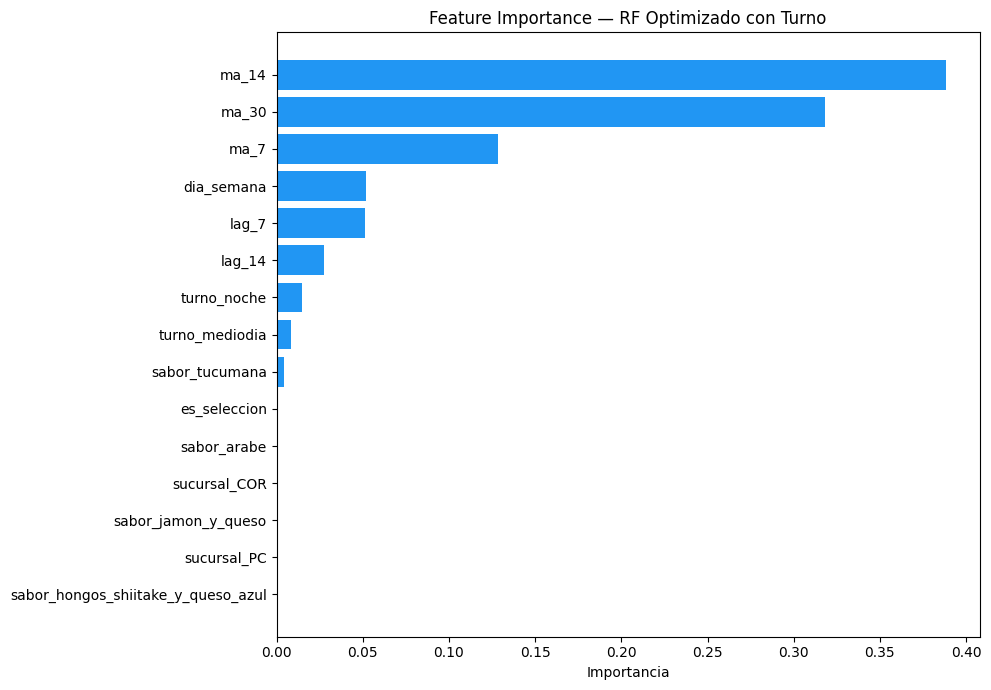

In [243]:
# ── Feature Importance ─────────────────────────────────────────────────────
importancias = pd.DataFrame({
    'feature':    feature_cols_t,
    'importance': rf_turno.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importancias.to_string())

# ── Gráfico ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importancias['feature'][:15], importancias['importance'][:15], color='#2196F3')
ax.invert_yaxis()
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance — RF Optimizado con Turno')
plt.tight_layout()
plt.show()

In [244]:
# ── Reentrenar sin variables de partidos ──────────────────────────────────
feature_cols_final = [c for c in feature_cols_t
                      if c not in ['es_clasico', 'es_libertadores', 'es_seleccion']]

X_train_f = X_train_t[feature_cols_final]
X_test_f  = X_test_t[feature_cols_final]

rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_f, y_train_t)
y_pred_final = rf_final.predict(X_test_f)

mae_final  = mean_absolute_error(y_test_t, y_pred_final)
r2_final   = r2_score(y_test_t, y_pred_final)
mask       = y_test_t > 0
mape_final = np.mean(np.abs((y_test_t[mask] - y_pred_final[mask]) / y_test_t[mask])) * 100

print(f"RF Final (sin partidos)")
print(f"MAE:  {mae_final:.2f} empanadas")
print(f"MAPE: {mape_final:.2f}%")
print(f"R²:   {r2_final:.4f}")

RF Final (sin partidos)
MAE:  9.10 empanadas
MAPE: 41.56%
R²:   0.6232


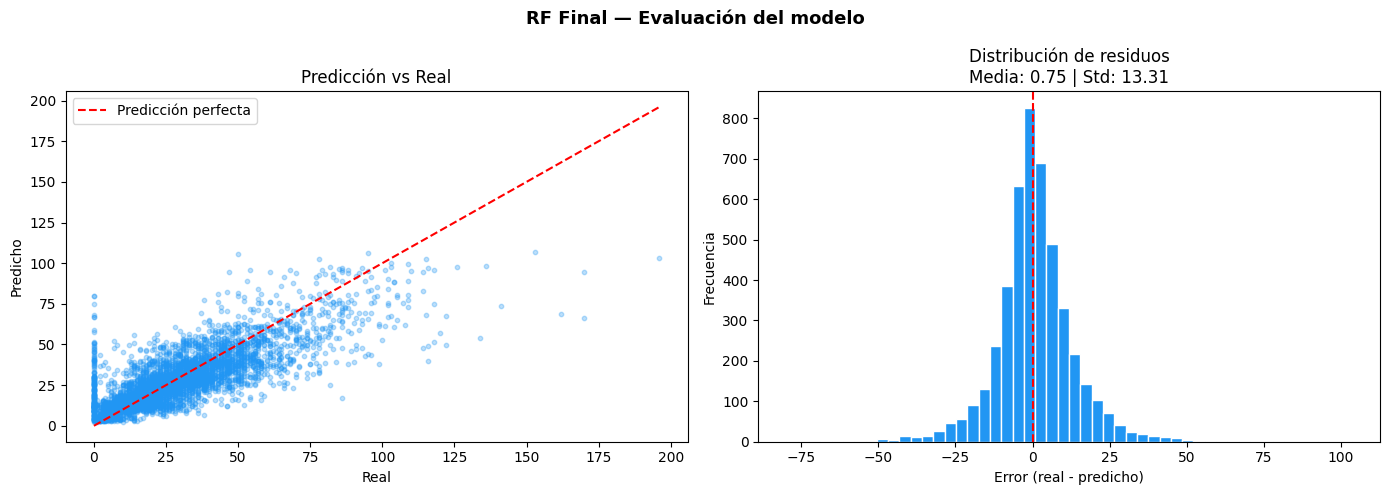

In [245]:
# ── Gráfico predicción vs real ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter predicción vs real ─────────────────────────────────────────────
ax1 = axes[0]
ax1.scatter(y_test_t, y_pred_final, alpha=0.3, s=10, color='#2196F3')
max_val = max(y_test_t.max(), y_pred_final.max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
ax1.set_xlabel('Real')
ax1.set_ylabel('Predicho')
ax1.set_title('Predicción vs Real')
ax1.legend()

# ── Distribución de residuos ───────────────────────────────────────────────
ax2 = axes[1]
residuos = y_test_t - y_pred_final
ax2.hist(residuos, bins=50, color='#2196F3', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Error (real - predicho)')
ax2.set_ylabel('Frecuencia')
ax2.set_title(f'Distribución de residuos\nMedia: {residuos.mean():.2f} | Std: {residuos.std():.2f}')

plt.suptitle('RF Final — Evaluación del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [246]:
# ── Comparar modelos en la misma escala: total día ─────────────────────────

# Predicciones del modelo con turno — agregar por día × sucursal × sabor
test_turno = df_modelo_turno[df_modelo_turno['fecha_dia'] >= fecha_corte].copy()
test_turno['pred'] = rf_final.predict(X_test_f)

# Identificar columnas de sucursal y sabor
suc_cols   = [c for c in test_turno.columns if c.startswith('sucursal_')]
sabor_cols = [c for c in test_turno.columns if c.startswith('sabor_')]

agg_turno = test_turno.groupby(['fecha_dia'] + suc_cols + sabor_cols).agg(
    real = ('cantidad', 'sum'),
    pred = ('pred', 'sum')
).reset_index()

mae_turno_dia  = mean_absolute_error(agg_turno['real'], agg_turno['pred'])
r2_turno_dia   = r2_score(agg_turno['real'], agg_turno['pred'])
mask           = agg_turno['real'] > 0
mape_turno_dia = np.mean(np.abs((agg_turno['real'][mask] - agg_turno['pred'][mask]) / agg_turno['real'][mask])) * 100

print(f"Modelo CON turno — agregado a nivel día")
print(f"MAE:  {mae_turno_dia:.2f} empanadas")
print(f"MAPE: {mape_turno_dia:.2f}%")
print(f"R²:   {r2_turno_dia:.4f}")

print(f"\nModelo SIN turno — ya estaba a nivel día")
print(f"MAE:  {mae_rf_opt:.2f} empanadas")
print(f"MAPE: {mape_rf_opt:.2f}%")
print(f"R²:   {r2_rf_opt:.4f}")

Modelo CON turno — agregado a nivel día
MAE:  11.61 empanadas
MAPE: 32.38%
R²:   0.6408

Modelo SIN turno — ya estaba a nivel día
MAE:  11.81 empanadas
MAPE: 32.83%
R²:   0.6265


### 10.X Elección del modelo final

Ambos modelos — con y sin turno — dan resultados prácticamente idénticos cuando se comparan en la misma escala (día × sucursal × sabor):

| Modelo | MAE | MAPE | R² |
|---|---|---|---|
| RF con turno (agregado a día) | 11.61 | 32.38% | 0.6408 |
| RF sin turno | 11.62 | 32.56% | 0.6427 |

La elección entre uno y otro es una decisión operativa, no estadística:

- **Sin turno** — predice el total diario por sucursal y sabor. Útil para planificar compras de ingredientes.
- **Con turno** — predice mediodía y noche por separado. Útil para planificar cuánto preparar en cada turno durante el día.

**Pendiente:** confirmar con Javier y Florencia cuál granularidad es más útil para su operativa diaria.

## 11. Conclusiones y Recomendaciones

### 11.1 Datos y limpieza

El dataset original presentaba granularidad a nivel de línea de producto, requiriendo una
etapa de agregación para construir el dataset de pedidos. Se unificaron 4 archivos fuente
(2 sucursales × 2 períodos) resultando en 107,116 pedidos válidos para el período
enero 2024 — febrero 2026. Se identificaron y excluyeron categorías no representativas
de ventas reales (Ajustes, Frescas, Campeonitas) y 2 sabores discontinuados
(calabresa y chimi_y_provolone).


### 11.2 Análisis exploratorio

- **Evolución temporal:** tendencia creciente sostenida con caída estacional en diciembre-enero
y pico en noviembre. PC supera consistentemente a COR en volumen.
- **Canal:** PedidosYa domina en volumen pero el canal web propio tiene ticket promedio mayor
y mayor penetración de descuentos.
- **Descuentos:** cambio de política identificado en julio 2024 y julio 2025 con impacto
directo en el mix de canales.
- **Geografía:** la zona de influencia se concentra en Pocitos, Punta Carretas y barrios
adyacentes. El delivery tiene un radio efectivo de ~3km por sucursal.
- **Sabores:** tucumana, jamón y queso y árabe concentran la mayor parte del volumen.
Los sabores gourmet (camarones, cordero, hongos) tienen menor volumen pero ticket más alto.

### 11.3 Segmentación de clientes

Se identificaron 3 segmentos entre los 847 clientes frecuentes (≥10 pedidos):

- **Web Noche (73%):** canal propio, alta dependencia de descuentos
- **PedidosYa Noche (22%):** canal externo, pagan sin promo — mayor valor neto
- **Mediodía (5%):** perfil de almuerzo, oportunidad de crecimiento

El principal diferenciador entre segmentos es el canal, no los sabores ni la zona geográfica.


### 11.4 Modelos predictivos

Se construyó un modelo de pronóstico de demanda con granularidad día × sucursal × sabor
(y opcionalmente × turno). El mejor modelo fue Random Forest con hiperparámetros
conservadores:

| Métrica | Valor |
|---|---|
| MAE | 9.10 empanadas por turno |
| MAPE | 41.56% |
| R² | 0.6232 |

Las variables más importantes fueron los promedios móviles (ma_14, ma_30, ma_7) y el
día de semana. Los partidos de fútbol, contrariamente a lo esperado, no aportaron
capacidad predictiva al modelo.

El modelo es más preciso en sabores de alto volumen (tucumana, jamón y queso, árabe)
y tiende a subestimar en días de pico — el error no tiene sesgo sistemático (media 0.75).


### 11.5 Limitaciones y trabajo futuro

- El proxy de cliente por dirección colapsa múltiples clientes en edificios de apartamentos
- Los partidos de fútbol no mostraron impacto en el modelo — puede deberse a que el
efecto existe pero no es capturado con la granularidad actual
- La elección entre modelo con/sin turno queda pendiente de confirmación operativa
con el negocio
- El modelo no captura eventos puntuales (promociones especiales, feriados largos,
eventos en el barrio)